# Lección 5.2 · Árboles a partir de distancias: UPGMA y Neighbor-Joining

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-05-filogenetica/5.2_upgma_neighbor_joining.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 5 — Filogenética y evolución molecular** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio | Lecciones 4.1 (MSA y árbol guía) y 5.1 (distancias evolutivas) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Nombrar** las partes de un árbol filogenético (raíz, nodos internos, ramas, hojas, clados) y **distinguir** la
   **topología** de las **longitudes de rama**, y un árbol **con raíz** de uno **sin raíz**.
2. **Leer, escribir y programar un lector** del formato **Newick**, el idioma en que se guardan casi todos los árboles.
3. **Calcular** cuántos árboles distintos existen para $n$ especies, $(2n-5)!!$ sin raíz y $(2n-3)!!$ con raíz, y
   **explicar** por qué no se pueden probar todos.
4. **Comprobar** si una matriz de distancias es **ultramétrica** (condición de los tres puntos) o **aditiva**
   (condición de los cuatro puntos).
5. **Ejecutar a mano y programar desde cero** los algoritmos **UPGMA** y **Neighbor-Joining**, y **verificarlos**
   contra SciPy y `Bio.Phylo.TreeConstruction`.
6. **Demostrar con una simulación** por qué UPGMA se equivoca cuando las tasas de evolución son desiguales y
   Neighbor-Joining no.
7. **Enraizar** un árbol con un **grupo externo** o por el **punto medio**, y **comparar** árboles con la
   **distancia de Robinson-Foulds**.
8. **Construir e interpretar** los árboles UPGMA y NJ del citocromo *c* de 14 eucariotas.

## 🗺️ Mapa de la clase

1. Anatomía de un árbol filogenético
2. El formato Newick: árboles escritos con paréntesis
3. ¿Cuántos árboles hay? La explosión combinatoria
4. Aditividad y ultrametría: ¿cuándo una matriz "es" un árbol?
5. UPGMA paso a paso (🎬 animación)
6. Por qué UPGMA falla cuando las tasas son desiguales (🧪 simulación)
7. Neighbor-Joining: la matriz $Q$ (🎬 animación)
8. Verificación contra Biopython y SciPy
9. ¿Dónde está la raíz? Grupo externo y punto medio
10. ¿Qué tan distintos son dos árboles? La distancia de Robinson-Foulds
11. 🧪 Aplicación real: el árbol del citocromo *c* (árboles interactivos)
12. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import itertools, math, time, io
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle, FancyBboxPatch
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import SeqIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

Entorno listo ✔  |  Colab: False


## 1. Anatomía de un árbol filogenético

Un **árbol filogenético** es una hipótesis sobre la historia de un grupo de secuencias (o de especies): quién
desciende de quién y cuánto cambio se acumuló en el camino. Se parece mucho a un árbol genealógico familiar, con
una diferencia importante: en el árbol genealógico los antepasados tienen nombre (la abuela, el bisabuelo), y en un
árbol filogenético casi nunca los conocemos. Sólo observamos las **puntas**; todo lo demás es inferencia.

| Parte | Qué representa | En el árbol de la figura |
|---|---|---|
| **Hoja** (punta, taxón terminal) | una secuencia o especie **observada hoy** | Humano, Chimpancé, … |
| **Nodo interno** | un **ancestro común** hipotético, del que se separaron dos (o más) linajes | el punto donde se unen Humano y Chimpancé |
| **Rama** (arista) | un linaje que persiste en el tiempo y acumula cambios | cada segmento horizontal |
| **Longitud de rama** | cuánto cambio (sustituciones por sitio) o cuánto tiempo transcurrió en esa rama | largo del segmento horizontal |
| **Raíz** | el **ancestro común más antiguo** de todas las hojas; da la dirección del tiempo | el extremo izquierdo |
| **Clado** (grupo monofilético) | un ancestro **y todos** sus descendientes | {Humano, Chimpancé, Gorila} |
| **Topología** | sólo el **patrón de ramificación**: quién se agrupa con quién, sin mirar longitudes | ((((H,C),G),O),M) |

Dos ideas que confunden a casi todos al principio:

* **Rotar un nodo no cambia el árbol.** Las dos ramas que salen de un nodo son como las dos piezas de un móvil que
  cuelga del techo: girarlas no cambia qué está unido a qué. Que Humano aparezca arriba o abajo de Chimpancé no dice
  nada. Tampoco importa el orden vertical de las hojas: lo único que se lee es **dónde se unen** los linajes.
* **Sólo el eje horizontal tiene significado.** En un **filograma** el largo de cada rama es proporcional al cambio
  evolutivo; en un **cladograma** todas las ramas se dibujan del mismo largo porque sólo interesa la topología. El
  largo de las líneas verticales es puro dibujo.

**Con raíz o sin raíz.** Un árbol **con raíz** tiene dirección: sabemos qué nodo es el más antiguo y, por lo tanto,
qué es ancestro de qué. Un árbol **sin raíz** sólo dice cómo se **conectan** las hojas, como un mapa de carreteras sin
indicar dónde empezó el viaje. Como veremos, la mayoría de los métodos (incluido Neighbor-Joining) producen árboles
**sin raíz**; ponerles raíz exige información adicional (sección 9).

Para trabajar con árboles en Python necesitamos una estructura de datos. La más natural es **recursiva**: un nodo
tiene un nombre (si es hoja), una lista de hijos y la longitud de la rama que lo une con su padre. Un árbol entero
es simplemente su nodo raíz.

In [2]:
class Node:
    """Nodo de un árbol: nombre (hojas), hijos y longitud de la rama que lo une a su padre."""
    def __init__(self, name=None, children=None, length=0.0):
        self.name, self.children, self.length = name, list(children or []), length

    def is_leaf(self):
        return not self.children

    def leaves(self):
        """Nombres de las hojas que descienden de este nodo (el clado que define)."""
        return [self.name] if self.is_leaf() else [x for c in self.children for x in c.leaves()]

    def nodes(self):
        """Recorre todos los nodos del subárbol (primero el padre, luego los hijos)."""
        yield self
        for c in self.children:
            yield from c.nodes()

    def __repr__(self):
        return to_newick(self)

# El árbol de los grandes simios y el macaco, construido "a mano" (longitudes ≈ millones de años)
human, chimp = Node("Humano", length=6.5), Node("Chimpancé", length=6.5)
hc = Node(children=[human, chimp], length=2.5)
hcg = Node(children=[hc, Node("Gorila", length=9.0)], length=6.5)
hcgo = Node(children=[hcg, Node("Orangután", length=15.5)], length=13.5)
apes = Node(children=[hcgo, Node("Macaco", length=29.0)], length=0.0)
print("Hojas:", apes.leaves())
print("Número de nodos:", sum(1 for _ in apes.nodes()), "· internos:", sum(1 for x in apes.nodes() if not x.is_leaf()))

Hojas: ['Humano', 'Chimpancé', 'Gorila', 'Orangután', 'Macaco']
Número de nodos: 9 · internos: 4


Ahora una función para **dibujar** árboles con raíz como **filograma rectangular**, el formato estándar de las
revistas. El truco es asignar coordenadas: la $x$ de un nodo es su **distancia a la raíz** (suma de las longitudes de
rama del camino), y la $y$ de una hoja es simplemente su posición en la lista de hojas; un nodo interno se coloca a
la mitad vertical de sus hijos. La usaremos en toda la clase.

In [3]:
def rooted_layout(tree):
    """Coordenadas de un filograma: x = distancia a la raíz, y = orden de las hojas (0, 1, 2, …)."""
    pos, counter = {}, [0]
    def walk(nd, x_parent):
        x = x_parent + (nd.length or 0.0)
        if nd.is_leaf():
            y = counter[0]; counter[0] += 1
        else:
            ys = [walk(c, x) for c in nd.children]
            y = (min(ys) + max(ys)) / 2
        pos[id(nd)] = (x, y)
        return y
    walk(tree, -(tree.length or 0.0))          # la raíz queda en x = 0
    return pos

def draw_tree(ax, tree, label_colors=None, fs=10.5, lw=2.0, color=None, show_lengths=False,
              edge_colors=None, scale=None, xlabel="sustituciones por sitio", leaf_dot=True, show_labels=True):
    """Dibuja un árbol con raíz como filograma rectangular. Devuelve el diccionario de posiciones."""
    pos = rooted_layout(tree)
    color = color or ec.INK_2
    xmax = max(x for x, _ in pos.values())
    for nd in tree.nodes():
        x, y = pos[id(nd)]
        for c in nd.children:
            cx, cy = pos[id(c)]
            col = (edge_colors or {}).get(id(c), color)
            ax.plot([x, x], [y, cy], color=col, lw=lw, solid_capstyle="round")      # tramo vertical
            ax.plot([x, cx], [cy, cy], color=col, lw=lw, solid_capstyle="round")    # rama (horizontal)
            if show_lengths and c.length:
                ax.text((x + cx) / 2, cy - 0.12, f"{c.length:g}", ha="center", va="bottom",
                        fontsize=fs - 2, color=ec.INK_2)
        if nd.is_leaf():
            lc = (label_colors or {}).get(nd.name, ec.INK)
            if show_labels:
                ax.text(x + xmax * 0.02, y, nd.name, ha="left", va="center", fontsize=fs, color=lc,
                        fontweight="bold" if label_colors else "normal")
            if leaf_dot:
                ax.plot(x, y, "o", color=lc if label_colors else ec.INK_2, ms=4.5, zorder=3)
    n = len(tree.leaves())
    ax.set_ylim(n - 0.4, -0.6)
    ax.set_yticks([]); ax.spines["left"].set_visible(False); ax.grid(False)
    ax.set_xlim(-xmax * 0.03, xmax * 1.32)
    if scale:                                     # barra de escala en lugar de eje
        ax.spines["bottom"].set_visible(False); ax.set_xticks([])
        ax.set_ylim(n + 0.55, -0.6)
        ax.plot([0, scale], [n - 0.1, n - 0.1], color=ec.INK, lw=1.5, solid_capstyle="butt")
        ax.text(0, n + 0.05, f"{scale:g} {xlabel}", ha="left", va="top", fontsize=9, color=ec.INK_2)
    else:
        ax.set_xlabel(xlabel)
    return pos

Y otra para árboles **sin raíz**, con el algoritmo de **ángulos iguales** (*equal-angle*, descrito por Felsenstein,
2004): cada subárbol recibe un abanico de ángulo proporcional a su número de hojas, y cada rama se dibuja en la
dirección central de su abanico, con su longitud real.

In [4]:
def unrooted_layout(tree):
    """Ángulos iguales: cada subárbol ocupa un sector proporcional a su número de hojas."""
    pos = {id(tree): (0.0, 0.0)}
    n = len(tree.leaves())
    def walk(nd, a0):
        x0, y0 = pos[id(nd)]
        a = a0
        for c in nd.children:
            w = 2 * math.pi * len(c.leaves()) / n
            mid = a + w / 2
            pos[id(c)] = (x0 + c.length * math.cos(mid), y0 + c.length * math.sin(mid))
            walk(c, a); a += w
    walk(tree, 0.0)
    return pos

def draw_unrooted(ax, tree, label_colors=None, fs=10.5, lw=2.0, color=None, pos=None, pad=0.05):
    pos = pos or unrooted_layout(tree)
    color = color or ec.INK_2
    span = max(max(abs(x), abs(y)) for x, y in pos.values())
    for nd in tree.nodes():
        x, y = pos[id(nd)]
        for c in nd.children:
            cx, cy = pos[id(c)]
            ax.plot([x, cx], [y, cy], color=color, lw=lw, solid_capstyle="round")
        if nd.is_leaf():
            ang = math.atan2(y - pos[id(tree)][1], x - pos[id(tree)][0])
            lc = (label_colors or {}).get(nd.name, ec.INK)
            ax.plot(x, y, "o", color=lc if label_colors else ec.INK_2, ms=5, zorder=3)
            ax.text(x + pad * span * math.cos(ang), y + pad * span * math.sin(ang), nd.name, fontsize=fs,
                    color=lc, ha="left" if math.cos(ang) >= 0 else "right", va="center",
                    fontweight="bold" if label_colors else "normal")
        elif nd is not tree:
            ax.plot(x, y, "o", color=ec.MUTED, ms=3.5, zorder=3)
    fit_limits(ax, pos)
    return pos

def fit_limits(ax, pos, mx=0.32, my=0.10):
    """Límites con margen para las etiquetas (más margen horizontal que vertical)."""
    xs, ys = [p[0] for p in pos.values()], [p[1] for p in pos.values()]
    w, h = max(xs) - min(xs), max(ys) - min(ys)
    ax.set_xlim(min(xs) - mx * w, max(xs) + mx * w); ax.set_ylim(min(ys) - my * h, max(ys) + my * h)
    ax.set_aspect("equal", adjustable="box"); ax.axis("off")

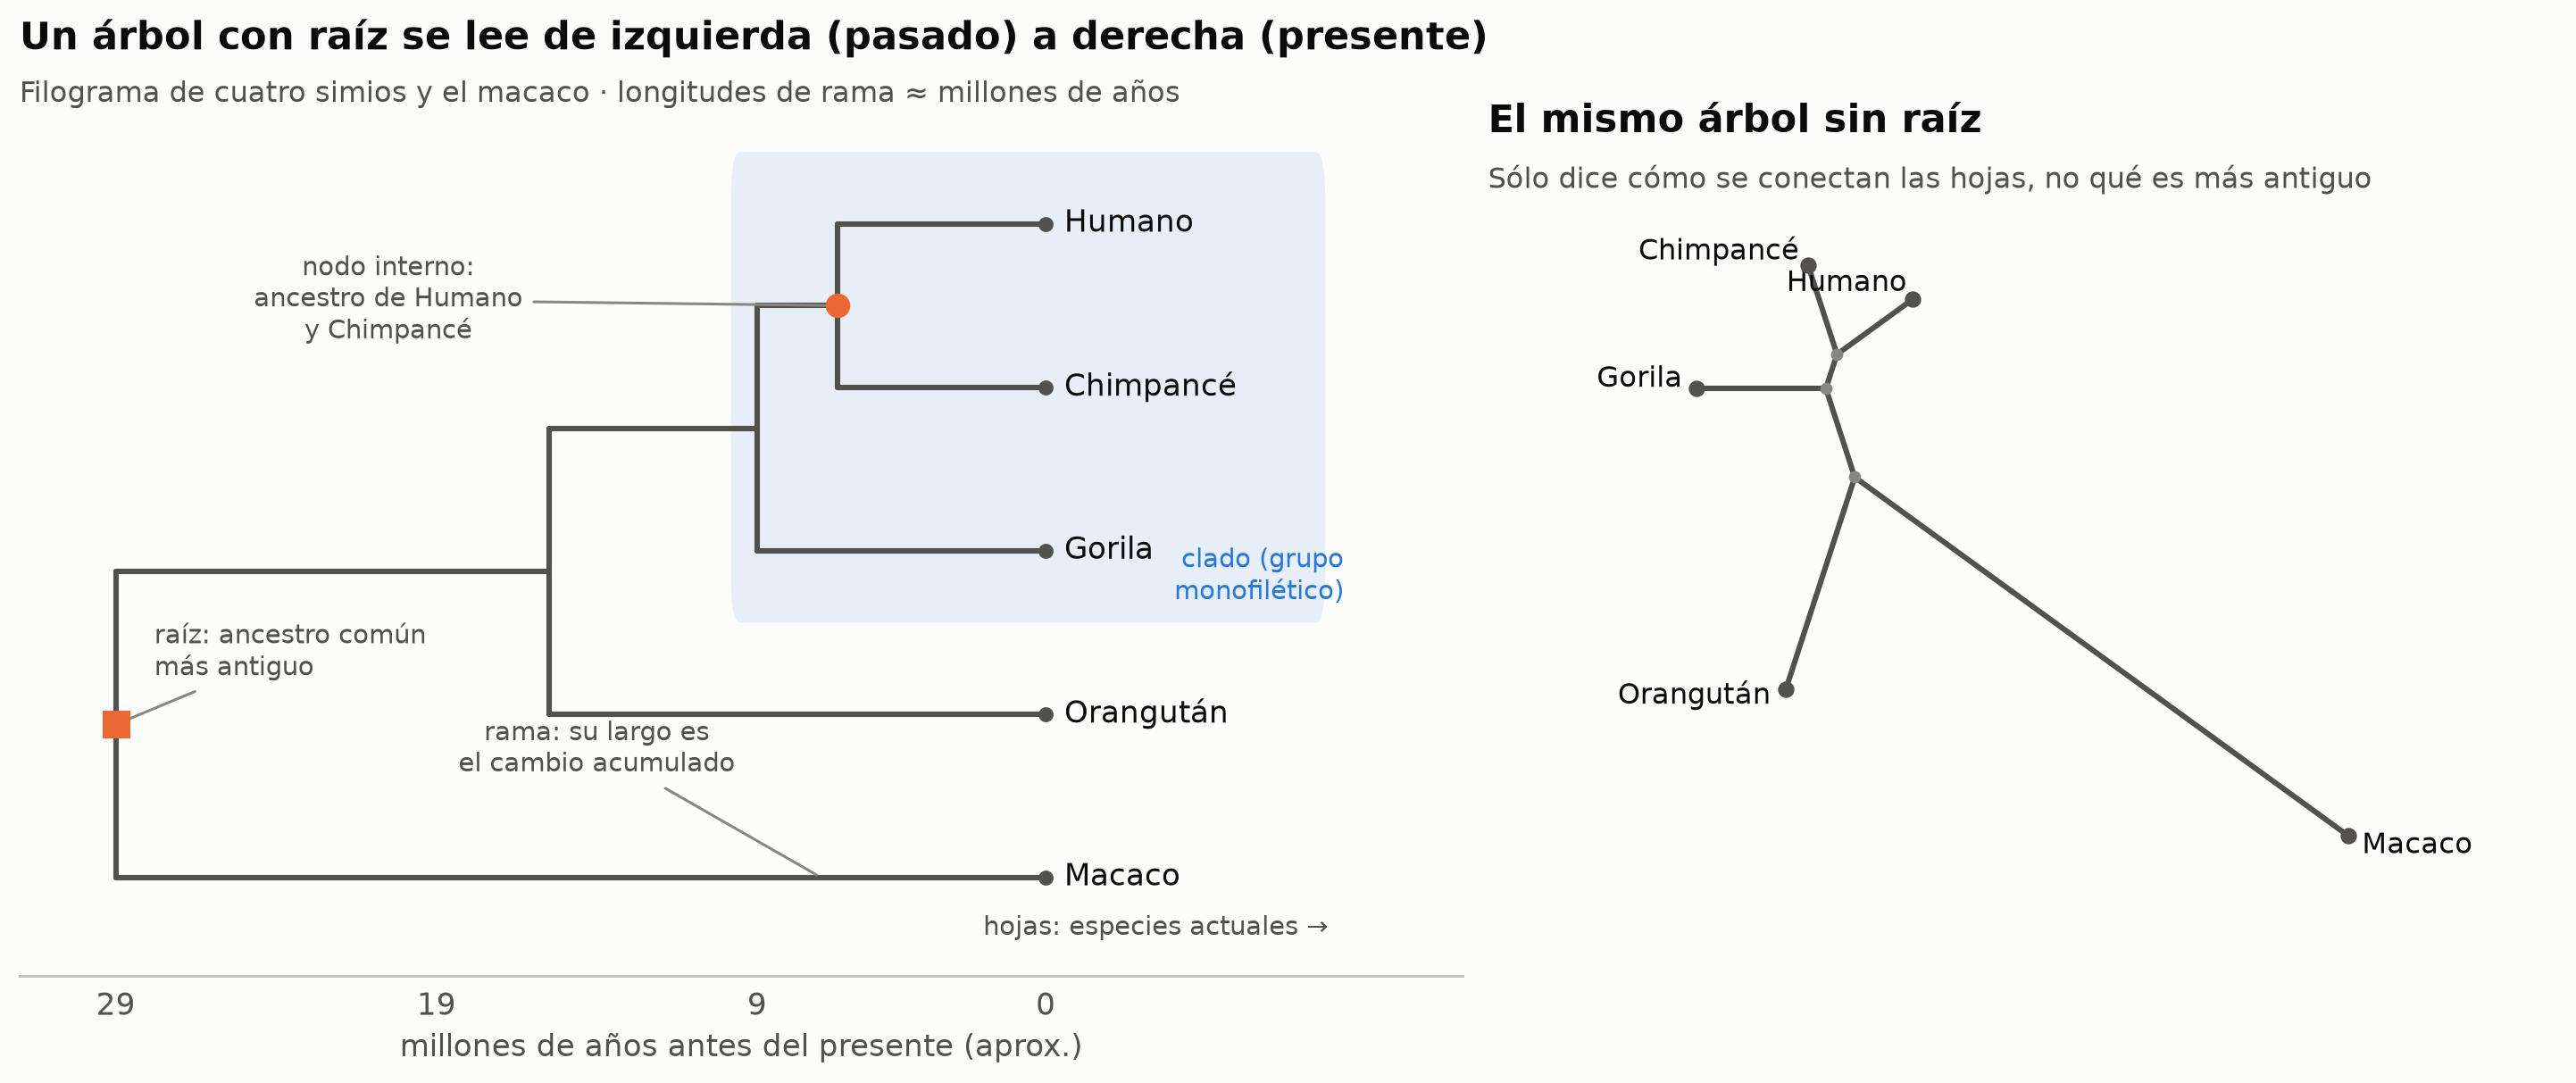

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4), width_ratios=[1.35, 1])
pos = draw_tree(ax1, apes, fs=11, xlabel="millones de años antes del presente (aprox.)")
ax1.set_xlim(-3, 42)
ax1.set_xticks([0, 10, 20, 29]); ax1.set_xticklabels(["29", "19", "9", "0"])
# Clado sombreado: {Humano, Chimpancé, Gorila}
x_hcg, y_hcg = pos[id(hcg)]
ax1.add_patch(FancyBboxPatch((x_hcg - 0.8, -0.42), 29 - x_hcg + 9.5, 2.84, boxstyle="round,pad=0.02,rounding_size=0.3",
                             fc=ec.BLUE, alpha=0.10, lw=0))
ax1.text(29 + 9.3, 2.35, "clado (grupo\nmonofilético)", ha="right", va="bottom", fontsize=9.5, color=ec.BLUE)
ax1.plot(0, pos[id(apes)][1], "s", color=ec.ORANGE, ms=9, zorder=4)
ax1.annotate("raíz: ancestro común\nmás antiguo", pos[id(apes)], xytext=(1.2, 2.62), fontsize=9.5, color=ec.INK_2, va="center",
             arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
x_hc, y_hc = pos[id(hc)]
ax1.plot(x_hc, y_hc, "o", color=ec.ORANGE, ms=8, zorder=4)
ax1.annotate("nodo interno:\nancestro de Humano\ny Chimpancé", (x_hc, y_hc), xytext=(8.5, 0.7), fontsize=9.5,
             color=ec.INK_2, ha="center", arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ax1.annotate("rama: su largo es\nel cambio acumulado", (22, pos[id(apes.children[1])][1]), xytext=(15, 3.35),
             fontsize=9.5, color=ec.INK_2, ha="center", arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1))
ax1.text(37.8, 4.35, "hojas: especies actuales →", ha="right", fontsize=9.5, color=ec.INK_2)
ec.title(ax1, "Un árbol con raíz se lee de izquierda (pasado) a derecha (presente)",
         "Filograma de cuatro simios y el macaco · longitudes de rama ≈ millones de años")

draw_unrooted(ax2, apes, fs=10.5)
ec.title(ax2, "El mismo árbol sin raíz", "Sólo dice cómo se conectan las hojas, no qué es más antiguo")
plt.show()

> 🔎 **Qué observamos.** En el árbol con raíz (izquierda) el tiempo corre de izquierda a derecha y todas las hojas
> terminan a la misma altura porque las longitudes son **tiempos**: cada especie actual ha vivido exactamente lo
> mismo desde la raíz. A la derecha está **el mismo** árbol sin raíz: las cinco hojas conectadas por las mismas ramas,
> pero ya no sabemos si el ancestro común está cerca del macaco o del humano. Observe que el árbol sin raíz tiene
> **un nodo interno menos**: la raíz, que tenía grado 2, desaparece y sus dos ramas se funden en una.

## 2. El formato Newick: árboles escritos con paréntesis

¿Cómo se guarda un árbol en un archivo de texto? En 1986, en una reunión informal en un restaurante de langostas de
Durham (New Hampshire) llamado *Newick's*, un grupo de autores de programas de filogenia (entre ellos Joe Felsenstein)
acordó una notación que hoy usan prácticamente todos los programas: **Newick**. Las reglas caben en una tabla:

| Símbolo | Significado | Ejemplo |
|---|---|---|
| `(A,B)` | A y B son hermanos: descienden de un mismo nodo | `(Humano,Chimpancé)` |
| `,` | separa a los hijos de un mismo nodo | `(A,B,C)` = politomía de tres hijos |
| `:x` | longitud de la rama que une ese nodo con su padre | `Humano:6.5` |
| `)nombre` | nombre (o valor de soporte) de un nodo interno | `(A,B)Homininae` |
| `;` | fin del árbol | obligatorio al final |

La idea es **anidar**: cada par de paréntesis es un clado. El árbol de la figura anterior se escribe así:

```
((((Humano:6.5,Chimpancé:6.5):2.5,Gorila:9):6.5,Orangután:15.5):13.5,Macaco:29);
```

**Léalo de adentro hacia afuera:** `(Humano:6.5,Chimpancé:6.5)` es el clado humano–chimpancé; ese clado cuelga de su
padre por una rama de 2.5; junto con `Gorila:9` forma un clado mayor; y así hasta la raíz. Compruebe que la distancia
de la raíz a Humano es $13.5 + 6.5 + 2.5 + 6.5 = 29$ y la de la raíz a Macaco es $29$: el árbol es un reloj perfecto.

Un árbol **sin raíz** se escribe igual, pero con **tres** hijos en el nivel más externo (la "raíz" es entonces un
nodo interno cualquiera, elegido sólo para poder escribir el texto): `(A:1,B:2,(C:1,D:1):0.5);`.

### Un lector de Newick en 30 líneas

Escribir un árbol es fácil (recorrer los nodos recursivamente). **Leerlo** es un pequeño ejercicio de análisis
sintáctico **recursivo descendente**: una función `read_node` que, si ve `(`, lee hijos separados por comas hasta
encontrar `)`; luego lee un nombre opcional y, si hay `:`, una longitud. Como cada hijo es a su vez un nodo, la función
se llama a sí misma.

In [6]:
def to_newick(node, digits=4, top=True):
    """Árbol → texto Newick (recursivo)."""
    if node.is_leaf():
        s = node.name
    else:
        s = "(" + ",".join(to_newick(c, digits, False) for c in node.children) + ")" + (node.name or "")
    if not top and node.length is not None:
        s += f":{round(node.length, digits):g}"
    return s + (";" if top else "")

def parse_newick(text):
    """Texto Newick → árbol de objetos Node (analizador recursivo descendente)."""
    text = text.strip().rstrip(";")
    pos = 0
    def read_label():
        nonlocal pos
        start = pos
        while pos < len(text) and text[pos] not in ",():;":
            pos += 1
        return text[start:pos].strip().strip("'")     # los nombres con espacios suelen ir entre comillas
    def read_node():
        nonlocal pos
        node = Node()
        if text[pos] == "(":                 # un clado: leer sus hijos separados por comas
            pos += 1
            node.children.append(read_node())
            while text[pos] == ",":
                pos += 1
                node.children.append(read_node())
            if text[pos] != ")":
                raise ValueError(f"se esperaba ')' en la posición {pos}")
            pos += 1
        node.name = read_label() or None     # nombre (hoja) o etiqueta del nodo interno
        if pos < len(text) and text[pos] == ":":
            pos += 1
            node.length = float(read_label())
        return node
    root = read_node()
    if pos != len(text):
        raise ValueError(f"texto sobrante después de la posición {pos}: ¿paréntesis desbalanceados?")
    root.length = 0.0
    return root

nwk = "((((Humano:6.5,Chimpancé:6.5):2.5,Gorila:9):6.5,Orangután:15.5):13.5,Macaco:29);"
t = parse_newick(nwk)
print("Leído     :", t.leaves())
print("Reescrito :", to_newick(t))
print("¿Ida y vuelta idénticas?", to_newick(t) == nwk)
print("Coincide con el árbol construido a mano:", to_newick(apes) == nwk)

Leído     : ['Humano', 'Chimpancé', 'Gorila', 'Orangután', 'Macaco']
Reescrito : ((((Humano:6.5,Chimpancé:6.5):2.5,Gorila:9):6.5,Orangután:15.5):13.5,Macaco:29);
¿Ida y vuelta idénticas? True
Coincide con el árbol construido a mano: True


Biopython trae su propio lector (`Bio.Phylo`), que acepta muchos formatos (Newick, NEXUS, phyloXML…). Usémoslo para
comprobar el nuestro: debe ver las mismas hojas y las mismas longitudes totales.

In [7]:
bio_tree = Phylo.read(io.StringIO(nwk), "newick")
Phylo.draw_ascii(bio_tree)
print("Longitud total del árbol · Biopython:", bio_tree.total_branch_length(),
      "· nuestro lector:", sum(nd.length for nd in t.nodes()))

                                                     _______________ Humano
                                                ____|
                                 ______________|    |_______________ Chimpancé
                                |              |
  ______________________________|              |____________________ Gorila
 |                              |
_|                              |___________________________________ Orangután
 |
 |__________________________________________________________________ Macaco

Longitud total del árbol · Biopython: 89.0 · nuestro lector: 89.0


> 🔎 **Qué observamos.** Nuestro lector reconstruye exactamente el texto original y coincide con Biopython en la
> longitud total (la suma de todas las ramas: 89 millones de años de linajes). Un error clásico al escribir Newick a
> mano es olvidar un paréntesis: nuestro lector lo detecta y avisa en lugar de devolver un árbol incompleto.

### Topología frente a longitudes

🤔 **Antes de ejecutar, prediga:** de los cuatro árboles de la figura siguiente, **tres** tienen la misma topología
(sólo cambian el orden de dibujo o las longitudes). ¿Cuál es el diferente?

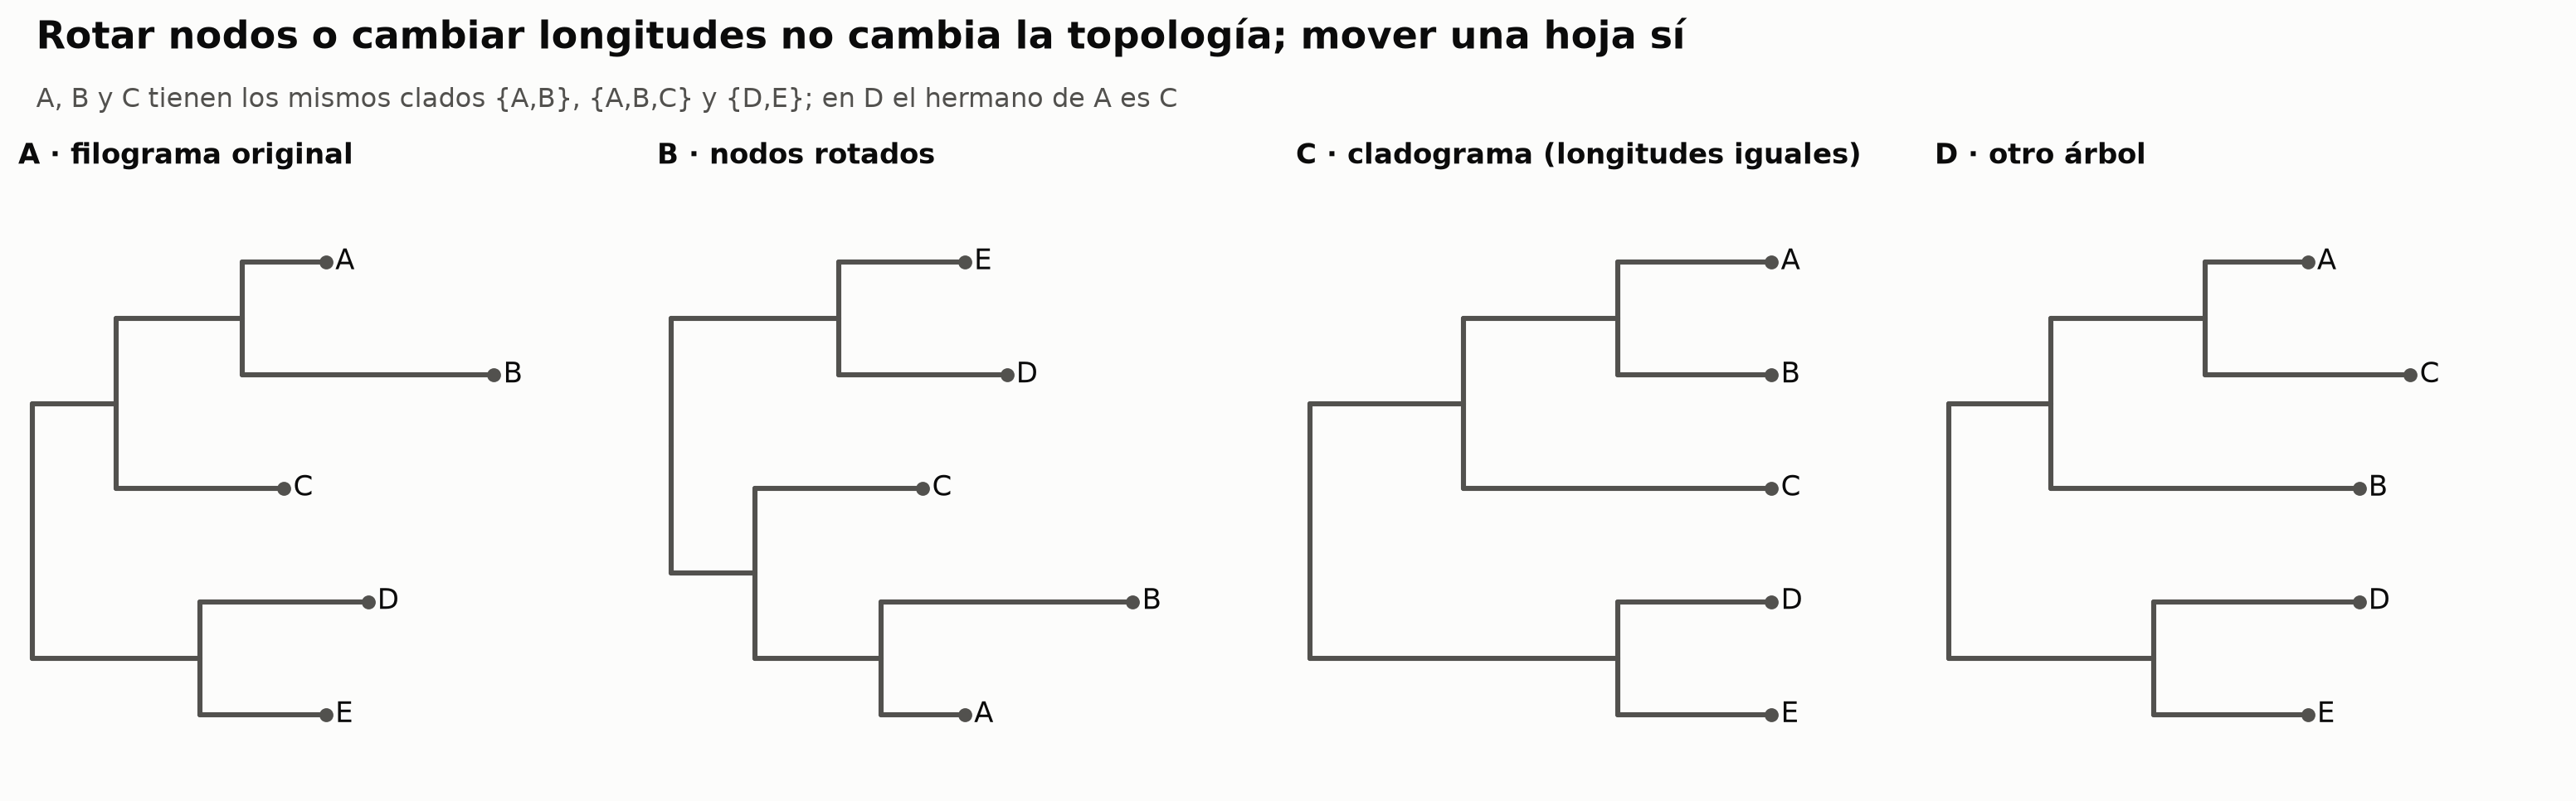

In [8]:
variants = {
    "A · filograma original": "(((A:1,B:3):1.5,C:2):1,(D:2,E:1.5):2);",
    "B · nodos rotados": "((E:1.5,D:2):2,(C:2,(B:3,A:1):1.5):1);",
    "C · cladograma (longitudes iguales)": "(((A:1,B:1):1,C:2):1,(D:1,E:1):2);",
    "D · otro árbol": "(((A:1,C:2):1.5,B:3):1,(D:2,E:1.5):2);",
}
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=False)
for ax, (label, text) in zip(axes, variants.items()):
    draw_tree(ax, parse_newick(text), fs=11, xlabel="")
    ax.set_xticks([]); ax.spines["bottom"].set_visible(False)
    ax.set_title(label, loc="left", fontsize=11)
ec.fig_title(fig, "Rotar nodos o cambiar longitudes no cambia la topología; mover una hoja sí",
             "A, B y C tienen los mismos clados {A,B}, {A,B,C} y {D,E}; en D el hermano de A es C")
plt.show()

> 🔎 **Qué observamos.** A, B y C son **el mismo árbol** en cuanto a topología: siempre están los clados $\{A,B\}$,
> $\{A,B,C\}$ y $\{D,E\}$. B es A "girado" en dos nodos y C ignora las longitudes. El árbol D es distinto: el clado
> $\{A,B\}$ desapareció y aparece $\{A,C\}$. Por eso, para comparar árboles, lo correcto es comparar **conjuntos de
> clados** (o de biparticiones), no dibujos. Lo haremos formalmente con la distancia de Robinson-Foulds (sección 10).

✅ **Compruebe su comprensión.** Escriba en Newick el árbol D con los nodos rotados de modo que E sea la primera hoja.
¿Cambia la topología?

## 3. ¿Cuántos árboles hay? La explosión combinatoria

Si pudiéramos dibujar **todos** los árboles posibles y quedarnos con el que mejor explica los datos, la filogenia
sería fácil. ¿Cuántos son?

**Contémoslos a mano, sin raíz.** Con 3 especies hay **un único** árbol sin raíz: una estrella con tres ramas. Para
añadir la cuarta especie, la podemos "injertar" en cualquiera de las **3 ramas** → 3 árboles. Cada árbol de 4 hojas
tiene **5 ramas**, así que la quinta especie tiene 5 lugares posibles → $3 \times 5 = 15$ árboles. Un árbol sin raíz de
$k$ hojas tiene $2k-3$ ramas, de modo que la hoja $k+1$ tiene $2k-3$ lugares. Multiplicando:

$$
U(n) \;=\; 1 \times 3 \times 5 \times \cdots \times (2n-5) \;=\; (2n-5)!! \;=\; \frac{(2n-5)!}{2^{\,n-3}\,(n-3)!},
\qquad
R(n) \;=\; (2n-3)!! \;=\; U(n+1)
$$

| Símbolo | Significado |
|---|---|
| $n$ | número de hojas (especies o secuencias), $n \ge 3$ |
| $U(n)$ | número de árboles **sin raíz** binarios distintos (topologías) |
| $R(n)$ | número de árboles **con raíz** binarios distintos |
| $k!!$ | doble factorial: producto de los impares $1 \cdot 3 \cdot 5 \cdots k$ |
| $2n-3$ | ramas de un árbol sin raíz de $n$ hojas: los lugares donde podría ir la raíz |

La relación $R(n) = U(n) \times (2n-3)$ tiene una lectura bonita: **cada árbol con raíz es un árbol sin raíz en el que
elegimos una de sus $2n-3$ ramas para poner la raíz**. Y $R(n) = U(n+1)$: enraizar equivale a añadir una hoja
imaginaria (el "grupo externo") en esa rama.

| $n$ | sin raíz $(2n-5)!!$ | con raíz $(2n-3)!!$ |
|---|---|---|
| 3 | 1 | 3 |
| 4 | 3 | 15 |
| 5 | 15 | 105 |
| 10 | 2 027 025 | 34 459 425 |

Comprobemos la fórmula **construyendo** todos los árboles por adición paso a paso, tal como la contamos a mano.

In [9]:
def double_factorial(k):
    return math.prod(range(k, 0, -2)) if k > 0 else 1

def enumerate_unrooted(n):
    """Todas las topologías sin raíz de n hojas (0..n-1), como listas de aristas, por adición paso a paso."""
    trees = [[(0, n), (1, n), (2, n)]]               # la estrella de 3 hojas; los nodos internos se numeran desde n
    for leaf in range(3, n):
        new_trees = []
        for edges in trees:
            w = n + leaf - 2                          # nuevo nodo interno
            for e in edges:                           # injertar la hoja en cada rama existente
                rest = [x for x in edges if x != e]
                new_trees.append(rest + [(e[0], w), (w, e[1]), (leaf, w)])
        trees = new_trees
    return trees

t0 = time.perf_counter()
rows = []
for n in range(3, 10):
    count = len(enumerate_unrooted(n))
    rows.append((n, count, double_factorial(2 * n - 5), double_factorial(2 * n - 3)))
print(f"Enumeración hasta n = 9 en {time.perf_counter() - t0:.2f} s")
pd.DataFrame(rows, columns=["n", "enumerados (sin raíz)", "(2n−5)!!", "(2n−3)!! con raíz"])

Enumeración hasta n = 9 en 0.18 s


,n,enumerados (sin raíz),(2n−5)!!,(2n−3)!! con raíz
0,3,1,1,3
1,4,3,3,15
2,5,15,15,105
3,6,105,105,945
4,7,945,945,10395
5,8,10395,10395,135135
6,9,135135,135135,2027025


La enumeración confirma la fórmula, pero ya con $n = 9$ la lista tiene 135 135 árboles. ¿Y con más especies?

🤔 **Antes de ejecutar, prediga:** ¿con cuántas especies el número de árboles sin raíz supera el número estimado de
átomos del universo observable ($\sim 10^{80}$)? ¿Con 100? ¿Con 1 000?

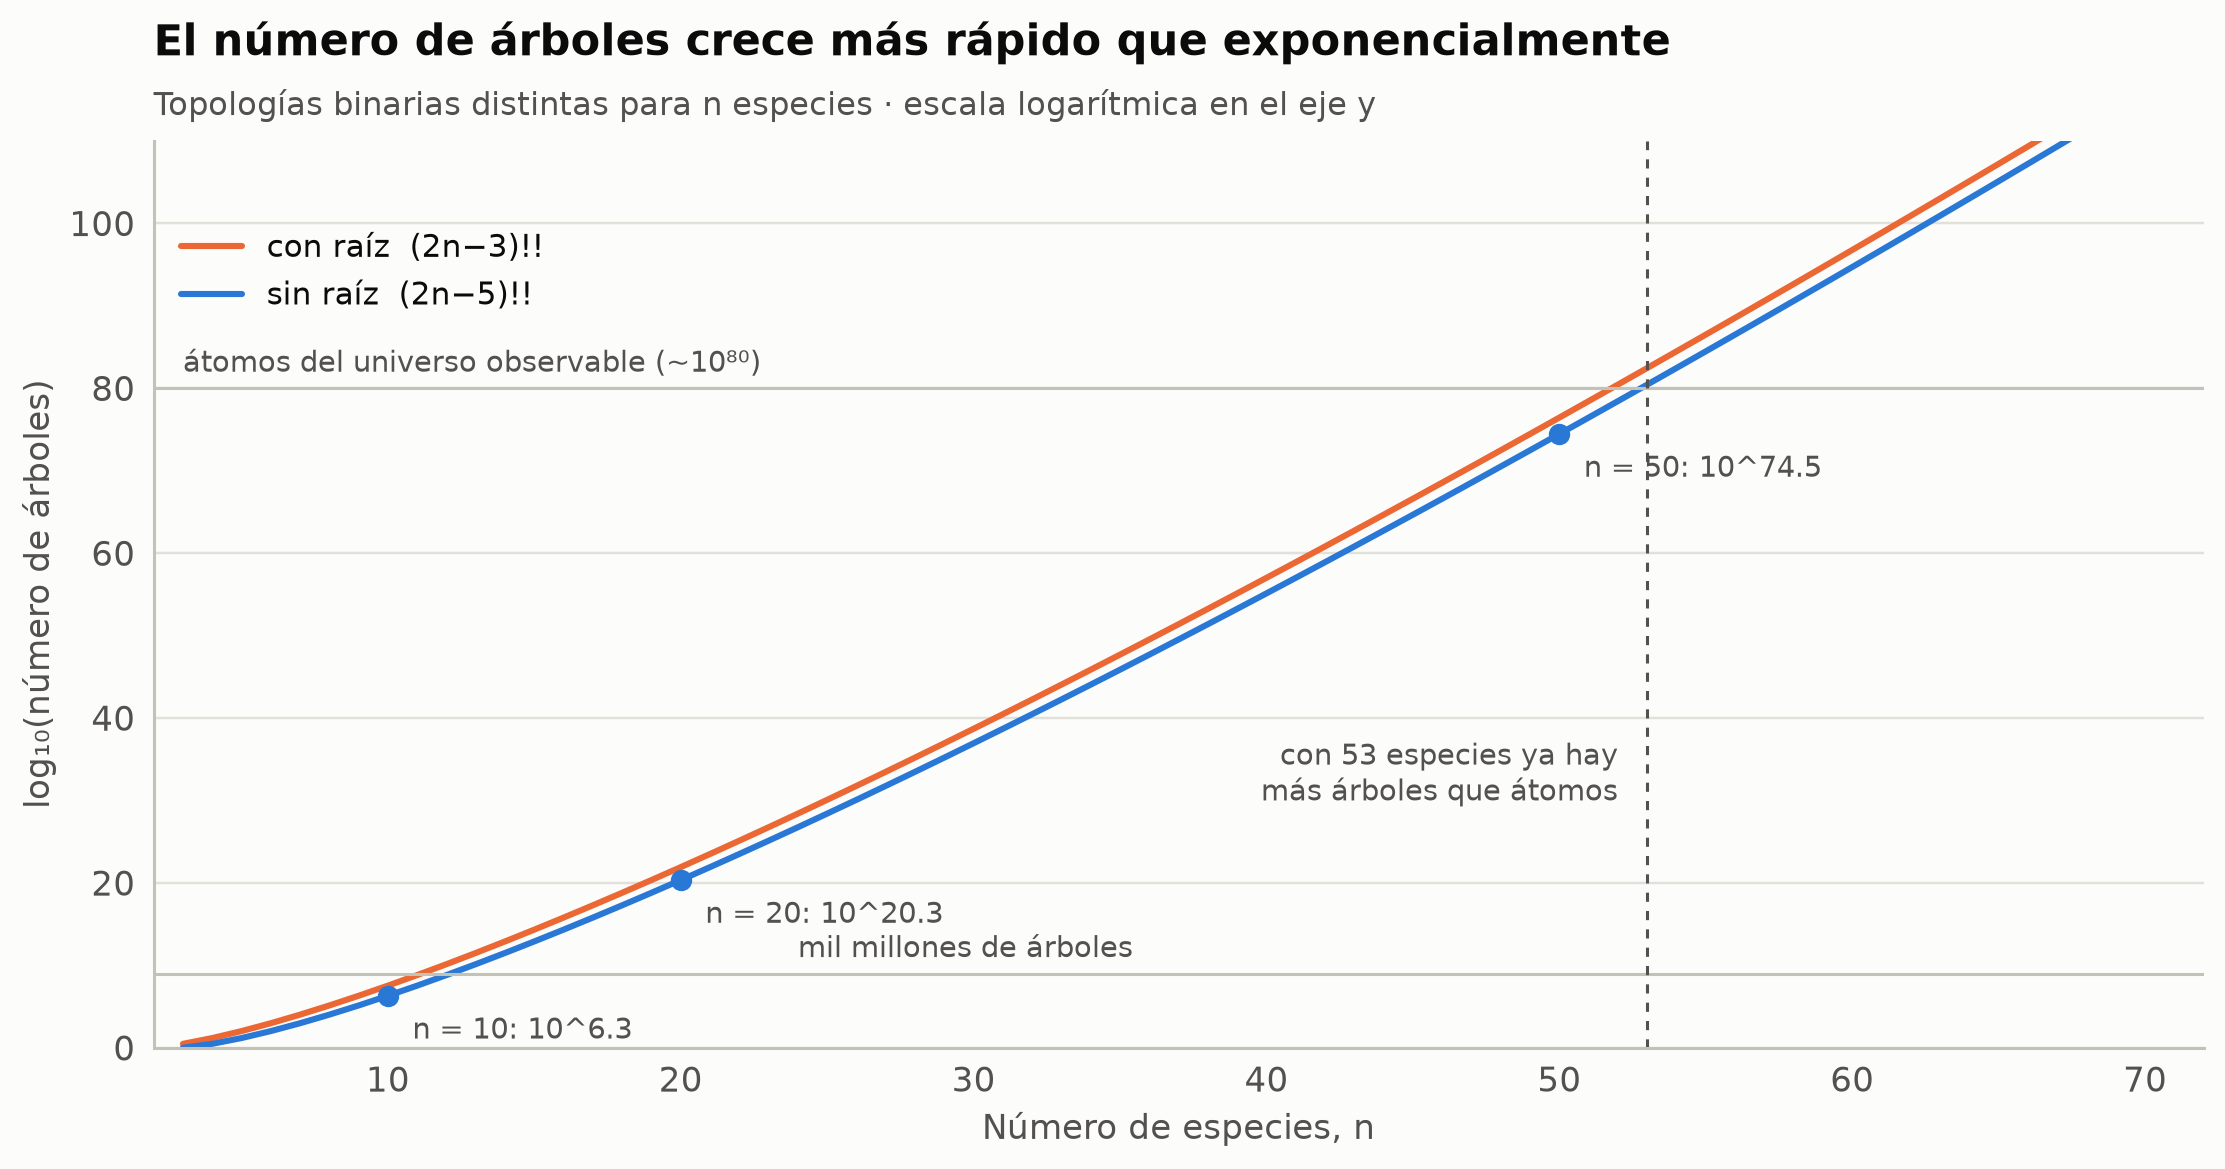

In [10]:
ns = np.arange(3, 71)
log10_U = np.array([(math.lgamma(2 * n - 4) - (n - 3) * math.log(2) - math.lgamma(n - 2)) / math.log(10) for n in ns])
log10_R = log10_U + np.log10(2 * ns - 3)
n_atoms = ns[np.argmax(log10_U > 80)]

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(ns, log10_R, color=ec.ORANGE, label="con raíz  (2n−3)!!")
ax.plot(ns, log10_U, color=ec.BLUE, label="sin raíz  (2n−5)!!")
for y, lab in [(9, "mil millones de árboles"), (80, "átomos del universo observable (~10⁸⁰)")]:
    ax.axhline(y, color=ec.BASELINE, lw=1)
    ax.text(3 if y > 50 else 24, y + 2, lab, color=ec.INK_2, fontsize=9.5)
for n_mark in (10, 20, 50):
    v = log10_U[n_mark - 3]
    ax.plot(n_mark, v, "o", color=ec.BLUE, ms=6)
    ax.annotate(f"n = {n_mark}: 10^{v:.1f}", (n_mark, v), xytext=(8, -14), textcoords="offset points",
                fontsize=9.5, color=ec.INK_2)
ax.axvline(n_atoms, color=ec.INK_2, lw=1, ls=(0, (3, 3)))
ax.text(n_atoms - 1, 30, f"con {n_atoms} especies ya hay\nmás árboles que átomos", ha="right", fontsize=9.5,
        color=ec.INK_2)
ax.set_xlabel("Número de especies, n"); ax.set_ylabel("log₁₀(número de árboles)")
ax.set_xlim(2, 72); ax.set_ylim(0, 110)
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.93))
ec.title(ax, "El número de árboles crece más rápido que exponencialmente",
         "Topologías binarias distintas para n especies · escala logarítmica en el eje y")
plt.show()

> 🔎 **Qué observamos.** En escala logarítmica la curva se **curva hacia arriba**: el crecimiento es más rápido que
> cualquier exponencial (es de tipo factorial). Con 10 especies hay unos dos millones de árboles sin raíz; con 20,
> unos $2 \times 10^{20}$; alrededor de 50–55 especies se supera el número de átomos del universo. Ni siquiera un
> computador que evaluara mil millones de árboles por segundo podría revisar todos los árboles de 20 especies en la
> edad del universo. Consecuencia práctica: los métodos filogenéticos o **construyen** un árbol directamente con una
> receta rápida (UPGMA y NJ, esta clase), o **buscan** de manera heurística en el espacio de árboles (máxima
> verosimilitud, Lección 5.3).

✅ **Compruebe su comprensión.** ¿Cuántas ramas tiene un árbol sin raíz binario de 14 especies? ¿Cuántos nodos
internos? (Pista: $2n-3$ ramas y $n-2$ nodos internos.)

## 4. Aditividad y ultrametría: ¿cuándo una matriz "es" un árbol?

Los métodos de esta clase no miran las secuencias: reciben una **matriz de distancias** $d_{ij}$ (Lección 5.1) y
devuelven un árbol. La pregunta de fondo es: ¿existe un árbol cuyas ramas **reproduzcan exactamente** esas distancias?
Hay dos respuestas, según lo que exijamos al árbol.

**Distancias aditivas.** Una matriz es **aditiva** si existe un árbol (sin raíz) con longitudes de rama tales que la
distancia entre dos hojas es la **suma de las ramas del camino** que las une, como la distancia por carretera entre dos
ciudades es la suma de los tramos. Buneman (1971) demostró que esto ocurre exactamente cuando se cumple la
**condición de los cuatro puntos**:

$$
\text{para todo cuarteto } i,j,k,l:\qquad
\text{de las tres sumas}\;\; d_{ij}+d_{kl},\;\; d_{ik}+d_{jl},\;\; d_{il}+d_{jk},
\;\;\text{las dos mayores son iguales.}
$$

**Distancias ultramétricas.** Es un caso más estricto: además de aditiva, todas las hojas están a la **misma distancia
de la raíz** (un reloj molecular perfecto, como el árbol de los simios). Se reconoce con la **condición de los tres
puntos**:

$$
\text{para todo trío } i,j,k:\qquad
\text{de las tres distancias}\;\; d_{ij},\;\; d_{ik},\;\; d_{jk},
\;\;\text{las dos mayores son iguales.}
$$

| Símbolo | Significado |
|---|---|
| $d_{ij}$ | distancia entre las hojas $i$ y $j$ (simétrica, $d_{ii}=0$) |
| $i,j,k,l$ | cuatro hojas distintas cualesquiera (un **cuarteto**) |
| aditiva | reproducible **exactamente** por las ramas de **algún** árbol |
| ultramétrica | aditiva **y** con todas las hojas equidistantes de una raíz (reloj) |

### ¿Por qué funciona la condición de los cuatro puntos? Un ejemplo a mano

Tome el árbol sin raíz $((A,B),(C,D))$ con las ramas de la figura ($A{:}1$, $B{:}6$, rama central $2$, $C{:}2$,
$D{:}3$). Las distancias son las sumas de caminos: $d_{AB}=7$, $d_{CD}=5$, $d_{AC}=5$, $d_{BD}=11$, $d_{AD}=6$,
$d_{BC}=10$.

| Emparejamiento | Suma | ¿Usa la rama central? |
|---|---|---|
| $d_{AB}+d_{CD}$ | $7+5 = 12$ | no |
| $d_{AC}+d_{BD}$ | $5+11 = 16$ | sí, **dos veces** |
| $d_{AD}+d_{BC}$ | $6+10 = 16$ | sí, **dos veces** |

Los dos emparejamientos que "cruzan" la rama central la cuentan dos veces y por eso empatan en $12 + 2 \times 2 = 16$.
El emparejamiento **menor** revela la topología: $AB \mid CD$. Esta idea (el par de pares con menor suma son vecinos)
es exactamente la que Neighbor-Joining explota a lo grande.

En cambio, estas distancias **no** son ultramétricas: en el trío $A,B,C$ las distancias son $7, 5, 10$, y las dos
mayores (7 y 10) no coinciden. La rama de $B$ es mucho más larga que la de $A$: no hay reloj.

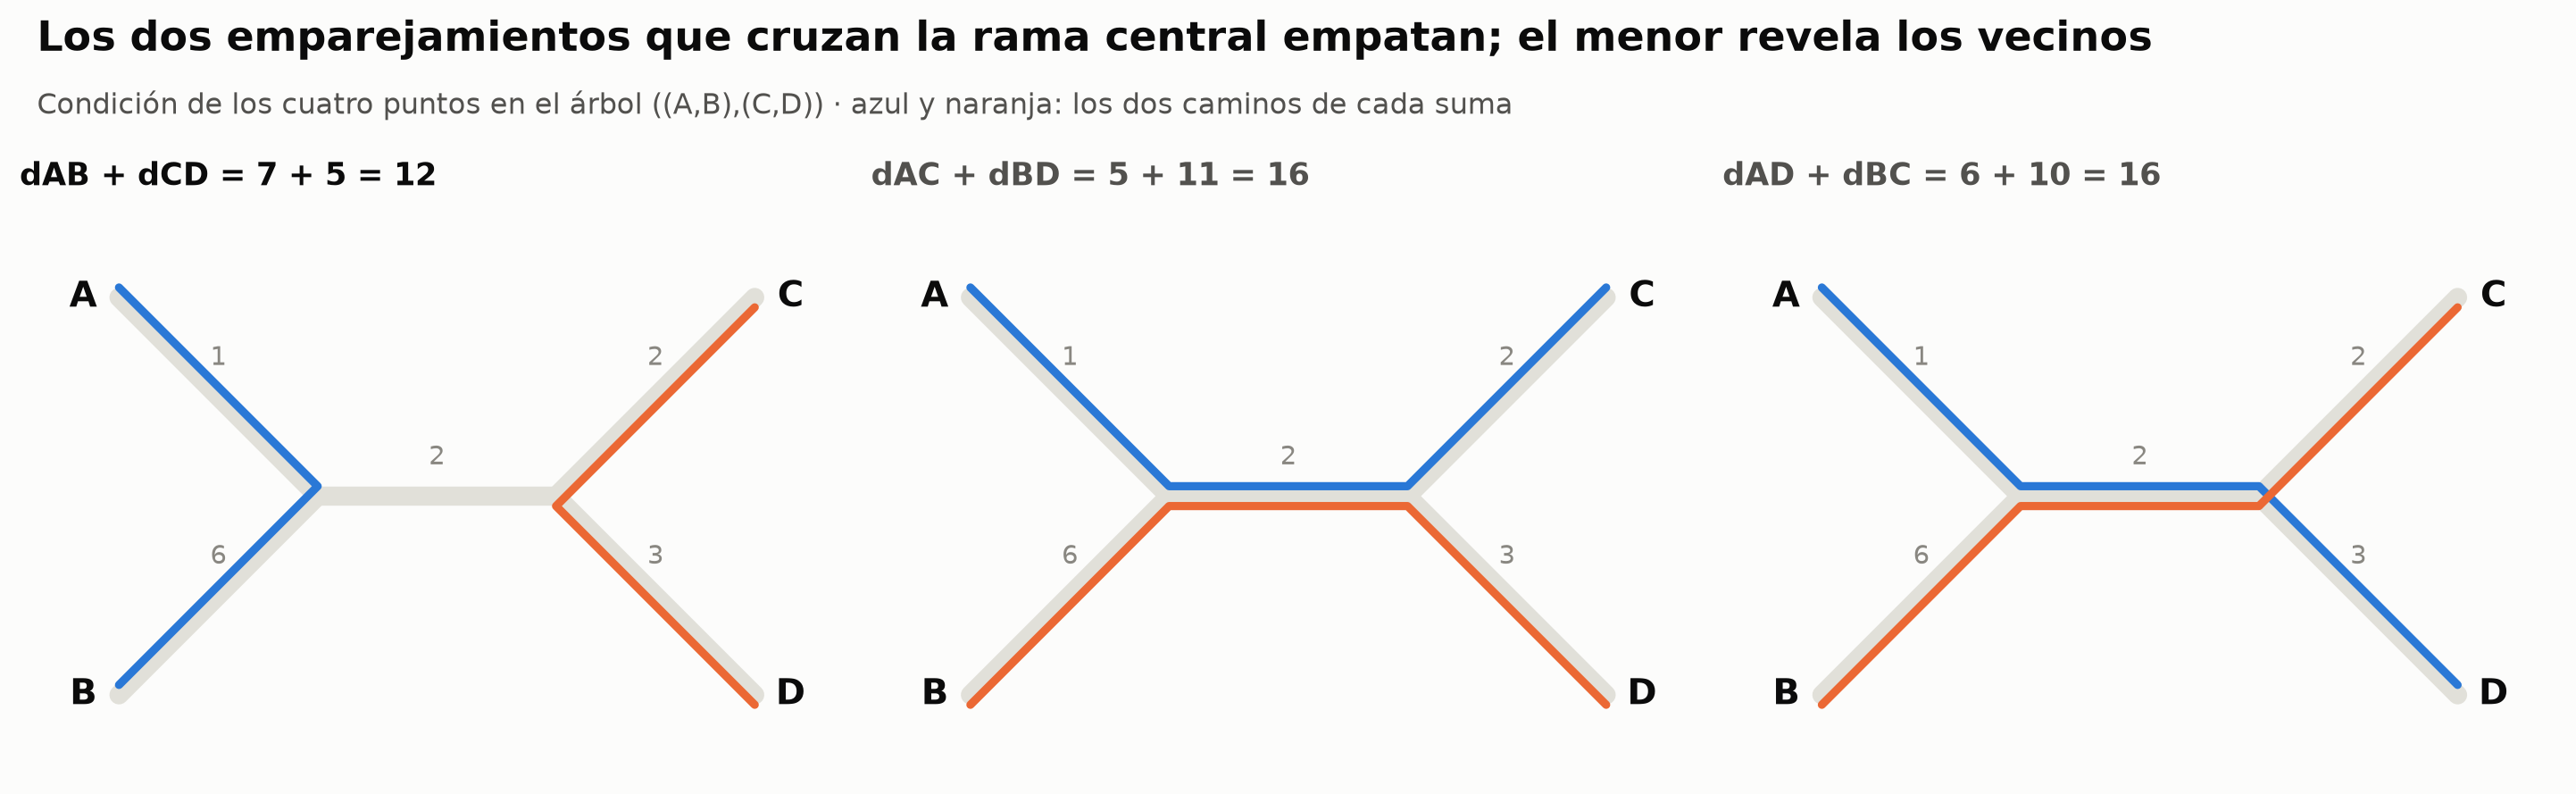

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
P4 = {"A": (-1.6, 1), "B": (-1.6, -1), "u": (-0.6, 0), "v": (0.6, 0), "C": (1.6, 1), "D": (1.6, -1)}
edges4 = [("A", "u", 1), ("B", "u", 6), ("u", "v", 2), ("v", "C", 2), ("v", "D", 3)]
path = {("A", "B"): ["A", "u", "B"], ("C", "D"): ["C", "v", "D"], ("A", "C"): ["A", "u", "v", "C"],
        ("B", "D"): ["B", "u", "v", "D"], ("A", "D"): ["A", "u", "v", "D"], ("B", "C"): ["B", "u", "v", "C"]}
pairings = [(("A", "B"), ("C", "D"), 12), (("A", "C"), ("B", "D"), 16), (("A", "D"), ("B", "C"), 16)]
for ax, (p1, p2, total) in zip(axes, pairings):
    for a, b, l in edges4:
        (x1, y1), (x2, y2) = P4[a], P4[b]
        ax.plot([x1, x2], [y1, y2], color=ec.GRID, lw=7, solid_capstyle="round", zorder=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.16, str(l), ha="center", fontsize=9.5, color=ec.MUTED)
    for p, col, off in [(p1, ec.BLUE, 0.05), (p2, ec.ORANGE, -0.05)]:
        nodes = path[p]
        xs, ys = [P4[n][0] for n in nodes], [P4[n][1] + off for n in nodes]
        ax.plot(xs, ys, color=col, lw=3, solid_capstyle="round", zorder=2)
    for leaf in "ABCD":
        x, y = P4[leaf]
        ax.text(x + (-0.18 if x < 0 else 0.18), y, leaf, ha="center", va="center", fontsize=13, fontweight="bold")
    d1 = {"AB": 7, "CD": 5, "AC": 5, "BD": 11, "AD": 6, "BC": 10}
    ax.set_title(f"d{p1[0]}{p1[1]} + d{p2[0]}{p2[1]} = {d1[''.join(p1)]} + {d1[''.join(p2)]} = {total}",
                 loc="left", fontsize=11.5, color=ec.INK if total == 12 else ec.INK_2)
    ax.set_xlim(-2.1, 2.1); ax.set_ylim(-1.4, 1.4); ax.set_aspect("equal"); ax.axis("off")
ec.fig_title(fig, "Los dos emparejamientos que cruzan la rama central empatan; el menor revela los vecinos",
             "Condición de los cuatro puntos en el árbol ((A,B),(C,D)) · azul y naranja: los dos caminos de cada suma")
plt.show()

Ahora lo programamos. Para medir **cuánto** se aparta una matriz real de cada condición calculamos, para cada trío (o
cuarteto), la diferencia **relativa** entre los dos valores mayores: 0 significa que la condición se cumple
exactamente.

In [12]:
def three_point_deviation(D):
    """Para cada trío: (mayor − segunda mayor) / mayor. 0 en todos los tríos ⇔ ultramétrica."""
    out = []
    for i, j, k in itertools.combinations(range(len(D)), 3):
        a = sorted([D[i][j], D[i][k], D[j][k]])
        out.append((a[2] - a[1]) / a[2] if a[2] > 0 else 0.0)
    return np.array(out)

def four_point_deviation(D):
    """Para cada cuarteto: (mayor − segunda mayor) / mayor de las tres sumas. 0 en todos ⇔ aditiva."""
    out = []
    for i, j, k, l in itertools.combinations(range(len(D)), 4):
        s = sorted([D[i][j] + D[k][l], D[i][k] + D[j][l], D[i][l] + D[j][k]])
        out.append((s[2] - s[1]) / s[2] if s[2] > 0 else 0.0)
    return np.array(out)

def matrix_from_pairs(names, pairs):
    """Matriz simétrica a partir de un diccionario {'AB': d, ...}."""
    D = np.zeros((len(names), len(names)))
    for key, v in pairs.items():
        i, j = names.index(key[0]), names.index(key[1])
        D[i, j] = D[j, i] = v
    return D

TAXA5 = list("ABCDE")
# Matriz ADITIVA del árbol (A:1, B:6)–2–(C:2)–2–(D:1, E:3): la usaremos en las secciones 6 y 7
D_add = matrix_from_pairs(TAXA5, {"AB": 7, "AC": 5, "AD": 6, "AE": 8, "BC": 10, "BD": 11, "BE": 13,
                                  "CD": 5, "CE": 7, "DE": 4})
# Matriz de los simios: distancia = 2 × tiempo desde el ancestro común (reloj perfecto)
APES = ["Humano", "Chimpancé", "Gorila", "Orangután", "Macaco"]
D_apes = np.array([[0, 13, 18, 31, 58], [13, 0, 18, 31, 58], [18, 18, 0, 31, 58],
                   [31, 31, 31, 0, 58], [58, 58, 58, 58, 0]], float)
for label, M in [("simios (reloj)", D_apes), ("aditiva de 5 taxones", D_add)]:
    t3, t4 = three_point_deviation(M), four_point_deviation(M)
    print(f"{label:22s} tríos que violan 3 puntos: {np.sum(t3 > 1e-9)}/{len(t3)}   "
          f"cuartetos que violan 4 puntos: {np.sum(t4 > 1e-9)}/{len(t4)}")

simios (reloj)         tríos que violan 3 puntos: 0/10   cuartetos que violan 4 puntos: 0/5
aditiva de 5 taxones   tríos que violan 3 puntos: 10/10   cuartetos que violan 4 puntos: 0/5


> 🔎 **Qué observamos.** La matriz de los simios cumple **ambas** condiciones: es ultramétrica (y, por lo tanto,
> también aditiva). La matriz de cinco taxones cumple la de los cuatro puntos en los 5 cuartetos, pero viola la de los
> tres puntos en los 10 tríos: es un árbol perfecto **sin reloj**. Retenga esta distinción, porque es la clave de toda
> la clase:
>
> * **UPGMA** supone (en silencio) que la matriz es **ultramétrica**.
> * **Neighbor-Joining** sólo supone que es (aproximadamente) **aditiva**.
>
> Las matrices reales no cumplen ninguna de las dos exactamente (hay error de muestreo y el modelo de distancia es
> imperfecto); en la sección 11 mediremos cuánto se apartan en datos reales.

✅ **Compruebe su comprensión.** Si todas las hojas de un árbol están a la misma distancia de la raíz, ¿por qué en
cualquier trío las dos distancias mayores deben ser iguales? (Pista: dibuje el trío; dos de las hojas se separaron
más recientemente que la tercera.)

## 5. UPGMA paso a paso

**UPGMA** (*Unweighted Pair Group Method with Arithmetic mean*; Sokal y Michener, 1958) es el método de agrupamiento
jerárquico más simple, y ya lo usamos como árbol guía en la Lección 4.1. Su lógica es la de alguien que organiza una
fiesta por mesas: primero sienta juntos a los dos invitados más afines; después trata a esa pareja como una sola
"mesa" cuya afinidad con cada invitado es el **promedio** de sus miembros, y repite hasta que todos quedan en una sola
mesa.

1. Buscar el par de grupos $A$, $B$ con la **menor distancia** $d(A,B)$ y unirlos en un grupo nuevo $AB$.
2. Colocar el nodo nuevo a una **altura** $h(AB) = d(A,B)/2$. Las longitudes de las dos ramas nuevas son la diferencia
   de alturas: $h(AB) - h(A)$ y $h(AB) - h(B)$ (las hojas tienen altura 0).
3. Calcular la distancia del grupo nuevo a cada grupo restante $C$ como el **promedio de todas las distancias entre
   sus miembros** (ponderado por el tamaño de cada grupo):

$$
d(AB,\,C) \;=\; \frac{|A|\,d(A,C) \;+\; |B|\,d(B,C)}{|A|+|B|},
\qquad
h(AB) \;=\; \frac{d(A,B)}{2},
\qquad
\ell_A \;=\; h(AB) - h(A)
$$

4. Repetir hasta que quede un solo grupo: ésa es la raíz.

| Símbolo | Significado |
|---|---|
| $A, B, C$ | grupos (al inicio, cada especie es un grupo de tamaño 1) |
| $\lvert A\rvert$ | número de especies en el grupo $A$ |
| $d(A,C)$ | distancia promedio entre los miembros de $A$ y los de $C$ |
| $h(AB)$ | altura del nodo nuevo: la mitad de la distancia a la que se unen los grupos |
| $\ell_A$ | longitud de la rama que une el grupo $A$ con el nodo nuevo |

Como cada hoja queda a la altura $h$ de sus ancestros, **todas las hojas quedan a la misma distancia de la raíz**: el
árbol de UPGMA es **ultramétrico por construcción**. Ésa es su fuerza (da un árbol con raíz y con "reloj") y su
debilidad (sección 6).

### UPGMA a mano con cinco taxones

| | A | B | C | D | E |
|---|---|---|---|---|---|
| **A** | 0 | **4** | 10 | 16 | 16 |
| **B** | | 0 | 12 | 18 | 16 |
| **C** | | | 0 | 15 | 15 |
| **D** | | | | 0 | 6 |

**Fusión 1.** El mínimo es $d(A,B) = 4$ → nodo $AB$ a altura $2$; ramas $\ell_A = \ell_B = 2$. Nuevas distancias:
$d(AB,C) = (10+12)/2 = 11$, $d(AB,D) = (16+18)/2 = 17$, $d(AB,E) = (16+16)/2 = 16$.

| | AB | C | D | E |
|---|---|---|---|---|
| **AB** | 0 | 11 | 17 | 16 |
| **C** | | 0 | 15 | 15 |
| **D** | | | 0 | **6** |

**Fusión 2.** El mínimo es $d(D,E) = 6$ → nodo $DE$ a altura $3$; $\ell_D = \ell_E = 3$.
$d(DE, AB) = (17+16)/2 = 16.5$, $d(DE, C) = (15+15)/2 = 15$.

| | AB | C | DE |
|---|---|---|---|
| **AB** | 0 | **11** | 16.5 |
| **C** | | 0 | 15 |

**Fusión 3.** El mínimo es $d(AB, C) = 11$ → nodo $ABC$ a altura $5.5$; $\ell_{AB} = 5.5 - 2 = 3.5$, $\ell_C = 5.5$.
Ahora el promedio **ponderado**: $AB$ tiene dos miembros y $C$ uno, así que
$d(ABC, DE) = (2 \times 16.5 + 1 \times 15)/3 = 48/3 = 16$.

**Fusión 4.** Se unen $ABC$ y $DE$ a $d = 16$ → raíz a altura $8$; $\ell_{ABC} = 8 - 5.5 = 2.5$, $\ell_{DE} = 8 - 3 = 5$.

Resultado en Newick: `((D:3,E:3):5,(C:5.5,(A:2,B:2):3.5):2.5);`. Verifique que cada hoja está a distancia 8 de la raíz.

In [13]:
def upgma(D, names, weighted=False):
    """UPGMA (o WPGMA si weighted=True). Devuelve (árbol con raíz, lista de pasos para animar/inspeccionar)."""
    n = len(names)
    node = {i: Node(names[i]) for i in range(n)}                  # grupo → subárbol
    size = {i: 1 for i in range(n)}
    height = {i: 0.0 for i in range(n)}
    dist = {frozenset((i, j)): float(D[i][j]) for i, j in itertools.combinations(range(n), 2)}
    active, steps, nxt = list(range(n)), [], n
    while len(active) > 1:
        d_min, a, b = min((dist[frozenset((a, b))], a, b) for a, b in itertools.combinations(active, 2))
        h = d_min / 2
        node[a].length, node[b].length = h - height[a], h - height[b]
        new = nxt; nxt += 1
        node[new] = Node(children=[node[a], node[b]])
        size[new], height[new] = size[a] + size[b], h
        steps.append(dict(active=list(active), dist=dict(dist), a=a, b=b, new=new, d=d_min,
                          node=node[new], members={g: node[g].leaves() for g in active}))
        active = [c for c in active if c not in (a, b)]
        for c in active:
            if weighted:        # WPGMA: promedio simple de los dos grupos, sin importar su tamaño
                v = (dist[frozenset((a, c))] + dist[frozenset((b, c))]) / 2
            else:               # UPGMA: promedio de TODOS los pares de miembros
                v = (size[a] * dist[frozenset((a, c))] + size[b] * dist[frozenset((b, c))]) / size[new]
            dist[frozenset((new, c))] = v
        active.append(new)
    root = node[active[0]]; root.length = 0.0
    return root, steps

D_upgma = matrix_from_pairs(TAXA5, {"AB": 4, "AC": 10, "AD": 16, "AE": 16, "BC": 12, "BD": 18, "BE": 16,
                                    "CD": 15, "CE": 15, "DE": 6})
tree_u, steps_u = upgma(D_upgma, TAXA5)
for k, s in enumerate(steps_u, 1):
    print(f"Fusión {k}: {'+'.join(s['members'][s['a']])} con {'+'.join(s['members'][s['b']])} "
          f"a d = {s['d']:g}  → altura {s['d'] / 2:g}")
print("\nNewick:", to_newick(tree_u))
Z = linkage(squareform(D_upgma), method="average")        # UPGMA de SciPy ('average')
print("Distancias de fusión · nuestro UPGMA:", [s["d"] for s in steps_u], "· SciPy:", Z[:, 2].tolist())

Fusión 1: A con B a d = 4  → altura 2
Fusión 2: D con E a d = 6  → altura 3
Fusión 3: C con A+B a d = 11  → altura 5.5
Fusión 4: D+E con C+A+B a d = 16  → altura 8

Newick: ((D:3,E:3):5,(C:5.5,(A:2,B:2):3.5):2.5);
Distancias de fusión · nuestro UPGMA: [4.0, 6.0, 11.0, 16.0] · SciPy: [4.0, 6.0, 11.0, 16.0]


> 🔎 **Qué observamos.** El código reproduce la cuenta a mano fusión por fusión, y las distancias de fusión coinciden
> con `scipy.cluster.hierarchy.linkage(..., method="average")`, que es UPGMA con otro nombre. Guardamos cada paso
> (grupos activos, distancias, par elegido) para poder animarlo.

### 🎬 UPGMA en acción

A la izquierda, la matriz de distancias **entre los grupos que siguen activos**: el recuadro negro marca el mínimo.
A la derecha, el árbol crece **desde las hojas hacia la raíz**; el eje horizontal es la altura de cada nodo.

![Vista previa: UPGMA une los dos grupos más cercanos, promedia distancias y el árbol crece de las hojas a la raíz](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-05-filogenetica/5.2_upgma.gif)

*Vista previa: UPGMA une los dos grupos más cercanos, promedia distancias y el árbol crece de las hojas a la raíz*

In [14]:
pos_u = rooted_layout(tree_u)
H = max(x for x, _ in pos_u.values())                     # distancia raíz–hojas (8)

def draw_partial_tree(ax, tree, pos, built, highlight=None, fs=12):
    """Dibuja sólo los nodos internos ya construidos (los demás aún no existen)."""
    for nd in tree.nodes():
        if nd.is_leaf() or id(nd) not in built:
            continue
        x, y = pos[id(nd)]
        col = ec.ORANGE if id(nd) == highlight else ec.INK_2
        lw = 3.2 if id(nd) == highlight else 2.2
        ys = [pos[id(c)][1] for c in nd.children]
        ax.plot([x, x], [min(ys), max(ys)], color=col, lw=lw)
        for c in nd.children:
            ax.plot([x, pos[id(c)][0]], [pos[id(c)][1]] * 2, color=col, lw=lw)
        ax.plot(x, y, "o", color=col, ms=6, zorder=3)
    for leaf in tree.nodes():
        if leaf.is_leaf():
            x, y = pos[id(leaf)]
            ax.plot(x, y, "o", color=ec.INK_2, ms=5)
            ax.text(x + 0.25, y, leaf.name, va="center", fontsize=fs, fontweight="bold")

frames_u = []
for s in range(len(steps_u)):
    frames_u += [(s, "min"), (s, "merged")]
frames_u += [(len(steps_u) - 1, "merged")] * 2

fig, (ax_m, ax_t) = plt.subplots(1, 2, figsize=(12, 5.2), width_ratios=[1, 1.1])

def update(f):
    ax_m.clear(); ax_t.clear()
    s, phase = frames_u[f]
    st = steps_u[s]
    if phase == "min":                                     # la matriz antes de fusionar
        active, dist, members = st["active"], st["dist"], st["members"]
    else:                                                  # la matriz después de fusionar
        if s + 1 < len(steps_u):
            nx = steps_u[s + 1]; active, dist, members = nx["active"], nx["dist"], nx["members"]
        else:
            active, dist, members = [st["new"]], {}, {st["new"]: st["node"].leaves()}
    labels = ["".join(members[g]) for g in active]
    m = len(active)
    if m == 1:                                             # fin: ya no queda matriz
        ax_m.axis("off")
        ax_m.text(0.5, 0.5, f"Un solo grupo: {labels[0]}\nraíz a altura {st['d'] / 2:g}", ha="center",
                  va="center", fontsize=14, color=ec.INK_2, transform=ax_m.transAxes)
        ax_m.set_title(f"Paso {s + 1}: la última fusión es la raíz", loc="left", fontsize=11.5)
    M = np.array([[0 if a == b else dist[frozenset((a, b))] for b in active] for a in active]) if m > 1 else np.zeros((1, 1))
    if m > 1:
        ax_m.imshow(M, cmap="curso_seq", vmin=0, vmax=20)
    for i in range(m if m > 1 else 0):
        for j in range(m):
            ax_m.text(j, i, f"{M[i, j]:g}", ha="center", va="center", fontsize=12,
                      color=ec.SURFACE if M[i, j] > 12 else ec.INK)
    if phase == "min":
        i, j = active.index(st["a"]), active.index(st["b"])
        for r, c in [(i, j), (j, i)]:
            ax_m.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor=ec.INK, lw=3))
        msg = f"Paso {s + 1}: mínimo d({labels[i]}, {labels[j]}) = {st['d']:g}"
    else:
        msg = f"Paso {s + 1}: grupo nuevo y distancias promediadas"
    if m > 1:
        ax_m.set_xticks(range(m)); ax_m.set_xticklabels(labels, fontsize=11)
        ax_m.set_yticks(range(m)); ax_m.set_yticklabels(labels, fontsize=11)
        ax_m.grid(False); ax_m.set_title(msg, loc="left", fontsize=11.5)
    built = {id(steps_u[k]["node"]) for k in range(s + (phase == "merged"))}
    draw_partial_tree(ax_t, tree_u, pos_u, built, highlight=id(st["node"]) if phase == "merged" else None)
    ax_t.set_xlim(-0.4, H + 1.3); ax_t.set_ylim(4.6, -0.6)
    ax_t.set_xticks([H - h for h in range(0, 9, 2)]); ax_t.set_xticklabels(range(0, 9, 2))
    ax_t.set_xlabel("altura del nodo = distancia de fusión / 2")
    ax_t.set_yticks([]); ax_t.spines["left"].set_visible(False); ax_t.grid(False)
    ax_t.set_title(f"Árbol: {len(built)} de {len(steps_u)} nodos internos", loc="left", fontsize=11.5)
    return ()

ec.animate(fig, update, frames=len(frames_u), interval=1200, name="5.2_upgma")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En cada paso la matriz pierde una fila y una columna (dos grupos desaparecen y aparece uno
> nuevo), y la altura de las fusiones **nunca baja**: 2, 3, 5.5, 8. Las cinco hojas terminan alineadas a la derecha,
> todas a distancia 8 de la raíz. Fíjese en la fusión 3: el grupo $AB$ pesa el doble que $C$ en el promedio siguiente.
> Si en lugar de ponderar por tamaño promediáramos los dos grupos por igual obtendríamos **WPGMA** (*Weighted* PGMA),
> un método distinto que volverá a aparecer en la sección 8.

✅ **Compruebe su comprensión.** En la fusión 3, ¿qué distancia $d(ABC, DE)$ obtendría WPGMA? ¿A qué altura quedaría
la raíz?

## 6. Por qué UPGMA falla cuando las tasas son desiguales

UPGMA une primero a los dos taxones **más parecidos** y da por hecho que "más parecidos" significa "separados más
recientemente". Eso sólo es cierto si todos los linajes cambian a la **misma velocidad** (un reloj molecular). En la
vida real no es así: un parásito, una especie con generaciones muy cortas o un gen que perdió su función acumulan
cambios mucho más rápido que sus parientes.

Piense en dos hermanos gemelos: uno se queda en casa y el otro se muda a otro país, aprende otro idioma y cambia de
costumbres. Si usted agrupara a las personas "por parecido", pondría al gemelo que se quedó junto a sus primos antes
que junto a su hermano. El parecido mezcla **dos** cosas: el **tiempo** desde el ancestro común y la **velocidad** de
cambio de cada linaje.

### El ejemplo a mano

Volvamos a la matriz **aditiva** de la sección 4, que proviene de este árbol sin raíz: la hoja $B$ tiene una rama
**larga** (6) y su hermana $A$ una rama corta (1).

```
A:1 ─┐          ┌─ C:2
     ├─── 2 ────┤
B:6 ─┘          └── 2 ──┬─ D:1
                        └─ E:3
```

| | A | B | C | D | E |
|---|---|---|---|---|---|
| **A** | 0 | 7 | 5 | 6 | 8 |
| **B** | | 0 | 10 | 11 | 13 |
| **C** | | | 0 | 5 | 7 |
| **D** | | | | 0 | **4** |

* **Fusión 1.** $d(D,E) = 4$ es el mínimo → $DE$. (Correcto: $D$ y $E$ sí son vecinos.)
  $d(DE,A) = (6+8)/2 = 7$, $d(DE,B) = (11+13)/2 = 12$, $d(DE,C) = (5+7)/2 = 6$.
* **Fusión 2.** Ahora el mínimo es $d(A,C) = 5$ → $AC$. **¡Error!** El vecino verdadero de $A$ es $B$, pero
  $d(A,B) = 7$ es "grande" porque la rama de $B$ es larga. UPGMA confunde "cambió mucho" con "se separó hace mucho".

Ningún paso posterior puede deshacer esta fusión: UPGMA es un algoritmo **voraz** (*greedy*).

In [15]:
def splits(tree):
    """Biparticiones no triviales de un árbol, como conjuntos de hojas (el lado sin la primera hoja en orden alfabético).
    Dos árboles tienen la misma topología sin raíz si y sólo si tienen las mismas biparticiones (sección 10)."""
    taxa = frozenset(tree.leaves()); ref = min(taxa)
    out = set()
    for nd in tree.nodes():
        s = frozenset(nd.leaves())
        side = s if ref not in s else taxa - s
        if 1 < len(side) < len(taxa) - 1:
            out.add(side)
    return out

def robinson_foulds(t1, t2):
    """Número de biparticiones presentes en un árbol y no en el otro (0 = misma topología sin raíz)."""
    return len(splits(t1) ^ splits(t2))

true_add = parse_newick("(D:1,E:3,(C:2,(A:1,B:6):2):2);")
tree_u_add, _ = upgma(D_add, TAXA5)
print("Árbol verdadero :", to_newick(true_add))
print("UPGMA           :", to_newick(tree_u_add))
print("Biparticiones verdaderas:", sorted(sorted(s) for s in splits(true_add)))
print("Biparticiones de UPGMA  :", sorted(sorted(s) for s in splits(tree_u_add)))
print("Robinson-Foulds (0 = idénticos):", robinson_foulds(true_add, tree_u_add))

Árbol verdadero : (D:1,E:3,(C:2,(A:1,B:6):2):2);
UPGMA           : (B:5.125,((D:2,E:2):1.25,(A:2.5,C:2.5):0.75):1.875);
Biparticiones verdaderas: [['C', 'D', 'E'], ['D', 'E']]
Biparticiones de UPGMA  : [['B', 'D', 'E'], ['D', 'E']]
Robinson-Foulds (0 = idénticos): 2


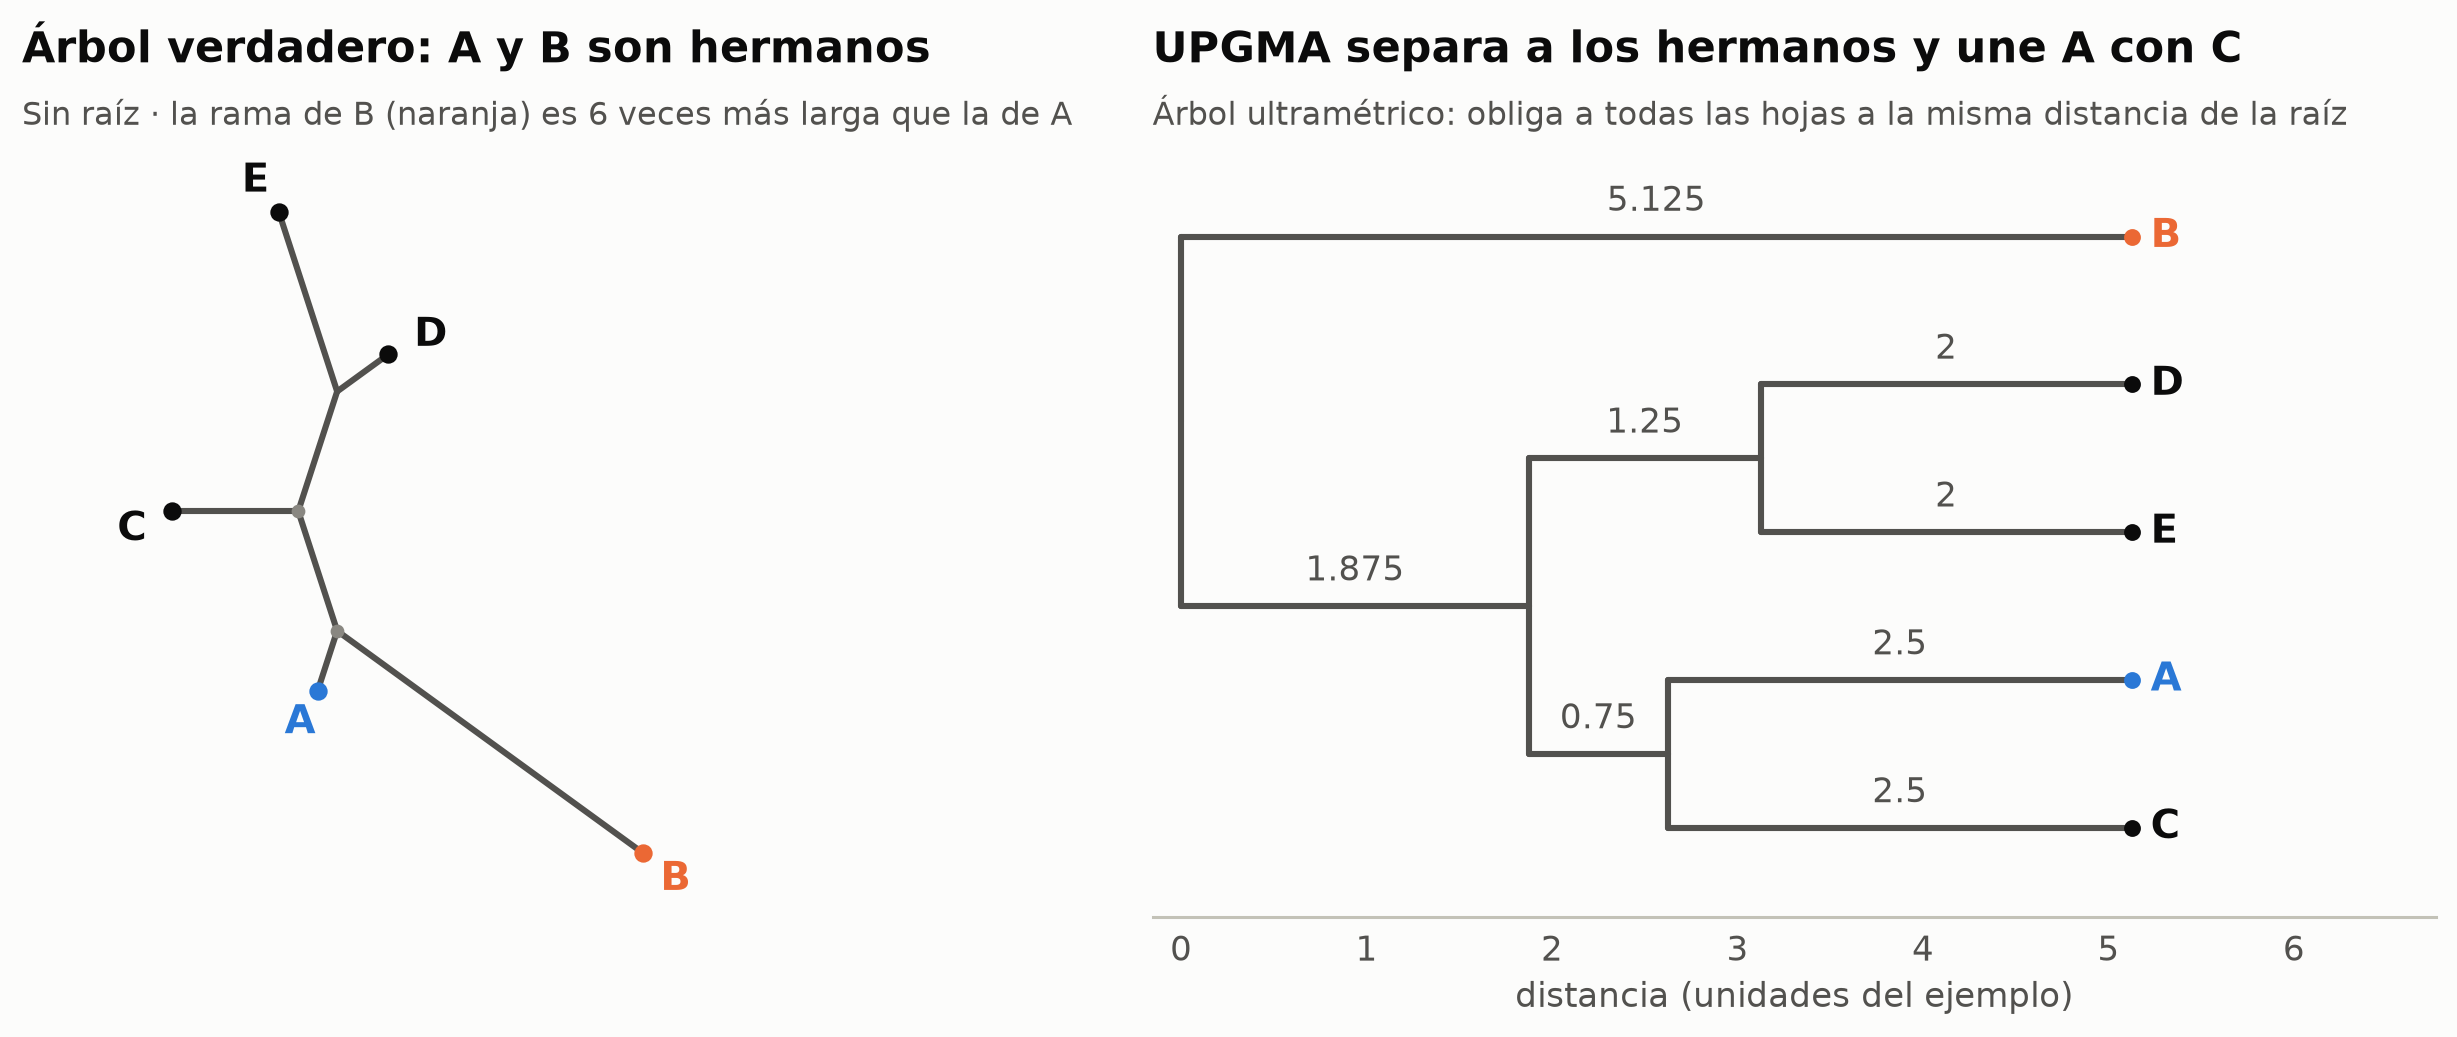

In [16]:
leaf_col = {"A": ec.BLUE, "B": ec.ORANGE, "C": ec.INK, "D": ec.INK, "E": ec.INK}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), width_ratios=[1, 1.15])
draw_unrooted(ax1, true_add, label_colors=leaf_col, fs=13, pad=0.07)
ec.title(ax1, "Árbol verdadero: A y B son hermanos", "Sin raíz · la rama de B (naranja) es 6 veces más larga que la de A")
draw_tree(ax2, tree_u_add, label_colors=leaf_col, fs=13, show_lengths=True, xlabel="distancia (unidades del ejemplo)")
ec.title(ax2, "UPGMA separa a los hermanos y une A con C", "Árbol ultramétrico: obliga a todas las hojas a la misma distancia de la raíz")
plt.show()

> 🔎 **Qué observamos.** En el árbol verdadero (izquierda) $A$ y $B$ salen del mismo nodo, pero $B$ está lejísimos
> por su rama larga. UPGMA (derecha) pone a $B$ solo, fuera de todos, y agrupa $A$ con $C$: la bipartición
> $\{A,B\} \mid \{C,D,E\}$ se perdió y apareció una falsa, $\{A,C\} \mid \{B,D,E\}$. Además, UPGMA "estira" todas las
> ramas para que las hojas queden alineadas: las longitudes que muestra no son las verdaderas (la de $A$ vale 2.5 en
> lugar de 1).

Necesitamos un método que **no** suponga reloj: que corrija la distancia entre dos taxones descontando cuánto se
alejan, en promedio, de **todos** los demás. Eso es Neighbor-Joining.

✅ **Compruebe su comprensión.** Si la rama de $B$ midiera 1 en lugar de 6 (todas las demás iguales), ¿cuál sería el
primer par que une UPGMA? ¿Acertaría la topología?

## 7. Neighbor-Joining: la matriz $Q$

**Neighbor-Joining** (NJ; Saitou y Nei, 1987) es probablemente el método de distancias más usado de la historia. Su
idea central es buscar **vecinos** (dos hojas que cuelgan del mismo nodo), no "los más parecidos". Para eso corrige
cada distancia $d_{ij}$ restando cuánto se alejan $i$ y $j$ de **todos** los demás:

* Si $i$ tiene una rama larga, estará lejos de **todos**: su suma de distancias $r_i$ será grande.
* Restar $r_i + r_j$ "descuenta" esa lejanía general. Lo que queda mide si $i$ y $j$ están cerca **entre sí más de lo
  esperado** por su velocidad propia.

Es lo mismo que haría un profesor que compara las notas de dos estudiantes: si uno de ellos califica siempre bajo en
todo, no concluye que es "distinto" de su compañero de grupo sólo por eso; primero descuenta su promedio general.

### Las ecuaciones

En cada iteración, con $n$ nodos activos:

$$
r_i = \sum_{k=1}^{n} d_{ik},
\qquad
Q(i,j) \;=\; (n-2)\,d_{ij} \;-\; r_i \;-\; r_j
$$

Se unen los dos nodos $i, j$ con el **menor** $Q(i,j)$ en un nodo nuevo $u$. Las ramas nuevas miden

$$
\delta_{iu} \;=\; \frac{d_{ij}}{2} \;+\; \frac{r_i - r_j}{2\,(n-2)},
\qquad
\delta_{ju} \;=\; d_{ij} - \delta_{iu},
$$

y las distancias del nodo nuevo al resto son

$$
d_{uk} \;=\; \frac{d_{ik} + d_{jk} - d_{ij}}{2}.
$$

Cuando quedan **tres** nodos se unen a un centro común con $\delta_{i} = (d_{ij} + d_{ik} - d_{jk})/2$ (y análogas).

| Símbolo | Significado |
|---|---|
| $n$ | número de nodos **activos** en la iteración actual (empieza en el número de especies) |
| $d_{ij}$ | distancia entre los nodos activos $i$ y $j$ |
| $r_i$ | suma de las distancias de $i$ a todos los demás: "qué tan lejos está de todo" |
| $Q(i,j)$ | distancia corregida; su mínimo señala un par de **vecinos** |
| $u$ | nodo interno nuevo, ancestro de $i$ y $j$ |
| $\delta_{iu}$ | longitud de la rama de $i$ a $u$: la mitad de $d_{ij}$ más una corrección por la diferencia de velocidades |
| $d_{uk}$ | distancia del nodo nuevo a cada nodo $k$ restante: lo que queda de $d_{ik}$ y $d_{jk}$ tras quitar las ramas nuevas |

Saitou y Nei lo presentaron como una **descomposición de una estrella**: se empieza con todas las hojas colgando de un
solo centro y, en cada paso, se "saca" del centro el par cuya separación acorta más el árbol total. Studier y Keppler
(1988) mostraron que ese criterio equivale a minimizar $Q$ y que el algoritmo corre en tiempo $O(n^3)$. Una propiedad
fundamental: **si la matriz es aditiva, NJ recupera el árbol verdadero con sus longitudes exactas.**

### Neighbor-Joining a mano

Usamos la misma matriz aditiva que engañó a UPGMA. **Iteración 1** ($n = 5$, así que $n-2 = 3$). Primero las sumas de
fila: $r_A = 7+5+6+8 = 26$, $r_B = 41$, $r_C = 27$, $r_D = 26$, $r_E = 32$. Luego, por ejemplo,
$Q(A,B) = 3 \times 7 - 26 - 41 = -46$ y $Q(A,C) = 3 \times 5 - 26 - 27 = -38$.

| $Q$ | A | B | C | D | E |
|---|---|---|---|---|---|
| **A** | | **−46** | −38 | −34 | −34 |
| **B** | | | −38 | −34 | −34 |
| **C** | | | | −38 | −38 |
| **D** | | | | | **−46** |

¡Ahora $A$ y $B$ **sí** aparecen como vecinos! Hay un empate con $(D,E)$: ambos pares son vecinos verdaderos, así que
cualquiera sirve; tomamos el primero, $(A,B)$. Las ramas:

$$
\delta_{A} = \frac{7}{2} + \frac{26 - 41}{2 \times 3} = 3.5 - 2.5 = 1,
\qquad
\delta_{B} = 7 - 1 = 6 .
$$

¡Exactamente las ramas verdaderas! La corrección $(r_A - r_B)/(2(n-2))$ detectó que $B$ es el "rápido". Distancias
del nodo nuevo $u$: $d_{uC} = (5 + 10 - 7)/2 = 4$, $d_{uD} = (6 + 11 - 7)/2 = 5$, $d_{uE} = (8 + 13 - 7)/2 = 7$.

**Iteración 2** ($n = 4$, $n-2 = 2$). Matriz $\{u, C, D, E\}$: $d_{uC}=4$, $d_{uD}=5$, $d_{uE}=7$, $d_{CD}=5$,
$d_{CE}=7$, $d_{DE}=4$. Sumas: $r_u = 16$, $r_C = 16$, $r_D = 14$, $r_E = 18$.
$Q(u,C) = 2 \times 4 - 16 - 16 = -24$ (mínimo, empatado con $Q(D,E) = -24$) → nodo $v$ con
$\delta_u = 4/2 + (16-16)/4 = 2$ y $\delta_C = 2$. Distancias: $d_{vD} = (5+5-4)/2 = 3$, $d_{vE} = (7+7-4)/2 = 5$.

**Final** (tres nodos $v, D, E$): $\delta_v = (3 + 5 - 4)/2 = 2$, $\delta_D = (3 + 4 - 5)/2 = 1$,
$\delta_E = (5 + 4 - 3)/2 = 3$. **Todas las ramas coinciden con el árbol verdadero.**

In [17]:
def neighbor_joining(D, names):
    """Neighbor-Joining (Saitou y Nei, 1987; forma de Studier y Keppler, 1988).
    Devuelve (árbol sin raíz con un nodo central de grado 3, pasos para inspeccionar/animar)."""
    n0 = len(names)
    node = {i: Node(names[i]) for i in range(n0)}
    d = {(i, j): float(D[i][j]) for i in range(n0) for j in range(n0)}
    active, steps, nxt = list(range(n0)), [], n0
    while len(active) > 3:
        n = len(active)
        r = {i: sum(d[i, k] for k in active if k != i) for i in active}
        Q = {(i, j): (n - 2) * d[i, j] - r[i] - r[j] for i, j in itertools.combinations(active, 2)}
        i, j = min(Q, key=Q.get)                                   # el par de vecinos
        li = d[i, j] / 2 + (r[i] - r[j]) / (2 * (n - 2))
        node[i].length, node[j].length = li, d[i, j] - li
        u = nxt; nxt += 1
        node[u] = Node(children=[node[i], node[j]])
        steps.append(dict(active=list(active), nodes=[node[k] for k in active], d=dict(d), r=r, Q=Q,
                          i=i, j=j, u=node[u], li=li, lj=d[i, j] - li))
        for k in active:
            if k not in (i, j):
                d[u, k] = d[k, u] = (d[i, k] + d[j, k] - d[i, j]) / 2
        d[u, u] = 0.0
        active = [k for k in active if k not in (i, j)] + [u]
    a, b, c = active                                               # los tres últimos, a un centro común
    node[a].length = (d[a, b] + d[a, c] - d[b, c]) / 2
    node[b].length = (d[a, b] + d[b, c] - d[a, c]) / 2
    node[c].length = (d[a, c] + d[b, c] - d[a, b]) / 2
    root = Node(children=[node[a], node[b], node[c]]); root.length = 0.0
    steps.append(dict(active=list(active), nodes=[node[k] for k in active], final=True))
    return root, steps

tree_nj_add, steps_nj_add = neighbor_joining(D_add, TAXA5)
s0 = steps_nj_add[0]
Q0 = pd.DataFrame(np.nan, index=TAXA5, columns=TAXA5)
for (i, j), q in s0["Q"].items():
    Q0.iloc[i, j] = q
print("Sumas de fila r:", {TAXA5[i]: v for i, v in s0["r"].items()})
print("Matriz Q de la iteración 1:"); print(Q0.fillna("").to_string())
print(f"\nPrimer par: {TAXA5[s0['i']]},{TAXA5[s0['j']]} · ramas {s0['li']:g} y {s0['lj']:g}")
print("Árbol NJ       :", to_newick(tree_nj_add))
print("Árbol verdadero:", to_newick(true_add))
print("Robinson-Foulds NJ vs verdadero:", robinson_foulds(tree_nj_add, true_add))

Sumas de fila r: {'A': 26.0, 'B': 41.0, 'C': 27.0, 'D': 26.0, 'E': 32.0}
Matriz Q de la iteración 1:
  A     B     C     D     E
A   -46.0 -38.0 -34.0 -34.0
B         -38.0 -34.0 -34.0
C               -38.0 -38.0
D                     -46.0
E                          

Primer par: A,B · ramas 1 y 6
Árbol NJ       : (D:1,E:3,(C:2,(A:1,B:6):2):2);
Árbol verdadero: (D:1,E:3,(C:2,(A:1,B:6):2):2);
Robinson-Foulds NJ vs verdadero: 0


Para comprobar también las **longitudes**, calculamos la **distancia patrística** de un árbol: la suma de las ramas
del camino entre cada par de hojas. Si la matriz original es aditiva y NJ acertó, la matriz patrística del árbol NJ debe
ser **idéntica** a la original. Para recorrer caminos conviene ver el árbol como una red no dirigida (un "mapa de
carreteras"), en la que la raíz no tiene nada especial.

In [18]:
def to_graph(tree):
    """Árbol → red no dirigida {nodo: {vecino: longitud}}. Suprime el nodo raíz si tiene grado 2."""
    adj, label = {}, {}
    def walk(nd, parent):
        k = id(nd); adj.setdefault(k, {}); label[k] = nd.name if nd.is_leaf() else None
        if parent is not None:
            adj[k][parent] = adj[parent][k] = nd.length
        for c in nd.children:
            walk(c, k)
    walk(tree, None)
    for k in [k for k in adj if len(adj[k]) == 2 and label[k] is None]:   # raíz de grado 2 → una sola rama
        (a, la), (b, lb) = adj[k].items()
        del adj[a][k], adj[b][k], adj[k]
        adj[a][b] = adj[b][a] = la + lb
    return adj, label

def graph_distances(adj, src):
    """Distancia (suma de ramas) desde src a todos los nodos, y el predecesor en el camino."""
    dist, prev, stack = {src: 0.0}, {src: None}, [src]
    while stack:
        x = stack.pop()
        for y, l in adj[x].items():
            if y not in dist:
                dist[y], prev[y] = dist[x] + l, x
                stack.append(y)
    return dist, prev

def patristic(tree, names):
    """Matriz de distancias patrísticas entre las hojas `names`."""
    adj, label = to_graph(tree)
    leaf_id = {label[k]: k for k in adj if label[k] is not None}
    M = np.zeros((len(names), len(names)))
    for i, a in enumerate(names):
        dist, _ = graph_distances(adj, leaf_id[a])
        M[i] = [dist[leaf_id[b]] for b in names]
    return M

print("¿NJ reproduce exactamente la matriz aditiva?   ", np.allclose(patristic(tree_nj_add, TAXA5), D_add))
print("¿UPGMA reproduce exactamente la matriz aditiva?", np.allclose(patristic(tree_u_add, TAXA5), D_add))
print("Error máximo de UPGMA:", np.abs(patristic(tree_u_add, TAXA5) - D_add).max())

¿NJ reproduce exactamente la matriz aditiva?    True
¿UPGMA reproduce exactamente la matriz aditiva? False
Error máximo de UPGMA: 3.25


> 🔎 **Qué observamos.** NJ recupera la topología (Robinson-Foulds = 0) **y** las cinco longitudes de rama exactas: su
> árbol reproduce la matriz sin error. UPGMA, en cambio, se equivoca en la topología y distorsiona las distancias hasta
> en varias unidades. Note también que el árbol de NJ tiene un nodo central con **tres** hijos: es un árbol **sin
> raíz**, escrito desde un nodo interno cualquiera.

### Los datos reales: citocromo *c*

Para ver NJ trabajando en datos reales usaremos el **alineamiento múltiple del citocromo *c*** de 14 eucariotas que
construimos con MAFFT (L-INS-i) en la Lección 4.1. El notebook toma primero la copia del curso en `../data` y, si no
existe (en Colab), la descarga de GitHub. Como distancia usamos la **distancia de Poisson** de la Lección 5.1: la
proporción $p$ de posiciones distintas (ignorando las columnas con hueco en alguna de las dos secuencias) corregida
por sustituciones múltiples, $d = -\ln(1-p)$.

In [19]:
def course_file(name):
    """Copia local del curso → copia del curso en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

COMMON = {"HUMAN": "Humano", "MOUSE": "Ratón", "HORSE": "Caballo", "CHICK": "Pollo", "XENLA": "Rana",
          "DANRE": "Pez cebra", "KATPE": "Atún", "DROME": "Mosca", "CAEEL": "Gusano", "YEAST": "Levadura",
          "NEUCR": "Neurospora", "ARATH": "Arabidopsis", "ORYSJ": "Arroz", "CHLRE": "Chlamydomonas"}
GROUP = {"Humano": "vertebrado", "Ratón": "vertebrado", "Caballo": "vertebrado", "Pollo": "vertebrado",
         "Rana": "vertebrado", "Pez cebra": "vertebrado", "Atún": "vertebrado", "Mosca": "invertebrado",
         "Gusano": "invertebrado", "Levadura": "hongo", "Neurospora": "hongo",
         "Arabidopsis": "planta/alga", "Arroz": "planta/alga", "Chlamydomonas": "planta/alga"}
GROUP_COLOR = {"vertebrado": ec.BLUE, "invertebrado": ec.ORANGE, "hongo": ec.GREEN, "planta/alga": ec.VIOLET}
NAME_COLOR = {n: GROUP_COLOR[g] for n, g in GROUP.items()}

msa = list(SeqIO.parse(course_file("cytochrome_c_mafft_linsi.fasta"), "fasta"))
cyt_names = [COMMON[r.id.split("|")[2].split("_")[1]] for r in msa]
cyt_rows = [str(r.seq) for r in msa]

def p_distance(a, b):
    """Proporción de posiciones distintas entre dos filas alineadas (ignora columnas con hueco)."""
    pairs = [(x, y) for x, y in zip(a, b) if x != "-" and y != "-"]
    return sum(x != y for x, y in pairs) / len(pairs)

def poisson_matrix(rows):
    n = len(rows); P = np.zeros((n, n))
    for i, j in itertools.combinations(range(n), 2):
        P[i, j] = P[j, i] = p_distance(rows[i], rows[j])
    D = -np.log(1 - P)
    np.fill_diagonal(D, 0.0)
    return D, P

D_cyt, P_cyt = poisson_matrix(cyt_rows)
print(f"{len(msa)} secuencias · {len(cyt_rows[0])} columnas alineadas")
pd.DataFrame(D_cyt, index=cyt_names, columns=cyt_names).round(3).iloc[:6, :6]

14 secuencias · 115 columnas alineadas


,Humano,Ratón,Caballo,Pollo,Rana,Pez cebra
Humano,0.000,0.090,0.121,0.132,0.154,0.167
Ratón,0.090,0.000,0.059,0.079,0.121,0.091
Caballo,0.121,0.059,0.000,0.111,0.143,0.145
Pollo,0.132,0.079,0.111,0.000,0.143,0.112
Rana,0.154,0.121,0.143,0.143,0.000,0.123
Pez cebra,0.167,0.091,0.145,0.112,0.123,0.000


### 🎬 Neighbor-Joining en acción

Tomamos ocho especies (dos por grupo) para que la matriz $Q$ se lea en pantalla. A la izquierda, la matriz $Q$ de cada
iteración (más oscuro = más negativo = mejor candidato a vecinos; recuadro negro = mínimo). A la derecha, la
**descomposición de la estrella**: las líneas punteadas son los nodos que aún cuelgan del centro sin resolver; en cada
paso un par de vecinos se separa del centro y se convierte en un clado con sus ramas definitivas.

![Vista previa: Neighbor-Joining elige el mínimo de Q, separa ese par de la estrella central y recalcula](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-05-filogenetica/5.2_nj.gif)

*Vista previa: Neighbor-Joining elige el mínimo de Q, separa ese par de la estrella central y recalcula*

In [20]:
sub8 = ["Humano", "Pollo", "Atún", "Mosca", "Levadura", "Neurospora", "Arabidopsis", "Chlamydomonas"]
idx8 = [cyt_names.index(s) for s in sub8]
D8 = D_cyt[np.ix_(idx8, idx8)]
tree8, steps8 = neighbor_joining(D8, sub8)
pos8 = unrooted_layout(tree8)

def short(nd, maxlen=2):
    """Etiqueta corta de un clado: 'Hum' o 'Hum+Pol' o 'Hum+2'."""
    L = [x[:3] for x in nd.leaves()]
    return "+".join(L) if len(L) <= maxlen else f"{L[0]}+{len(L) - 1}"

frames_nj = []
for s in range(len(steps8) - 1):
    frames_nj += [(s, "Q"), (s, "join")]
frames_nj += [(len(steps8) - 1, "final")] * 3

fig, (ax_q, ax_s) = plt.subplots(1, 2, figsize=(13.5, 6), width_ratios=[1, 1.05])

def draw_star(ax, built, active_nodes, highlight=None):
    hub = pos8[id(tree8)]
    for nd in tree8.nodes():                                  # clados ya resueltos
        if id(nd) in built:
            x, y = pos8[id(nd)]
            for c in nd.children:
                cx, cy = pos8[id(c)]
                col = ec.ORANGE if id(nd) == highlight else ec.INK_2
                ax.plot([x, cx], [y, cy], color=col, lw=3 if id(nd) == highlight else 2)
    for nd in active_nodes:                                   # lo que aún cuelga del centro
        x, y = pos8[id(nd)]
        ax.plot([hub[0], x], [hub[1], y], color=ec.MUTED, lw=1.3, ls=(0, (3, 3)))
    ax.plot(*hub, "o", color=ec.MUTED, ms=6)
    for nd in tree8.nodes():
        if nd.is_leaf():
            x, y = pos8[id(nd)]
            ang = math.atan2(y, x)
            ax.plot(x, y, "o", color=NAME_COLOR[nd.name], ms=6, zorder=3)
            ax.text(x + 0.012 * math.cos(ang), y + 0.012 * math.sin(ang), nd.name, fontsize=10.5,
                    color=NAME_COLOR[nd.name], fontweight="bold", va="center",
                    ha="left" if math.cos(ang) >= 0 else "right")
    fit_limits(ax, pos8)

def update(f):
    ax_q.clear(); ax_s.clear()
    s, phase = frames_nj[f]
    st = steps8[s]
    if phase == "final":
        ax_q.axis("off")
        ax_q.text(0.5, 0.5, "Quedan 3 nodos:\nse unen al centro con\nδᵢ = (dᵢⱼ + dᵢₖ − dⱼₖ) / 2",
                  ha="center", va="center", fontsize=14, color=ec.INK_2, transform=ax_q.transAxes)
        built = {id(x["u"]) for x in steps8[:-1]} | {id(tree8)}      # el centro ya es un nodo real
        draw_star(ax_s, built, [])
        ax_s.set_title("Árbol sin raíz terminado", loc="left", fontsize=12)
        return ()
    act, nodes = st["active"], st["nodes"]
    m = len(act)
    M = np.full((m, m), np.nan)
    for (i, j), q in st["Q"].items():
        M[act.index(i), act.index(j)] = M[act.index(j), act.index(i)] = q
    qlo, qhi = np.nanmin(M), np.nanmax(M)
    ax_q.imshow(M, cmap=ec.CMAP_SEQ.reversed(), vmin=qlo, vmax=qhi)
    for a in range(m):
        for b in range(m):
            if a != b:
                ax_q.text(b, a, f"{M[a, b]:.2f}", ha="center", va="center", fontsize=8.5,
                          color=ec.SURFACE if M[a, b] < qlo + 0.5 * (qhi - qlo) else ec.INK)
    ia, ib = act.index(st["i"]), act.index(st["j"])
    for r, c in [(ia, ib), (ib, ia)]:
        ax_q.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor=ec.INK, lw=3))
    labels = [short(nd) for nd in nodes]
    ax_q.set_xticks(range(m)); ax_q.set_xticklabels(labels, rotation=40, ha="right", fontsize=9.5)
    ax_q.set_yticks(range(m)); ax_q.set_yticklabels(labels, fontsize=9.5)
    ax_q.grid(False)
    ax_q.set_title(f"Iteración {s + 1} · n = {m} · mínimo Q({labels[ia]}, {labels[ib]}) = {st['Q'][st['i'], st['j']]:.2f}",
                   loc="left", fontsize=11)
    built = {id(x["u"]) for x in steps8[:s + (phase == "join")]}
    if phase == "join":
        active_nodes = [nd for nd in nodes if nd not in (st["u"].children)] + [st["u"]]
        ax_s.set_title(f"Se separan {labels[ia]} y {labels[ib]}: ramas {st['li']:.3f} y {st['lj']:.3f}",
                       loc="left", fontsize=11.5)
    else:
        active_nodes = nodes
        ax_s.set_title(f"Estrella con {m} nodos colgando del centro", loc="left", fontsize=11.5)
    draw_star(ax_s, built, active_nodes, highlight=id(st["u"]) if phase == "join" else None)
    return ()

ec.animate(fig, update, frames=len(frames_nj), interval=1300, name="5.2_nj")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En la primera iteración el mínimo de $Q$ es el par **Arabidopsis–Chlamydomonas**, aunque en la
> matriz de distancias no son el par más cercano (Humano–Pollo está mucho más cerca). NJ no busca "los más parecidos"
> sino "los que están más cerca entre sí de lo que su lejanía general haría esperar": las dos plantas están lejos de
> todos los animales y hongos, y eso las delata como vecinas. Luego se separan los dos hongos, y así sucesivamente,
> hasta que quedan tres nodos que se unen al centro. Los colores se reescalan en cada iteración: lo que importa es
> **cuál** celda es la más oscura.

### Explore la matriz $Q$ (interactivo)

Mueva el deslizador para recorrer las iteraciones. Al pasar el cursor por una celda verá **cómo se calculó** su $Q$:
la distancia $d_{ij}$, las sumas $r_i$ y $r_j$ y el resultado. La estrella marca el mínimo.

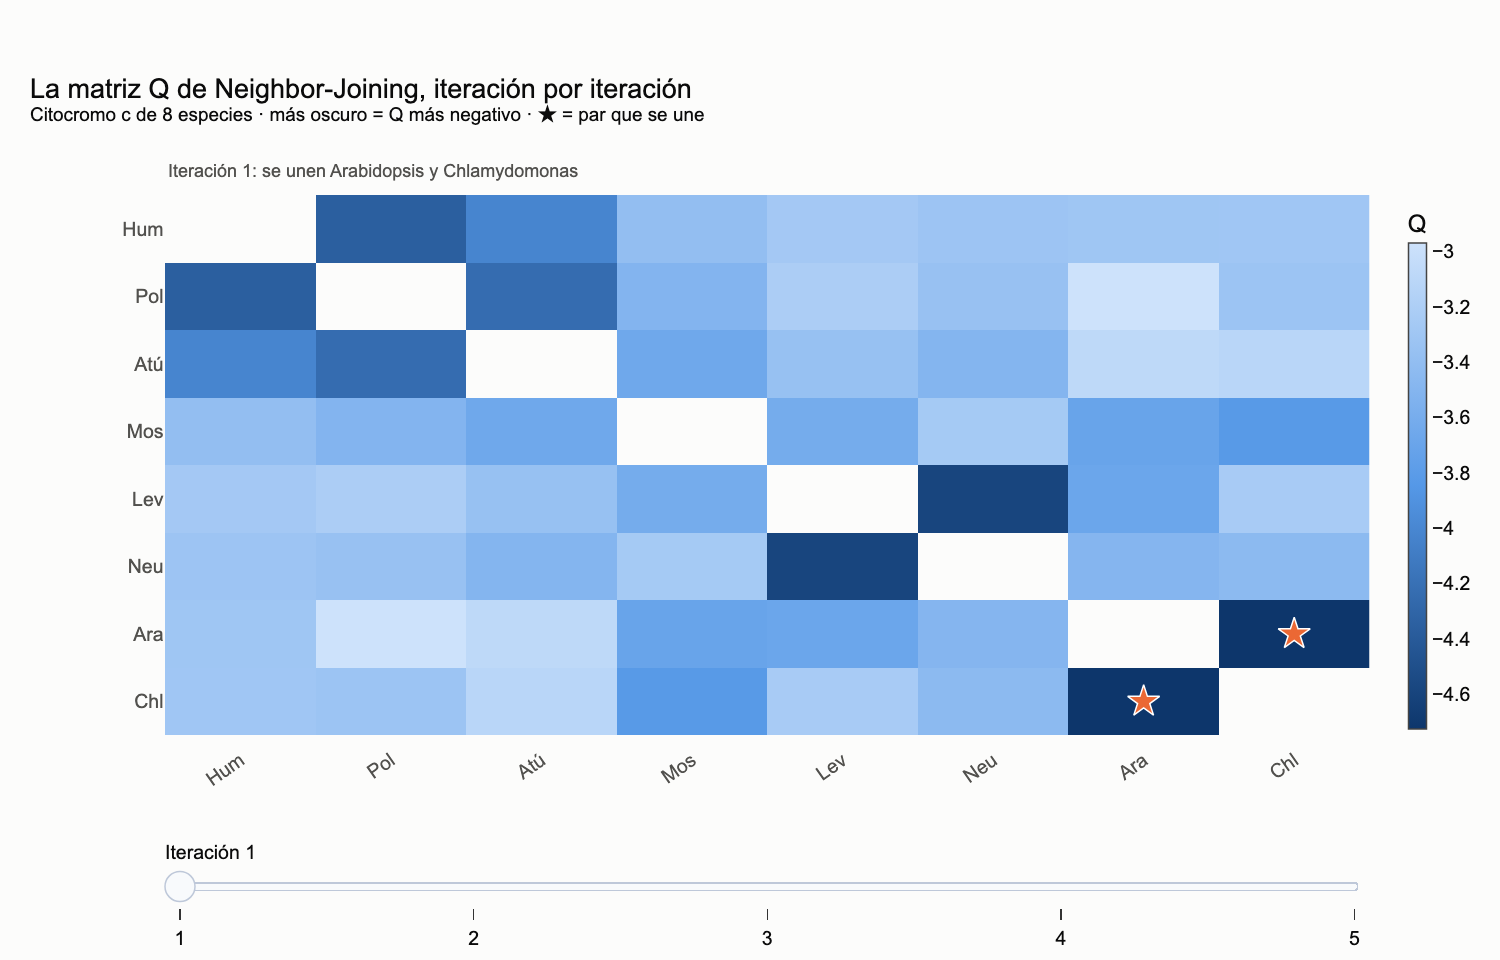

In [21]:
fig = go.Figure()
n_steps = len(steps8) - 1
for s, st in enumerate(steps8[:-1]):
    act, nodes = st["active"], st["nodes"]
    m, labels = len(act), [short(nd) for nd in st["nodes"]]
    Z = np.full((m, m), np.nan); custom = np.empty((m, m, 5), dtype=object)
    for a in range(m):
        for b in range(m):
            if a != b:
                i, j = act[a], act[b]
                Z[a, b] = st["Q"][(i, j) if (i, j) in st["Q"] else (j, i)]
                custom[a, b] = [", ".join(nodes[a].leaves()), ", ".join(nodes[b].leaves()),
                                st["d"][i, j], st["r"][i], st["r"][j]]
            else:
                custom[a, b] = ["", "", 0, 0, 0]
    fig.add_trace(go.Heatmap(
        z=Z, x=list(range(m)), y=list(range(m)), customdata=custom, visible=(s == 0),
        colorscale=[[0, ec.SEQ_BLUE[12]], [0.5, ec.SEQ_BLUE[5]], [1, ec.SEQ_BLUE[0]]],
        colorbar=dict(title="Q", thickness=12), hoverongaps=False,
        hovertemplate=(f"<b>n = {m}</b> nodos activos<br>i = %{{customdata[0]}}<br>j = %{{customdata[1]}}"
                       f"<br>d<sub>ij</sub> = %{{customdata[2]:.3f}} · r<sub>i</sub> = %{{customdata[3]:.3f}}"
                       f" · r<sub>j</sub> = %{{customdata[4]:.3f}}"
                       f"<br>Q = {m - 2}·d<sub>ij</sub> − r<sub>i</sub> − r<sub>j</sub> = <b>%{{z:.3f}}</b><extra></extra>")))
    ia, ib = act.index(st["i"]), act.index(st["j"])
    fig.add_trace(go.Scatter(x=[ib, ia], y=[ia, ib], mode="markers", visible=(s == 0), hoverinfo="skip",
                             marker=dict(symbol="star", size=16, color=ec.ORANGE, line=dict(color="white", width=1)),
                             name="mínimo de Q", showlegend=False))

def axis_update(s):
    labels = [short(nd) for nd in steps8[s]["nodes"]]
    ticks = dict(tickmode="array", tickvals=list(range(len(labels))), ticktext=labels)
    return {"xaxis": {**ticks, "tickangle": -35}, "yaxis": {**ticks, "autorange": "reversed"}}

slider_steps = []
for s in range(n_steps):
    vis = [False] * (2 * n_steps); vis[2 * s] = vis[2 * s + 1] = True
    st = steps8[s]
    title = (f"Iteración {s + 1}: se unen {', '.join(st['nodes'][st['active'].index(st['i'])].leaves())} y "
             f"{', '.join(st['nodes'][st['active'].index(st['j'])].leaves())}")
    slider_steps.append(dict(method="update", label=str(s + 1),
                             args=[{"visible": vis}, {**axis_update(s), "annotations": [dict(
                                 text=title, x=0, xref="paper", y=1.02, yref="paper", showarrow=False,
                                 xanchor="left", yanchor="bottom", font=dict(size=12, color=ec.INK_2))]}]))
fig.update_layout(
    title=dict(text="La matriz Q de Neighbor-Joining, iteración por iteración<br>"
                    "<sup>Citocromo c de 8 especies · más oscuro = Q más negativo · ★ = par que se une</sup>"),
    sliders=[dict(steps=slider_steps, active=0, currentvalue=dict(prefix="Iteración "), pad=dict(t=60))],
    height=640, width=760, margin=dict(t=130, l=110, r=40, b=60), plot_bgcolor=ec.SURFACE,
    **axis_update(0), annotations=slider_steps[0]["args"][1]["annotations"])
fig.update_xaxes(showgrid=False); fig.update_yaxes(showgrid=False)
fig.show()

✅ **Compruebe su comprensión.** En la iteración 1, ¿cuál es el par con la **menor distancia** $d_{ij}$? ¿Tiene también
el menor $Q$? Explique la diferencia usando $r_i$.

### 🧪 UPGMA frente a NJ en datos simulados

Con datos reales nunca conocemos el árbol verdadero. Con una **simulación**, sí. Generamos secuencias de ADN de 1 000
sitios que evolucionan a lo largo de un árbol conocido de seis especies bajo el modelo de Jukes-Cantor (Lección 5.1):
en una rama de longitud $t$, cada sitio cambia con probabilidad $p(t) = \tfrac34\,(1 - e^{-4t/3})$ a una de las otras
tres bases. El árbol verdadero es $(((A,B),(C,D)),(E,F))$ con reloj perfecto… **salvo** la rama de $B$, que evoluciona
$k$ veces más rápido. Después estimamos las distancias de Jukes-Cantor, $\hat d = -\tfrac34 \ln(1 - \tfrac43 \hat p)$, y
reconstruimos con los dos métodos.

🤔 **Antes de ejecutar, prediga:** ¿a partir de qué factor $k$ empezará UPGMA a equivocarse? ¿Y NJ?

In [22]:
rng = np.random.default_rng(52)
BASES = np.array(list("ACGT"))

def simulate_jc(tree, L, rng):
    """Evoluciona una secuencia aleatoria desde la raíz hasta las hojas bajo Jukes-Cantor."""
    seqs = {}
    def walk(nd, parent_seq):
        p = 0.75 * (1 - np.exp(-4 * nd.length / 3))              # probabilidad de cambio en esta rama
        s = parent_seq.copy()
        mut = rng.random(L) < p
        s[mut] = (s[mut] + rng.integers(1, 4, mut.sum())) % 4    # cambia a una de las otras 3 bases
        if nd.is_leaf():
            seqs[nd.name] = s
        for c in nd.children:
            walk(c, s)
    walk(tree, rng.integers(0, 4, L))
    return seqs

def jc_matrix(seqs, names):
    n = len(names); D = np.zeros((n, n))
    for i, j in itertools.combinations(range(n), 2):
        p = min(np.mean(seqs[names[i]] != seqs[names[j]]), 0.7499)     # evita log de un número ≤ 0
        D[i, j] = D[j, i] = -0.75 * np.log(1 - 4 * p / 3)
    return D

SIX = list("ABCDEF")
def true_six(k):
    return parse_newick(f"(((A:0.08,B:{0.08 * k:g}):0.06,(C:0.08,D:0.08):0.06):0.06,(E:0.14,F:0.14):0.06);")

T5 = true_six(5)
sim = simulate_jc(T5, 1000, rng)
print("Primeros 60 sitios simulados:")
for name in SIX:
    print(f"  {name}  {''.join(BASES[sim[name][:60]])}")
D_sim = jc_matrix(sim, SIX)
tree_u_sim, _ = upgma(D_sim, SIX)
tree_nj_sim, _ = neighbor_joining(D_sim, SIX)
print("\nRobinson-Foulds frente al árbol verdadero · UPGMA:", robinson_foulds(tree_u_sim, T5),
      "· NJ:", robinson_foulds(tree_nj_sim, T5))

Primeros 60 sitios simulados:
  A  AGCGCGTCCGAAACACATCTGTAAAAAGGTGACCACGTCAACGTACATAGAATTACAGCC
  B  AGCTATTCCGAAACTGCATTGTGCAAGAGTGCTTTCTTCATGTTAGATAGAGATACAGTC
  C  AGGGCGTACCAATCAACATCGTACTAAAGCGACCACGACGCCTTAGTTAGACTTACAGCC
  D  AGGGCGTACGACTTAACATGGTACGAAAGCGACCACGACGACTCACTGAGAATTACGGCT
  E  TCCGCGTAAGATTTAACATCGTATAAAATTGACCACGTGAACCTACATCGAATTACCGCA
  F  TGCACGTACAATTCAACATCGTACAAGAGCGACCACGGGAACCTACATCGGATTACCGTC

Robinson-Foulds frente al árbol verdadero · UPGMA: 2 · NJ: 0


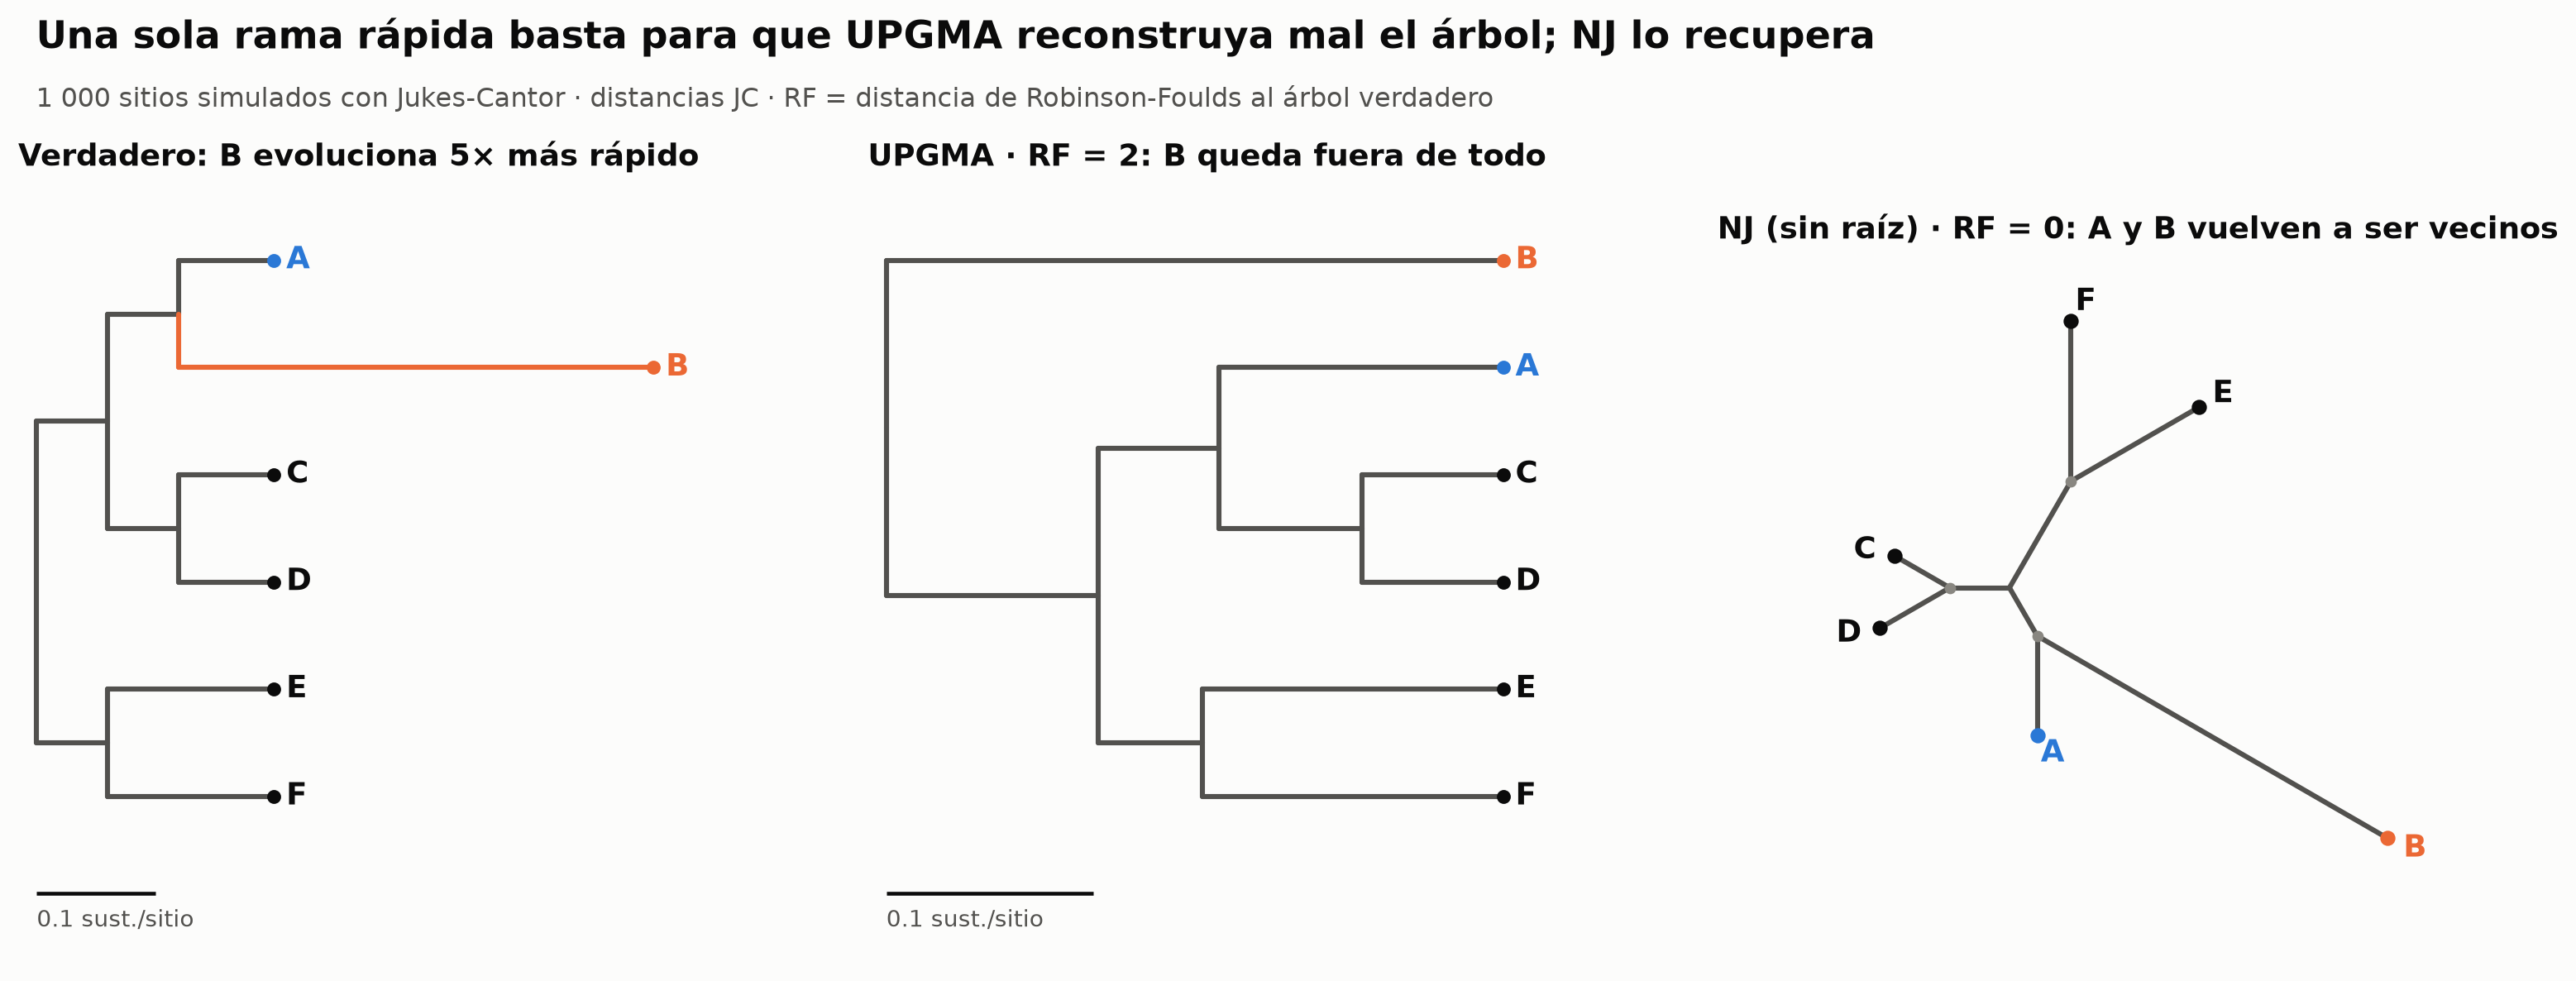

In [23]:
six_col = {"A": ec.BLUE, "B": ec.ORANGE}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), width_ratios=[1, 1, 1])
b_leaf = next(nd for nd in T5.nodes() if nd.name == "B")
draw_tree(axes[0], T5, label_colors=six_col, fs=12, edge_colors={id(b_leaf): ec.ORANGE}, scale=0.1,
          xlabel="sust./sitio")
axes[0].set_title("Verdadero: B evoluciona 5× más rápido", loc="left", fontsize=12)
draw_tree(axes[1], tree_u_sim, label_colors=six_col, fs=12, scale=0.1, xlabel="sust./sitio")
axes[1].set_title(f"UPGMA · RF = {robinson_foulds(tree_u_sim, T5)}: B queda fuera de todo", loc="left", fontsize=12)
draw_unrooted(axes[2], tree_nj_sim, label_colors=six_col, fs=12)
axes[2].set_title(f"NJ (sin raíz) · RF = {robinson_foulds(tree_nj_sim, T5)}: A y B vuelven a ser vecinos",
                  loc="left", fontsize=12)
ec.fig_title(fig, "Una sola rama rápida basta para que UPGMA reconstruya mal el árbol; NJ lo recupera",
             "1 000 sitios simulados con Jukes-Cantor · distancias JC · RF = distancia de Robinson-Foulds al árbol verdadero")
plt.show()

Un solo experimento puede ser suerte. Repitamos la simulación **100 veces** para cada factor de aceleración $k$ y con
dos longitudes de secuencia, y midamos qué fracción de las veces cada método recupera la topología verdadera.

3,000 simulaciones en 0.7 s


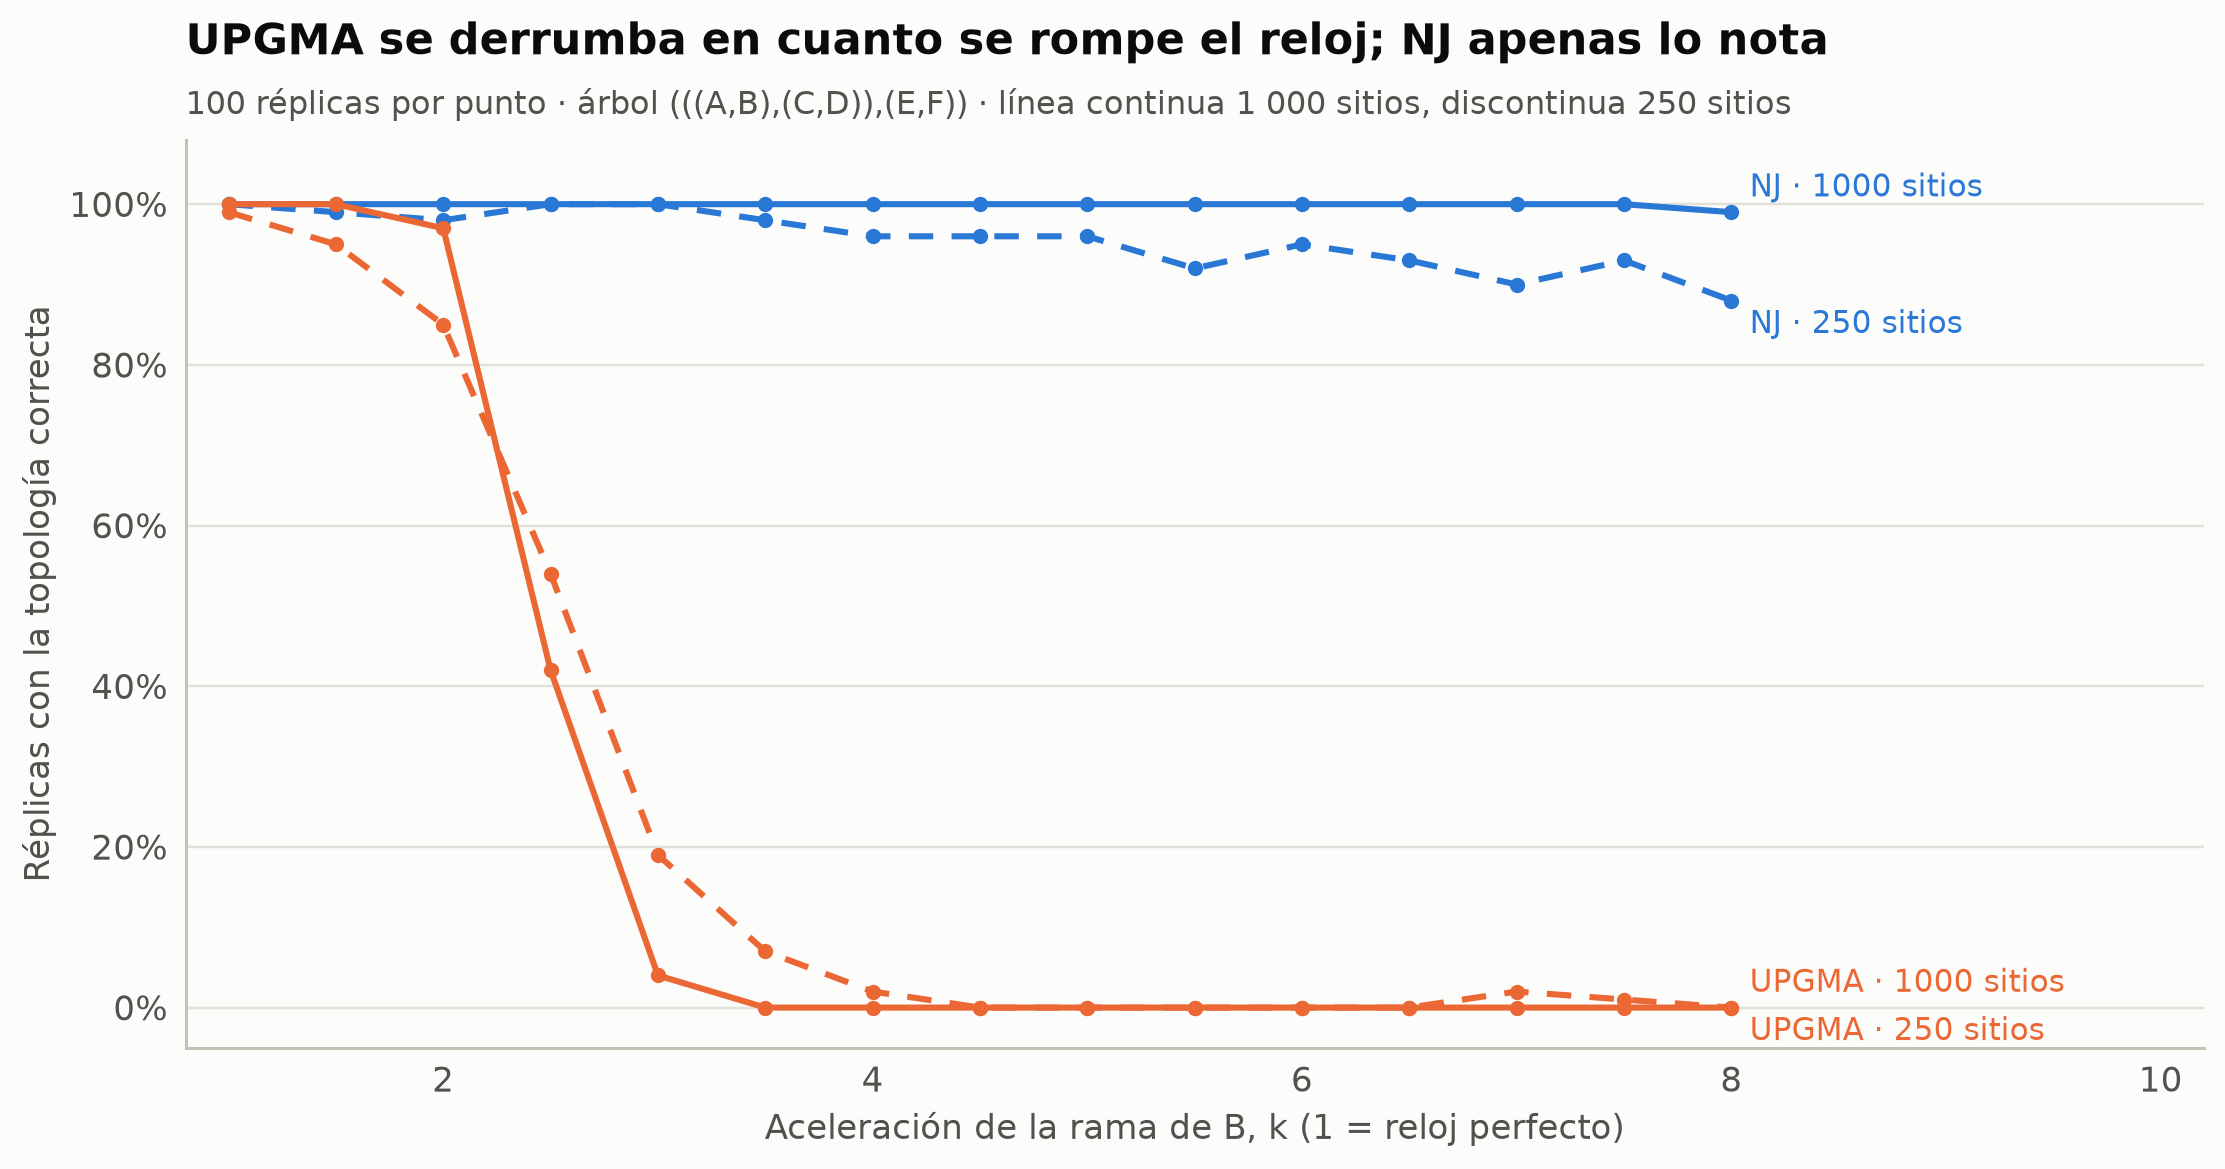

In [24]:
t0 = time.perf_counter()
ks = np.arange(1, 8.5, 0.5)
results = []
for L in (1000, 250):
    for k in ks:
        T = true_six(k)
        hits = np.zeros(2)
        for _ in range(100):
            Dk = jc_matrix(simulate_jc(T, L, rng), SIX)
            hits += [robinson_foulds(upgma(Dk, SIX)[0], T) == 0, robinson_foulds(neighbor_joining(Dk, SIX)[0], T) == 0]
        results.append(dict(L=L, k=k, UPGMA=hits[0] / 100, NJ=hits[1] / 100))
sweep = pd.DataFrame(results)
print(f"{len(sweep) * 100:,} simulaciones en {time.perf_counter() - t0:.1f} s")

fig, ax = plt.subplots(figsize=(10, 5.2))
for method, col in [("NJ", ec.BLUE), ("UPGMA", ec.ORANGE)]:
    for L, ls in [(1000, "-"), (250, (0, (4, 3)))]:
        sub = sweep[sweep.L == L]
        ax.plot(sub.k, sub[method], color=col, ls=ls, marker="o", ms=4)
        ec.label_end(ax, sub.k.iloc[-1], sub[method].iloc[-1] + (0.03 if L == 1000 else -0.03),
                     f"{method} · {L} sitios", color=col)
ax.set_xlim(0.8, 10.2); ax.set_ylim(-0.05, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Aceleración de la rama de B, k (1 = reloj perfecto)")
ax.set_ylabel("Réplicas con la topología correcta")
ec.title(ax, "UPGMA se derrumba en cuanto se rompe el reloj; NJ apenas lo nota",
         "100 réplicas por punto · árbol (((A,B),(C,D)),(E,F)) · línea continua 1 000 sitios, discontinua 250 sitios")
plt.show()

> 🔎 **Qué observamos.** Con reloj perfecto ($k = 1$) los dos métodos aciertan casi siempre. En cuanto la rama de $B$
> es unas 2–3 veces más rápida, UPGMA cae en picada hasta **0 %**: ya no es un problema de ruido sino un **sesgo
> sistemático** (más datos no lo arreglan: la curva de 1 000 sitios cae igual). NJ se mantiene cerca del 100 % con
> 1 000 sitios; con sólo 250 sitios comete algunos errores por **ruido de muestreo** (las distancias estimadas se
> apartan de la aditividad), pero no por el reloj. Por eso UPGMA hoy casi sólo se usa para árboles guía o
> agrupamientos (Lección 4.1), no para inferir filogenias.

## 8. Verificación contra Biopython y SciPy

Programar un algoritmo desde cero sirve para entenderlo; **verificarlo** contra una implementación establecida sirve
para confiar en él. Biopython trae ambos métodos en `Bio.Phylo.TreeConstruction.DistanceTreeConstructor`. Recibe una
`DistanceMatrix` en forma **triangular inferior** (cada fila incluye la diagonal) y devuelve un árbol de `Bio.Phylo`,
que convertimos a Newick y leemos con nuestro propio lector para comparar.

Para comparar dos árboles **con sus longitudes** usamos dos criterios: la distancia de Robinson-Foulds (topología)
y la matriz **patrística** (si las distancias por el árbol entre todas las hojas coinciden, los árboles son el mismo
con las mismas ramas).

In [25]:
def bio_distance_matrix(D, names):
    """Matriz numpy → DistanceMatrix de Biopython (triangular inferior, con diagonal)."""
    return DistanceMatrix(list(names), [[float(D[i][j]) for j in range(i + 1)] for i in range(len(names))])

def from_bio(bio_tree):
    """Árbol de Bio.Phylo → nuestro Node (a través de Newick)."""
    return parse_newick(bio_tree.format("newick"))

constructor = DistanceTreeConstructor()
rows = []
for label, D, names in [("aditiva (sección 7)", D_add, TAXA5), ("UPGMA a mano (sección 5)", D_upgma, TAXA5),
                        ("citocromo c (14)", D_cyt, cyt_names)]:
    ours, _ = neighbor_joining(D, names)
    bio = from_bio(constructor.nj(bio_distance_matrix(D, names)))
    rows.append(dict(matriz=label, método="NJ", RF=robinson_foulds(ours, bio),
                     max_dif_patristica=np.abs(patristic(ours, names) - patristic(bio, names)).max()))
    ours_u, _ = upgma(D, names)
    bio_u = from_bio(constructor.upgma(bio_distance_matrix(D, names)))
    rows.append(dict(matriz=label, método="UPGMA", RF=robinson_foulds(ours_u, bio_u),
                     max_dif_patristica=np.abs(patristic(ours_u, names) - patristic(bio_u, names)).max()))
pd.DataFrame(rows)

,matriz,método,RF,max_dif_patristica
0,aditiva (sección 7),NJ,0,0.000000e+00
1,aditiva (sección 7),UPGMA,0,0.000000e+00
2,UPGMA a mano (sección 5),NJ,0,3.333334e-08
3,UPGMA a mano (sección 5),UPGMA,0,2.500000e-01
4,citocromo c (14),NJ,0,8.897601e-09
5,citocromo c (14),UPGMA,0,4.623078e-02


> 🔎 **Qué observamos.** Nuestro NJ coincide con el de Biopython **exactamente**, en topología y en longitudes (las
> diferencias son del orden del redondeo). Pero con UPGMA hay una sorpresa: en la matriz aditiva todo coincide, pero en
> la del ejemplo a mano de la sección 5 y en la del citocromo *c* las topologías coinciden (RF = 0) y aun así **las
> longitudes difieren**. ¿Quién tiene razón?

Revisemos el ejemplo a mano de la sección 5: en la fusión 3 calculamos $d(ABC, DE) = (2 \times 16.5 + 15)/3 = 16$. Si
se promedian los dos grupos **sin ponderar por su tamaño** se obtiene $(16.5 + 15)/2 = 15.75$, y la raíz quedaría a
$7.875$ en vez de $8$. Eso es **WPGMA**. Pongamos a prueba la hipótesis de que la función `upgma` de Biopython (versión
instalada) en realidad promedia sin ponderar, y usemos SciPy como tercer árbitro: `linkage(method="average")` es UPGMA
y `linkage(method="weighted")` es WPGMA.

In [26]:
from scipy.cluster.hierarchy import cophenet
print("Biopython", Bio.__version__)
bio_u5 = from_bio(constructor.upgma(bio_distance_matrix(D_upgma, TAXA5)))
ours_upgma, _ = upgma(D_upgma, TAXA5)
ours_wpgma, _ = upgma(D_upgma, TAXA5, weighted=True)
print("Biopython 'upgma':", to_newick(bio_u5))
print("Nuestro UPGMA    :", to_newick(ours_upgma))
print("Nuestro WPGMA    :", to_newick(ours_wpgma))

checks = []
for label, D, names in [("5 taxones (sección 5)", D_upgma, TAXA5), ("citocromo c (14)", D_cyt, cyt_names)]:
    vec = squareform(D, checks=False)
    coph_avg = squareform(cophenet(linkage(vec, "average")))      # distancia de fusión = 2 × altura
    coph_wei = squareform(cophenet(linkage(vec, "weighted")))
    P_u = patristic(upgma(D, names)[0], names); P_w = patristic(upgma(D, names, weighted=True)[0], names)
    P_bio = patristic(from_bio(constructor.upgma(bio_distance_matrix(D, names))), names)
    checks.append({"matriz": label,
                   "UPGMA nuestro = SciPy average": np.allclose(P_u, coph_avg),
                   "WPGMA nuestro = SciPy weighted": np.allclose(P_w, coph_wei),
                   "Biopython = UPGMA": np.allclose(P_bio, P_u, atol=1e-6),
                   "Biopython = WPGMA": np.allclose(P_bio, P_w, atol=1e-6)})
pd.DataFrame(checks)

Biopython 1.88
Biopython 'upgma': ((E:3,D:3)Inner2:4.875,(C:5.5,(B:2,A:2)Inner1:3.5)Inner3:2.375)Inner4;
Nuestro UPGMA    : ((D:3,E:3):5,(C:5.5,(A:2,B:2):3.5):2.5);
Nuestro WPGMA    : ((D:3,E:3):4.875,(C:5.5,(A:2,B:2):3.5):2.375);


,matriz,UPGMA nuestro = SciPy average,WPGMA nuestro = SciPy weighted,Biopython = UPGMA,Biopython = WPGMA
0,5 taxones (sección 5),True,True,False,True
1,citocromo c (14),True,True,False,True


> 🔎 **Qué observamos.** Nuestro UPGMA coincide con `linkage(method="average")` de SciPy, y nuestro WPGMA con
> `linkage(method="weighted")`. El método que Biopython llama `upgma` reproduce el **WPGMA** (en la versión instalada
> aquí; compruébelo en la suya): al fusionar promedia las distancias de los dos grupos sin ponderar por su tamaño. En
> datos casi ultramétricos la diferencia es pequeña, y la topología suele coincidir, pero las alturas no.
>
> **Moraleja:** el nombre de una función no garantiza el algoritmo. Cuando la exactitud importa, verifique con un
> ejemplo pequeño resuelto a mano, exactamente como acabamos de hacer.

✅ **Compruebe su comprensión.** ¿En qué caso UPGMA y WPGMA dan **siempre** el mismo resultado? (Pista: piense en qué
pasa si todos los grupos que se fusionan tienen el mismo tamaño, o si la matriz es ultramétrica.)

## 9. ¿Dónde está la raíz? Grupo externo y punto medio

NJ entrega un árbol **sin raíz**: sabe quién está conectado con quién, pero no en qué dirección corrió el tiempo. Y
sin raíz no podemos hablar de ancestros ni de clados. Hay dos formas habituales de ponerla:

**1. Grupo externo** (*outgroup*). Se incluye en el análisis una especie (o grupo) que, por información
**independiente** (fósiles, morfología, otros genes), sabemos que se separó **antes** que todas las demás (el grupo
interno, *ingroup*). La raíz se coloca en la rama que une al grupo externo con el resto. Es como ubicar el origen de
una familia extendida preguntando a un primo lejano: lo que él comparte con todos marca dónde empezó la historia. Es el
método preferido, pero exige que el grupo externo sea realmente externo… y que no esté tan lejos que su rama larga
distorsione el árbol.

**2. Punto medio** (*midpoint*). Se busca el par de hojas **más distantes** en el árbol (camino más largo) y se pone
la raíz justo a la mitad de ese camino:

$$
\text{raíz} \;=\; \text{punto del camino entre } a^* \text{ y } b^* \text{ a distancia } \tfrac12\, d_{\text{árbol}}(a^*, b^*)
\text{ de ambos},\qquad (a^*, b^*) = \arg\max_{a,b}\; d_{\text{árbol}}(a, b)
$$

No necesita información externa, pero **supone que las tasas son aproximadamente iguales** (un reloj aproximado): si
un linaje es muy rápido, su rama larga "tira" del punto medio hacia él.

| Símbolo | Significado |
|---|---|
| $d_{\text{árbol}}(a,b)$ | distancia patrística: suma de ramas del camino entre $a$ y $b$ en el árbol |
| $a^*, b^*$ | el par de hojas más alejadas del árbol |

Ambos métodos hacen lo mismo en el fondo: **elegir una rama** del árbol sin raíz y **partirla** en dos con un nodo
nuevo que será la raíz. Recuerde la sección 3: hay $2n-3$ ramas donde poner la raíz, y cada elección da un árbol con
raíz distinto.

In [27]:
def root_on_edge(adj, label, u, v, frac):
    """Parte la rama u–v con un nodo raíz a una fracción `frac` de su longitud medida desde u."""
    adj = {k: dict(x) for k, x in adj.items()}; label = dict(label)
    L = adj[u].pop(v); adj[v].pop(u)
    adj["root"] = {u: frac * L, v: (1 - frac) * L}
    adj[u]["root"], adj[v]["root"], label["root"] = frac * L, (1 - frac) * L, None
    def build(k, parent, length):
        nd = Node(label[k], length=length)
        nd.children = [build(c, k, l) for c, l in adj[k].items() if c != parent]
        return nd
    return build("root", None, 0.0)

def midpoint_root(tree):
    adj, label = to_graph(tree)
    leaves = [k for k in adj if label[k] is not None]
    D_max, a, b = max(((graph_distances(adj, a)[0][b], a, b) for a, b in itertools.combinations(leaves, 2)),
                      key=lambda t: t[0])
    dist, prev = graph_distances(adj, a)
    x = b
    while dist[prev[x]] > D_max / 2:            # subir desde b hasta la rama que contiene el punto medio
        x = prev[x]
    p = prev[x]
    return root_on_edge(adj, label, p, x, (D_max / 2 - dist[p]) / adj[p][x])

def outgroup_root(tree, outgroup):
    adj, label = to_graph(tree)
    target = frozenset(outgroup)
    def side(u, v):                               # hojas que quedan del lado de v al cortar u–v
        out, stack, seen = set(), [v], {u, v}
        while stack:
            x = stack.pop()
            if label[x]:
                out.add(label[x])
            for y in adj[x]:
                if y not in seen:
                    seen.add(y); stack.append(y)
        return frozenset(out)
    for u in adj:
        for v in adj[u]:
            if side(u, v) == target:
                return root_on_edge(adj, label, u, v, 0.5)
    raise ValueError(f"el grupo externo {sorted(outgroup)} no forma un clado en este árbol")

def clusters(tree):
    """Clados de un árbol con raíz (conjuntos de hojas de cada nodo interno, sin la raíz)."""
    return {frozenset(nd.leaves()) for nd in tree.nodes() if not nd.is_leaf() and nd is not tree}

rooted_out = outgroup_root(tree_nj_sim, ["E", "F"])
rooted_mid = midpoint_root(tree_nj_sim)
print("Verdadero       :", to_newick(T5, 3))
print("Grupo externo   :", to_newick(rooted_out, 3), "· ¿mismos clados?", clusters(rooted_out) == clusters(T5))
print("Punto medio     :", to_newick(rooted_mid, 3), "· ¿mismos clados?", clusters(rooted_mid) == clusters(T5))

Verdadero       : (((A:0.08,B:0.4):0.06,(C:0.08,D:0.08):0.06):0.06,(E:0.14,F:0.14):0.06);
Grupo externo   : (((C:0.061,D:0.076):0.056,(A:0.093,B:0.382):0.052):0.058,(E:0.139,F:0.151):0.058); · ¿mismos clados? True
Punto medio     : ((((E:0.139,F:0.151):0.116,(C:0.061,D:0.076):0.056):0.052,A:0.093):0.031,B:0.351); · ¿mismos clados? False


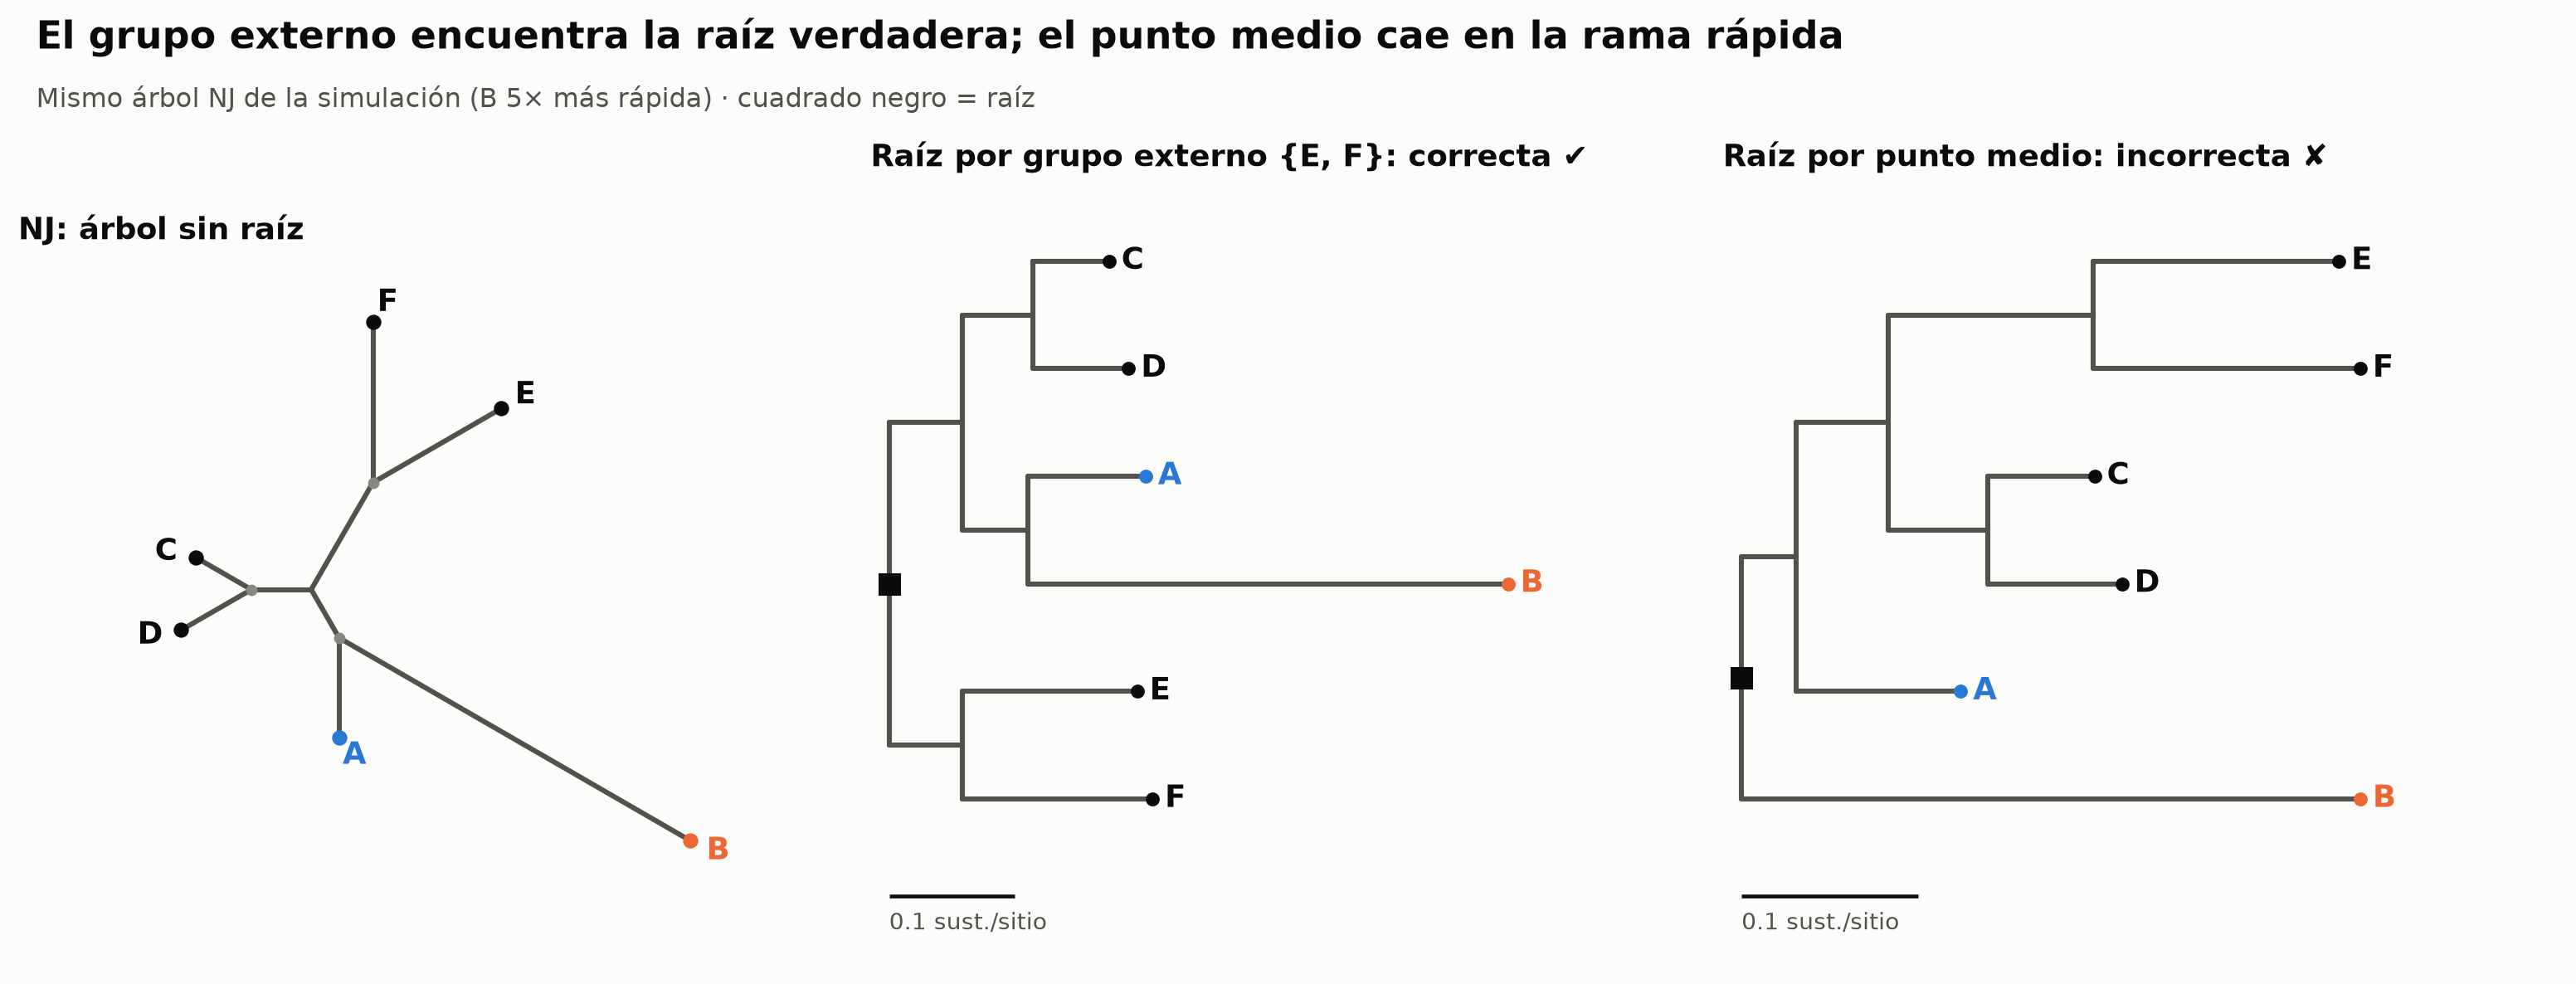

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
draw_unrooted(axes[0], tree_nj_sim, label_colors=six_col, fs=12)
axes[0].set_title("NJ: árbol sin raíz", loc="left", fontsize=12)
for ax, t, lab in [(axes[1], rooted_out, "grupo externo {E, F}"), (axes[2], rooted_mid, "punto medio")]:
    ok = clusters(t) == clusters(T5)
    draw_tree(ax, t, label_colors=six_col, fs=12, scale=0.1, xlabel="sust./sitio")
    ax.plot(0, rooted_layout(t)[id(t)][1], "s", color=ec.INK, ms=8)
    ax.set_title(f"Raíz por {lab}: {'correcta ✔' if ok else 'incorrecta ✘'}", loc="left", fontsize=12)
ec.fig_title(fig, "El grupo externo encuentra la raíz verdadera; el punto medio cae en la rama rápida",
             "Mismo árbol NJ de la simulación (B 5× más rápida) · cuadrado negro = raíz")
plt.show()

> 🔎 **Qué observamos.** Con el grupo externo $\{E, F\}$ la raíz queda donde debe y los clados coinciden con el árbol
> verdadero. El punto medio, en cambio, cae **sobre la rama larga de $B$**: el par más distante del árbol incluye a
> $B$, y la mitad de ese camino queda dentro de su rama. El resultado es un árbol con raíz que dice, falsamente, que $B$
> es el linaje más antiguo. El punto medio funciona bien cuando las tasas son parecidas; con una rama muy rápida, falla
> por la misma razón que UPGMA.

✅ **Compruebe su comprensión.** Si eligiera como grupo externo $\{C, D\}$, ¿se podría enraizar este árbol? ¿Qué
diría el árbol resultante sobre la relación entre $\{A,B\}$ y $\{E,F\}$? ¿Por qué elegir mal el grupo externo produce
un árbol con raíz equivocado aunque la topología sin raíz sea correcta?

## 10. ¿Qué tan distintos son dos árboles? La distancia de Robinson-Foulds

Ya vimos (sección 2) que comparar dibujos es engañoso. La forma estándar de comparar **topologías sin raíz** es la
distancia de **Robinson-Foulds** (1981). Cada rama **interna** de un árbol sin raíz, si se corta, divide las hojas en
dos grupos: una **bipartición** (o *split*), que se escribe $X \mid Y$. Las ramas que llevan a una hoja dan
biparticiones triviales ($\{A\} \mid$ resto) que todos los árboles comparten, así que no cuentan. Un árbol binario sin
raíz de $n$ hojas tiene exactamente $n-3$ biparticiones no triviales, y **el conjunto de biparticiones determina la
topología**.

$$
\operatorname{RF}(T_1, T_2) \;=\; \big|\,\Sigma(T_1) \setminus \Sigma(T_2)\,\big| \;+\; \big|\,\Sigma(T_2) \setminus \Sigma(T_1)\,\big|,
\qquad
\operatorname{RF}_{\text{norm}} \;=\; \frac{\operatorname{RF}}{2\,(n-3)} \in [0, 1]
$$

| Símbolo | Significado |
|---|---|
| $\Sigma(T)$ | conjunto de biparticiones no triviales del árbol $T$ |
| $\setminus$ | diferencia de conjuntos: las biparticiones de uno que faltan en el otro |
| $n-3$ | número de biparticiones no triviales de un árbol binario de $n$ hojas |
| $2(n-3)$ | el máximo posible de RF: ninguna bipartición compartida |

### Ejemplo a mano

Árbol A de la sección 2, `(((A,B),C),(D,E))`: sus ramas internas separan $\{A,B\} \mid \{C,D,E\}$ y
$\{D,E\} \mid \{A,B,C\}$. Árbol D, `(((A,C),B),(D,E))`: separa $\{A,C\} \mid \{B,D,E\}$ y $\{D,E\} \mid \{A,B,C\}$.
Comparten una ($\{D,E\} \mid \{A,B,C\}$) y cada uno tiene una propia: $\operatorname{RF} = 1 + 1 = 2$. Con $n = 5$, el
máximo es $2 \times 2 = 4$, así que $\operatorname{RF}_{\text{norm}} = 0.5$.

Nuestra función `splits` (sección 6) representa cada bipartición por el lado que **no** contiene a la primera hoja en
orden alfabético, para que $X \mid Y$ y $Y \mid X$ se guarden igual.

In [29]:
trees_var = {k.split(" · ")[0]: parse_newick(v) for k, v in variants.items()}
for k, t in trees_var.items():
    print(k, "→", sorted(sorted(s) for s in splits(t)))
rf = pd.DataFrame([[robinson_foulds(a, b) for b in trees_var.values()] for a in trees_var.values()],
                  index=trees_var, columns=trees_var)
print("\nDistancia de Robinson-Foulds entre los cuatro árboles de la sección 2:")
rf

A → [['C', 'D', 'E'], ['D', 'E']]
B → [['C', 'D', 'E'], ['D', 'E']]
C → [['C', 'D', 'E'], ['D', 'E']]
D → [['B', 'D', 'E'], ['D', 'E']]

Distancia de Robinson-Foulds entre los cuatro árboles de la sección 2:


,A,B,C,D
A,0,0,0,2
B,0,0,0,2
C,0,0,0,2
D,2,2,2,0


> 🔎 **Qué observamos.** A, B y C están a distancia 0 entre sí (misma topología, aunque los dibujos y longitudes
> difieran) y los tres están a distancia 2 de D, tal como calculamos a mano. RF es fácil de calcular e interpretar, pero
> tiene un defecto conocido: es **muy sensible**. Mover una sola hoja de un extremo a otro del árbol puede romper casi
> todas las biparticiones y dar el valor máximo, aunque el resto del árbol esté perfecto. Por eso a veces se complementa
> con otras medidas (por ejemplo, las que también comparan longitudes de rama).

✅ **Compruebe su comprensión.** ¿Cuál es el valor máximo de RF entre dos árboles de las 14 especies de citocromo *c*?

## 11. 🧪 Aplicación real: el árbol del citocromo *c*

En 1967 Walter Fitch y Emanuel Margoliash publicaron en *Science* uno de los primeros árboles filogenéticos construidos
con **secuencias de proteínas**, precisamente con el citocromo *c*, y mostraron que se parecía notablemente al árbol de
la taxonomía clásica. Repitamos la idea con nuestras 14 especies y los dos métodos de la clase.

### ¿Son las distancias reales ultramétricas o aditivas?

Antes de construir nada, midamos (sección 4) cuánto se apartan las distancias de Poisson del citocromo *c* de cada
condición. Si hubiera un reloj perfecto, los tríos darían 0; si fueran perfectamente aditivas, los cuartetos darían 0.

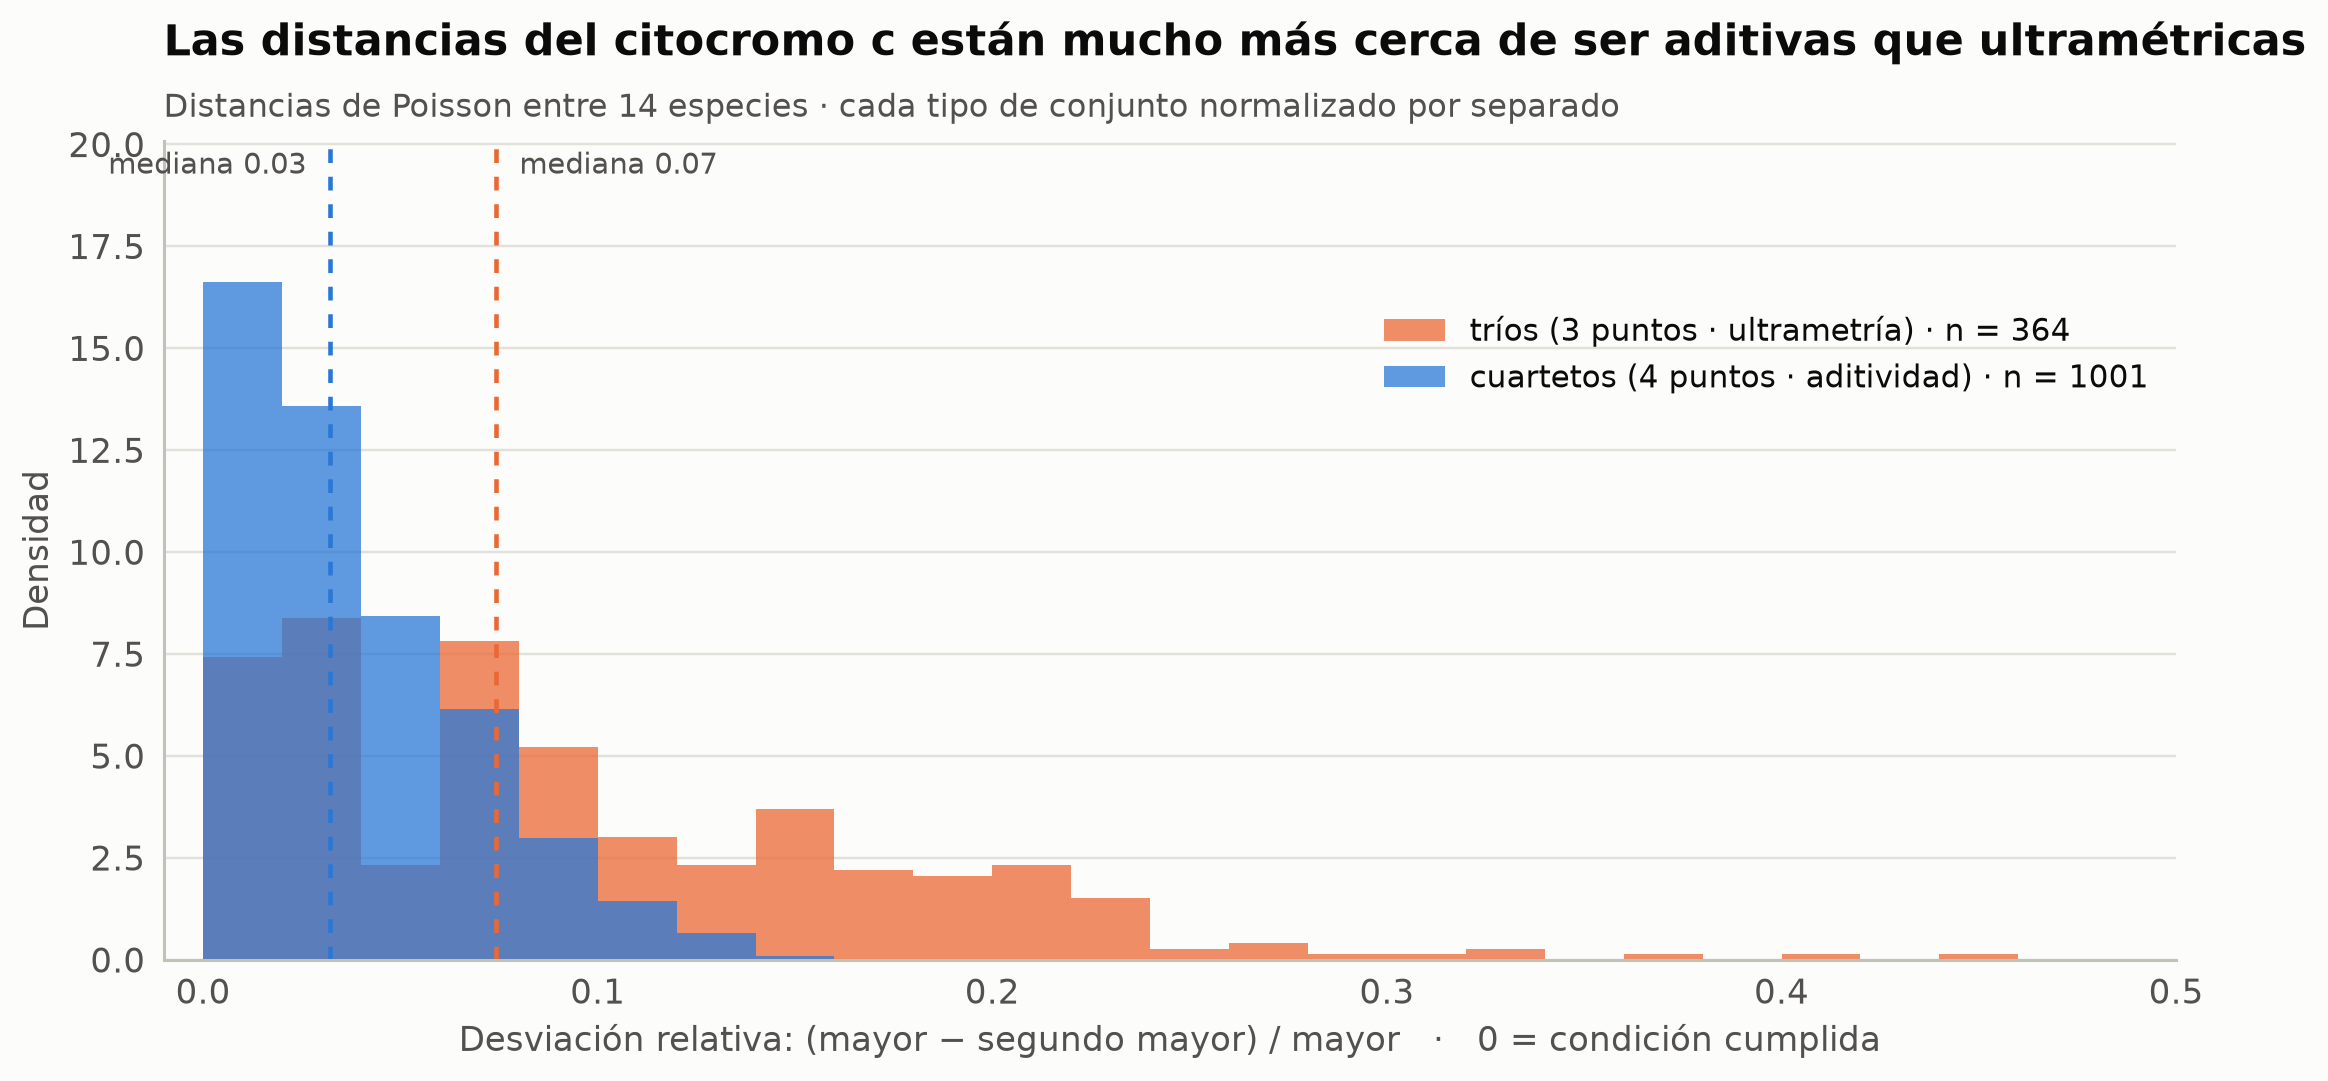

In [30]:
dev3, dev4 = three_point_deviation(D_cyt), four_point_deviation(D_cyt)
fig, ax = plt.subplots(figsize=(10, 4.8))
bins = np.linspace(0, 0.5, 26)
ax.hist(dev3, bins=bins, color=ec.ORANGE, alpha=0.75, label=f"tríos (3 puntos · ultrametría) · n = {len(dev3)}", density=True)
ax.hist(dev4, bins=bins, color=ec.BLUE, alpha=0.75, label=f"cuartetos (4 puntos · aditividad) · n = {len(dev4)}", density=True)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
for v, col, side in [(np.median(dev3), ec.ORANGE, 1), (np.median(dev4), ec.BLUE, -1)]:
    ax.axvline(v, color=col, lw=1.5, ls=(0, (3, 3)))
    ax.text(v + side * 0.006, ax.get_ylim()[1] * 0.96, f"mediana {v:.2f}", color=ec.INK_2, fontsize=9.5,
            ha="left" if side > 0 else "right")
ax.set_xlim(-0.01, 0.5)
ax.set_xlabel("Desviación relativa: (mayor − segundo mayor) / mayor   ·   0 = condición cumplida")
ax.set_ylabel("Densidad")
ax.legend(loc="upper right", bbox_to_anchor=(1, 0.82))
ec.title(ax, "Las distancias del citocromo c están mucho más cerca de ser aditivas que ultramétricas",
         "Distancias de Poisson entre 14 especies · cada tipo de conjunto normalizado por separado")
plt.show()

> 🔎 **Qué observamos.** Las desviaciones de los cuartetos (azul) se amontonan cerca de 0: las distancias son **casi
> aditivas**, que es lo único que NJ necesita. Las de los tríos (naranja) son mucho mayores: **no hay reloj**. Esto ya
> anticipa que UPGMA tendrá problemas con estos datos.

### Los dos árboles

Construimos UPGMA y NJ con las distancias de Poisson. Al árbol NJ le ponemos raíz con el **grupo externo** de las
plantas y el alga verde: sabemos por muchas otras evidencias que animales y hongos (los **opistocontos**) están más
emparentados entre sí que con las plantas. Como referencia usamos la **taxonomía aceptada** (simplificada) de estas
especies, escrita a mano en Newick.

In [31]:
def ladderize(tree):
    """Rota los nodos para que el hijo con menos hojas vaya primero (no cambia el árbol, sólo el dibujo)."""
    for nd in tree.nodes():
        nd.children.sort(key=lambda c: len(c.leaves()))
    return tree

tree_u_cyt, _ = upgma(D_cyt, cyt_names)
tree_nj_cyt, steps_nj_cyt = neighbor_joining(D_cyt, cyt_names)
PLANTS = ["Arabidopsis", "Arroz", "Chlamydomonas"]
tree_nj_rooted = ladderize(outgroup_root(tree_nj_cyt, PLANTS))
ladderize(tree_u_cyt)
reference = parse_newick("((((((((Humano,Ratón),Caballo),Pollo),Rana),(Pez cebra,Atún)),(Mosca,Gusano)),"
                         "(Levadura,Neurospora)),((Arabidopsis,Arroz),Chlamydomonas));")
n_max = 2 * (len(cyt_names) - 3)
summary = pd.DataFrame([
    {"comparación": "UPGMA vs NJ", "RF": robinson_foulds(tree_u_cyt, tree_nj_cyt)},
    {"comparación": "UPGMA vs taxonomía", "RF": robinson_foulds(tree_u_cyt, reference)},
    {"comparación": "NJ vs taxonomía", "RF": robinson_foulds(tree_nj_cyt, reference)},
])
summary["RF normalizada"] = (summary.RF / n_max).round(2)
print("Biparticiones de la taxonomía que NJ NO recupera:")
for s in splits(reference) - splits(tree_nj_cyt):
    print("  ", sorted(s), "|", sorted(set(cyt_names) - s))
summary

Biparticiones de la taxonomía que NJ NO recupera:
   ['Humano', 'Ratón'] | ['Arabidopsis', 'Arroz', 'Atún', 'Caballo', 'Chlamydomonas', 'Gusano', 'Levadura', 'Mosca', 'Neurospora', 'Pez cebra', 'Pollo', 'Rana']
   ['Gusano', 'Mosca'] | ['Arabidopsis', 'Arroz', 'Atún', 'Caballo', 'Chlamydomonas', 'Humano', 'Levadura', 'Neurospora', 'Pez cebra', 'Pollo', 'Rana', 'Ratón']
   ['Atún', 'Caballo', 'Gusano', 'Humano', 'Mosca', 'Pez cebra', 'Pollo', 'Rana', 'Ratón'] | ['Arabidopsis', 'Arroz', 'Chlamydomonas', 'Levadura', 'Neurospora']


,comparación,RF,RF normalizada
0,UPGMA vs NJ,4,0.18
1,UPGMA vs taxonomía,8,0.36
2,NJ vs taxonomía,6,0.27


Un **tanglegrama** pone dos árboles frente a frente y une con líneas las hojas iguales: si los árboles coinciden, las
líneas son horizontales; los cruces señalan las diferencias.

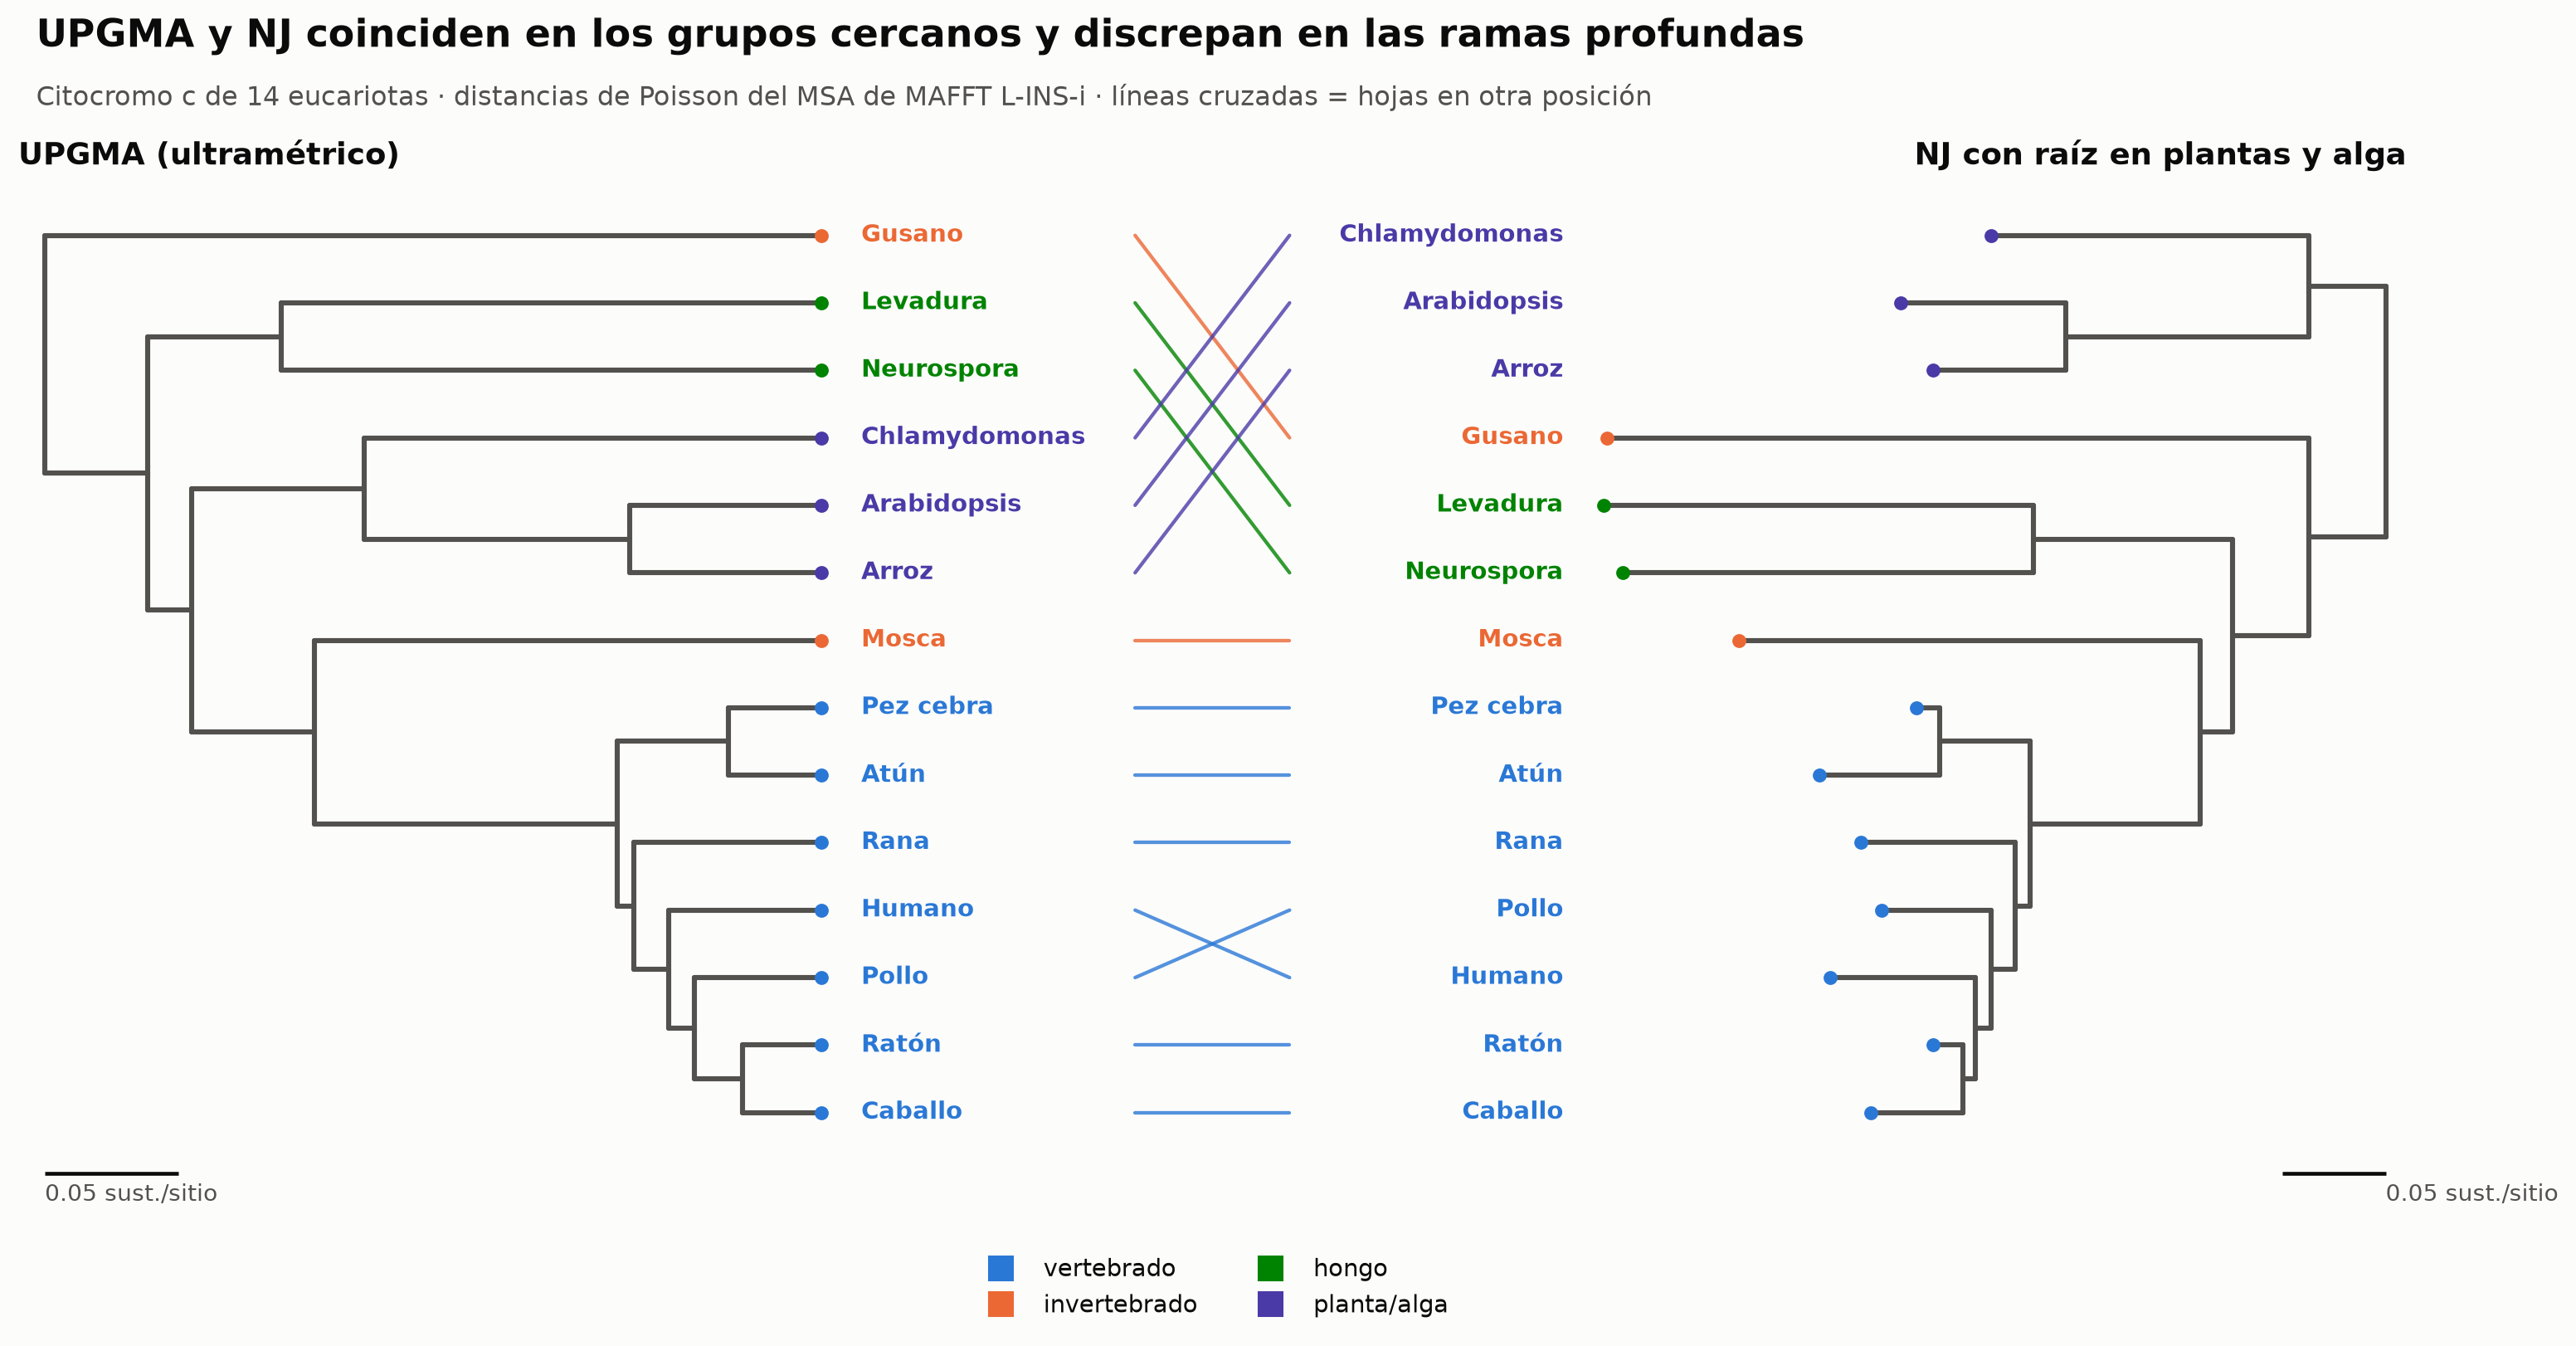

In [32]:
fig, (ax_l, ax_m, ax_r) = plt.subplots(1, 3, figsize=(14, 6.6), width_ratios=[1, 0.85, 1])
pos_l = draw_tree(ax_l, tree_u_cyt, label_colors=NAME_COLOR, show_labels=False, scale=0.05, xlabel="sust./sitio")
pos_r = draw_tree(ax_r, tree_nj_rooted, label_colors=NAME_COLOR, show_labels=False, scale=0.05, xlabel="sust./sitio")
for ax in (ax_l, ax_r):
    ax.set_xlim(-0.01, max(x for x, _ in (pos_l if ax is ax_l else pos_r).values()) * 1.03)
ax_r.invert_xaxis()
y_l = {nd.name: pos_l[id(nd)][1] for nd in tree_u_cyt.nodes() if nd.is_leaf()}
y_r = {nd.name: pos_r[id(nd)][1] for nd in tree_nj_rooted.nodes() if nd.is_leaf()}
for name in cyt_names:
    col = NAME_COLOR[name]
    ax_m.text(0.0, y_l[name], name, ha="left", va="center", fontsize=9.5, color=col, fontweight="bold")
    ax_m.text(1.0, y_r[name], name, ha="right", va="center", fontsize=9.5, color=col, fontweight="bold")
    ax_m.plot([0.39, 0.61], [y_l[name], y_r[name]], color=col, lw=1.4, alpha=0.8)
n = len(cyt_names)
ax_m.set_xlim(0, 1); ax_m.set_ylim(n + 0.55, -0.6); ax_m.axis("off")
ax_l.set_title("UPGMA (ultramétrico)", loc="left", fontsize=12)
ax_r.set_title("NJ con raíz en plantas y alga", loc="right", fontsize=12)
for g, c in GROUP_COLOR.items():
    ax_m.plot([], [], "s", color=c, label=g, ms=9)
ax_m.legend(loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9.5)
ec.fig_title(fig, "UPGMA y NJ coinciden en los grupos cercanos y discrepan en las ramas profundas",
             "Citocromo c de 14 eucariotas · distancias de Poisson del MSA de MAFFT L-INS-i · líneas cruzadas = hojas en otra posición")
plt.show()

> 🔎 **Qué observamos.**
>
> * **Ambos** métodos recuperan los grupos "fáciles": las dos plantas con Chlamydomonas, los dos hongos, los dos peces,
>   y a los vertebrados como un grupo.
> * **UPGMA** pone al **gusano** (*C. elegans*) como el linaje más antiguo de todos, fuera incluso de las plantas: su
>   citocromo *c* evolucionó rápido, y UPGMA confunde "cambió mucho" con "se separó hace mucho" (sección 6).
> * **NJ** agrupa a los vertebrados con la mosca, pero también se equivoca con el gusano: lo saca del grupo de
>   animales y hongos y lo deja junto a la raíz, al lado de las plantas. Es un caso de **atracción de ramas largas**: dos linajes con muchos cambios acumulan coincidencias por
>   azar y parecen parientes. Ninguna corrección de distancias lo resuelve del todo; los métodos de máxima verosimilitud
>   con modelos más realistas (Lección 5.3) lo mitigan.
> * Dentro de los mamíferos, el citocromo *c* humano tiene algunas sustituciones propias y queda fuera del par
>   ratón–caballo: con proteínas de ~100 residuos, **una o dos** sustituciones cambian la topología. Por eso un árbol
>   de un solo gen corto debe leerse con cautela y, en la práctica, acompañarse de medidas de confianza como el
>   **bootstrap** (Lección 5.3).

### Árbol interactivo

Pase el cursor por los **nodos internos** (puntos grises) para ver el clado que definen: cuántas especies contiene,
cuáles son, la longitud de la rama que lo une con su ancestro y su distancia a la raíz. Sobre las hojas verá el grupo
taxonómico.

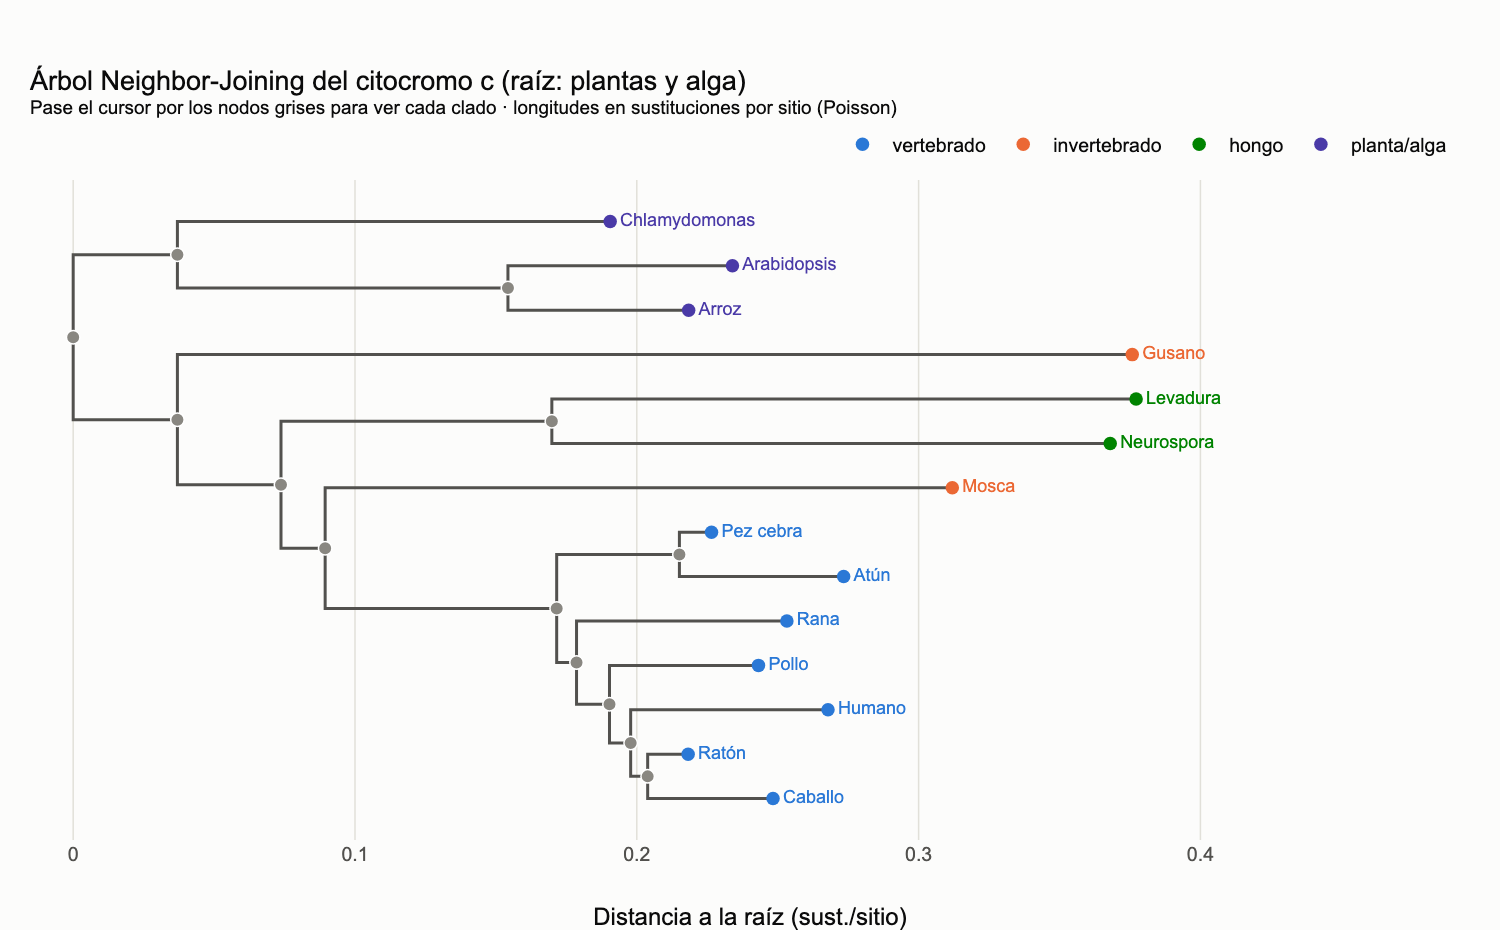

In [33]:
def plotly_tree(fig, tree, row=None, col=None, showlegend=True):
    """Añade un filograma rectangular interactivo a una figura de Plotly."""
    pos = rooted_layout(tree)
    kw = dict(row=row, col=col) if row else {}
    xs, ys = [], []
    for nd in tree.nodes():
        x, y = pos[id(nd)]
        for c in nd.children:
            cx, cy = pos[id(c)]
            xs += [x, x, cx, None]; ys += [y, cy, cy, None]
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color=ec.INK_2, width=2),
                             hoverinfo="skip", showlegend=False), **kw)
    internal = [nd for nd in tree.nodes() if not nd.is_leaf()]
    fig.add_trace(go.Scatter(
        x=[pos[id(nd)][0] for nd in internal], y=[pos[id(nd)][1] for nd in internal], mode="markers",
        marker=dict(color=ec.MUTED, size=9, line=dict(color="white", width=1)), showlegend=False,
        customdata=[[len(nd.leaves()), "<br>   ".join(", ".join(nd.leaves()[i:i + 4]) for i in range(0, len(nd.leaves()), 4)),
                     nd.length, pos[id(nd)][0]] for nd in internal],
        hovertemplate=("<b>Clado de %{customdata[0]} especies</b><br>   %{customdata[1]}"
                       "<br>Rama hacia su ancestro: %{customdata[2]:.4f} sust./sitio"
                       "<br>Distancia a la raíz: %{customdata[3]:.4f}<extra></extra>")), **kw)
    for g, gc in GROUP_COLOR.items():
        leaves = [nd for nd in tree.nodes() if nd.is_leaf() and GROUP[nd.name] == g]
        fig.add_trace(go.Scatter(
            x=[pos[id(nd)][0] for nd in leaves], y=[pos[id(nd)][1] for nd in leaves], mode="markers+text",
            text=[nd.name for nd in leaves], textposition="middle right", textfont=dict(color=gc, size=12),
            marker=dict(color=gc, size=9), name=g, legendgroup=g, showlegend=showlegend,
            customdata=[[g, nd.length, pos[id(nd)][0]] for nd in leaves],
            hovertemplate=("<b>%{text}</b> · %{customdata[0]}<br>Rama terminal: %{customdata[1]:.4f} sust./sitio"
                           "<br>Distancia a la raíz: %{customdata[2]:.4f}<extra></extra>")), **kw)
    return pos

fig = go.Figure()
pos_int = plotly_tree(fig, tree_nj_rooted)
xmax = max(x for x, _ in pos_int.values())
fig.update_layout(
    title=dict(text="Árbol Neighbor-Joining del citocromo c (raíz: plantas y alga)<br>"
                    "<sup>Pase el cursor por los nodos grises para ver cada clado · longitudes en sustituciones por sitio (Poisson)</sup>"),
    xaxis=dict(title="Distancia a la raíz (sust./sitio)", range=[-0.01, xmax * 1.3], showgrid=True, gridcolor=ec.GRID),
    yaxis=dict(visible=False, autorange="reversed"), height=620, margin=dict(t=120, l=30, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"))
fig.show()

### UPGMA frente a NJ, lado a lado (interactivo)

Compare los dos árboles con el cursor: en UPGMA todas las hojas terminan a la misma distancia de la raíz (el reloj
impuesto); en NJ cada linaje tiene su propia longitud. Busque las especies con ramas terminales largas en NJ: son las
que UPGMA coloca de forma más dudosa.

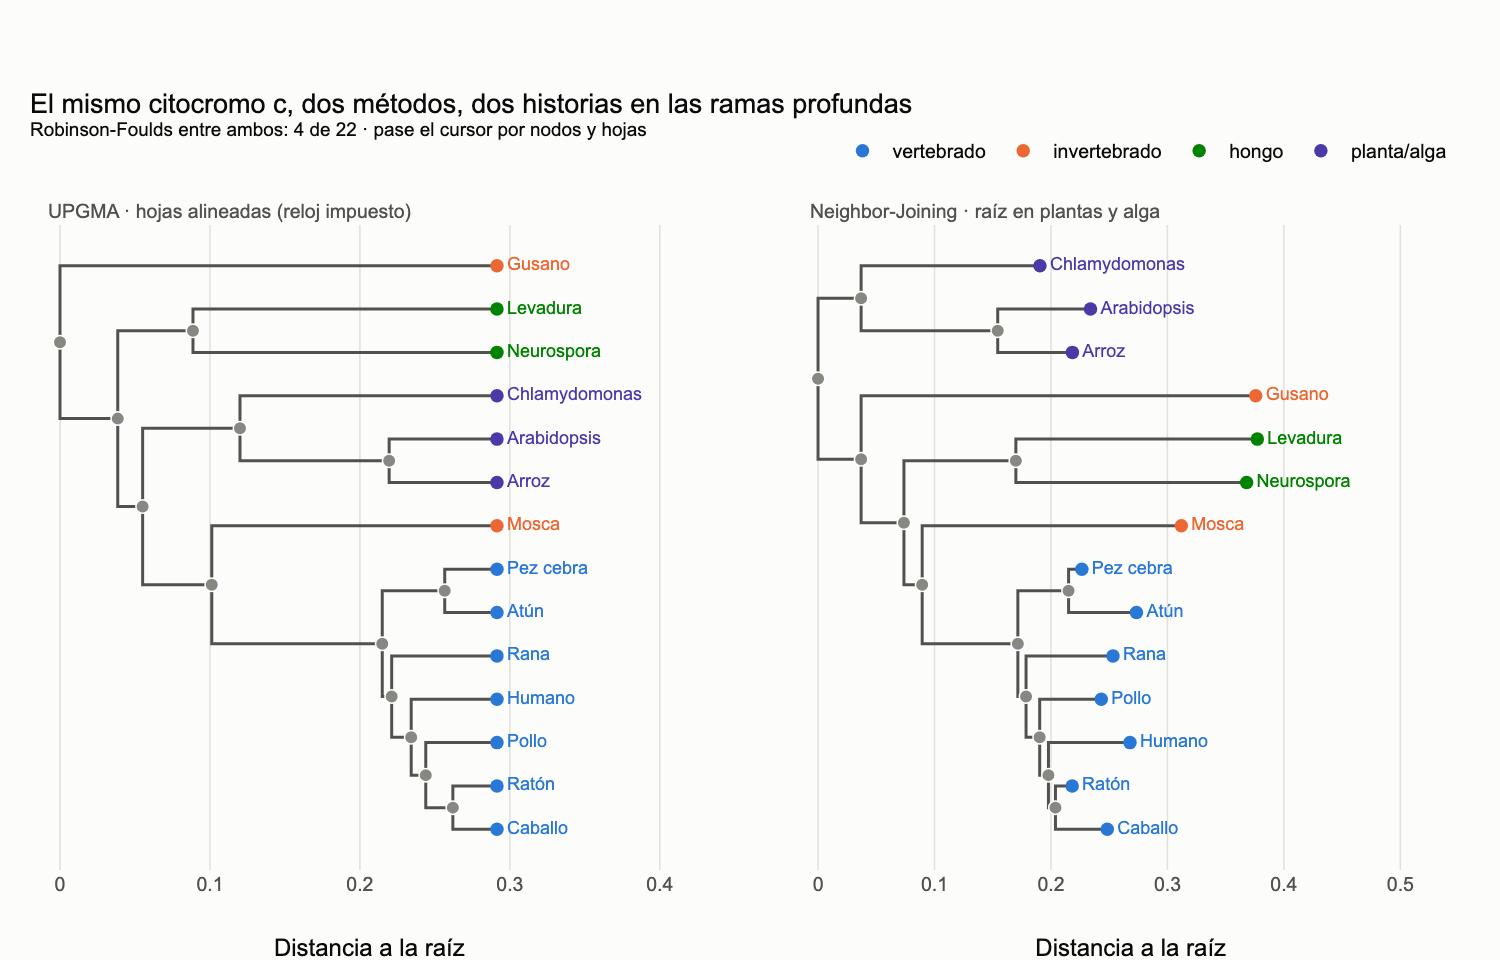

In [34]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.08,
                    subplot_titles=("UPGMA · hojas alineadas (reloj impuesto)", "Neighbor-Joining · raíz en plantas y alga"))
p1 = plotly_tree(fig, tree_u_cyt, row=1, col=1, showlegend=True)
p2 = plotly_tree(fig, tree_nj_rooted, row=1, col=2, showlegend=False)
for c, p in [(1, p1), (2, p2)]:
    xm = max(x for x, _ in p.values())
    fig.update_xaxes(range=[-0.01, xm * 1.45], title="Distancia a la raíz", showgrid=True, gridcolor=ec.GRID, row=1, col=c)
    fig.update_yaxes(visible=False, autorange="reversed", row=1, col=c)
fig.update_annotations(font=dict(size=13, color=ec.INK_2), xanchor="left", x=None)
fig.layout.annotations[0].x, fig.layout.annotations[1].x = 0.0, 0.54
fig.update_layout(
    title=dict(text="El mismo citocromo c, dos métodos, dos historias en las ramas profundas<br>"
                    f"<sup>Robinson-Foulds entre ambos: {robinson_foulds(tree_u_cyt, tree_nj_cyt)} de {n_max} · pase el cursor por nodos y hojas</sup>"),
    height=640, margin=dict(t=150, l=30, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.08, x=1, xanchor="right"))
fig.show()

✅ **Compruebe su comprensión.** En el árbol NJ, ¿cuál es la especie con la rama terminal más larga? ¿Tiene sentido
que sea la que más problemas causa a ambos métodos?

## ✍️ Ejercicios

**Ejercicio 1 — UPGMA a mano.** Construya a mano el árbol UPGMA de esta matriz y escríbalo en Newick con longitudes.
Luego compruébelo con `upgma`. ¿La matriz es ultramétrica? ¿Da WPGMA el mismo árbol? ¿Por qué?

| | W | X | Y | Z |
|---|---|---|---|---|
| **W** | 0 | 2 | 6 | 10 |
| **X** | | 0 | 6 | 10 |
| **Y** | | | 0 | 10 |

**Ejercicio 2 — Genes, no especies: las globinas.** El archivo `globins.fasta` del curso contiene la hemoglobina β
humana y de ratón, la hemoglobina α humana y la mioglobina humana y de cachalote. Calcule distancias de Poisson a partir
de alineamientos globales por pares (BLOSUM62), construya el árbol NJ, enraícelo por el punto medio y dibújelo.
¿Se agrupan las secuencias por **especie** o por **gen**? ¿Qué evento evolutivo explica lo que ve?

**Ejercicio 3 — ¿Importa la corrección de la distancia?** Reconstruya el árbol NJ del citocromo *c* con la
distancia $p$ sin corregir (la matriz `P_cyt`) y compárelo con el obtenido con distancias de Poisson: RF entre ambos y
RF de cada uno con la taxonomía. ¿Cambia la topología? ¿Y las longitudes de las ramas más largas? Explique por qué.

**Ejercicio 4 — Punto medio en datos reales.** Enraíce el árbol NJ del citocromo *c* por el **punto medio** y compare
sus clados con los del árbol enraizado con plantas y alga (use `clusters`). ¿Entre qué dos especies está el camino más
largo del árbol? ¿Dónde queda la raíz y por qué?

In [35]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
WXYZ = list("WXYZ")
D_ex1 = matrix_from_pairs(WXYZ, {"WX": 2, "WY": 6, "WZ": 10, "XY": 6, "XZ": 10, "YZ": 10})
t_u, st_u = upgma(D_ex1, WXYZ)
t_w, _ = upgma(D_ex1, WXYZ, weighted=True)
for k, s in enumerate(st_u, 1):
    print(f"Fusión {k}: {'+'.join(s['members'][s['a']])} con {'+'.join(s['members'][s['b']])} a d = {s['d']:g}")
print("UPGMA:", to_newick(t_u), "· WPGMA:", to_newick(t_w))
print("¿Ultramétrica?", np.all(three_point_deviation(D_ex1) < 1e-12))
print("Si la matriz es ultramétrica, las distancias de un grupo a los demás son iguales para todos sus miembros:")
print("promediar con o sin pesos da lo mismo, y UPGMA = WPGMA reproducen exactamente la matriz.")

Fusión 1: W con X a d = 2
Fusión 2: Y con W+X a d = 6
Fusión 3: Z con Y+W+X a d = 10
UPGMA: (Z:5,(Y:3,(W:1,X:1):2):2); · WPGMA: (Z:5,(Y:3,(W:1,X:1):2):2);
¿Ultramétrica? True
Si la matriz es ultramétrica, las distancias de un grupo a los demás son iguales para todos sus miembros:
promediar con o sin pesos da lo mismo, y UPGMA = WPGMA reproducen exactamente la matriz.


            HBB_HUMAN  HBA_HUMAN  MYG_HUMAN  HBB1_MOUSE  MYG_PHYMC
HBB_HUMAN        0.00       0.77       1.35        0.22       1.35
HBA_HUMAN        0.77       0.00       1.24        0.78       1.25
MYG_HUMAN        1.35       1.24       0.00        1.17       0.17
HBB1_MOUSE       0.22       0.78       1.17        0.00       1.22
MYG_PHYMC        1.35       1.25       0.17        1.22       0.00


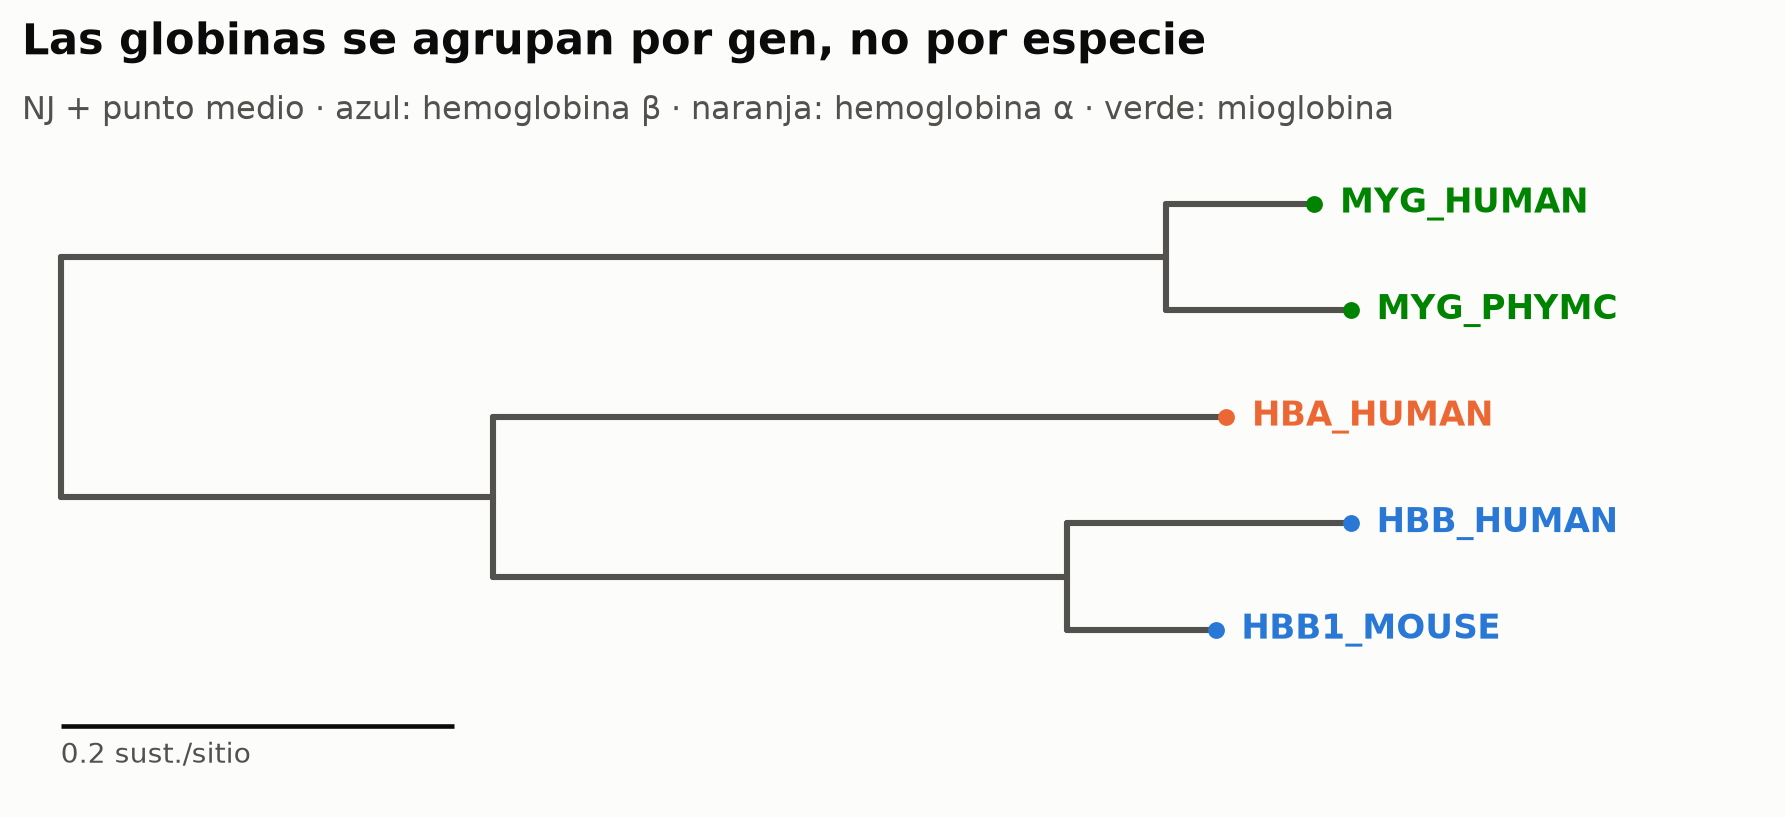

La β humana está más cerca de la β de ratón que de la α humana: α, β y mioglobina son PARÁLOGOS,
copias surgidas por duplicación génica antes de la separación de humanos y ratones (y de los cetáceos).
Un árbol de genes no es automáticamente un árbol de especies.


In [36]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
from Bio.Align import PairwiseAligner, substitution_matrices
aligner = PairwiseAligner(mode="global", substitution_matrix=substitution_matrices.load("BLOSUM62"),
                          open_gap_score=-10, extend_gap_score=-0.5)
glob = list(SeqIO.parse(course_file("globins.fasta"), "fasta"))
glob_names = [r.id.split("|")[2] for r in glob]
G = np.zeros((len(glob), len(glob)))
for i, j in itertools.combinations(range(len(glob)), 2):
    aln = aligner.align(glob[i].seq, glob[j].seq)[0]
    G[i, j] = G[j, i] = -np.log(1 - p_distance(aln[0], aln[1]))
t_glob = midpoint_root(neighbor_joining(G, glob_names)[0])
print(pd.DataFrame(G, index=glob_names, columns=glob_names).round(2))
fig, ax = plt.subplots(figsize=(8, 3.6))
gene_col = {n: (ec.BLUE if n.startswith("HBB") else ec.ORANGE if n.startswith("HBA") else ec.GREEN) for n in glob_names}
draw_tree(ax, ladderize(t_glob), label_colors=gene_col, fs=11, scale=0.2, xlabel="sust./sitio")
ec.title(ax, "Las globinas se agrupan por gen, no por especie",
         "NJ + punto medio · azul: hemoglobina β · naranja: hemoglobina α · verde: mioglobina")
plt.show()
print("La β humana está más cerca de la β de ratón que de la α humana: α, β y mioglobina son PARÁLOGOS,")
print("copias surgidas por duplicación génica antes de la separación de humanos y ratones (y de los cetáceos).")
print("Un árbol de genes no es automáticamente un árbol de especies.")

In [37]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
tree_nj_p, _ = neighbor_joining(P_cyt, cyt_names)
print("RF (p vs Poisson):", robinson_foulds(tree_nj_p, tree_nj_cyt))
print("RF con la taxonomía · p:", robinson_foulds(tree_nj_p, reference), "· Poisson:", robinson_foulds(tree_nj_cyt, reference))
Lp = {nd.name: nd.length for nd in tree_nj_p.nodes() if nd.is_leaf()}
Lq = {nd.name: nd.length for nd in tree_nj_cyt.nodes() if nd.is_leaf()}
print(pd.DataFrame({"rama terminal (p)": Lp, "rama terminal (Poisson)": Lq}).round(3)
      .sort_values("rama terminal (Poisson)", ascending=False).head(5))
print("Con divergencias moderadas (p < 0.4) la corrección no cambia el orden de las distancias lo suficiente como")
print("para alterar la topología, pero sí ALARGA las ramas largas: −ln(1−p) crece más rápido que p cuando p es grande.")

RF (p vs Poisson): 0
RF con la taxonomía · p: 6 · Poisson: 6
               rama terminal (p)  rama terminal (Poisson)
Gusano                     0.249                    0.339
Mosca                      0.177                    0.223
Levadura                   0.170                    0.207
Neurospora                 0.164                    0.198
Chlamydomonas              0.134                    0.154
Con divergencias moderadas (p < 0.4) la corrección no cambia el orden de las distancias lo suficiente como
para alterar la topología, pero sí ALARGA las ramas largas: −ln(1−p) crece más rápido que p cuando p es grande.


In [38]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
tree_mid_cyt = midpoint_root(tree_nj_cyt)
adj_c, lab_c = to_graph(tree_nj_cyt)
leaf_ids = [k for k in adj_c if lab_c[k]]
dmax, a, b = max(((graph_distances(adj_c, x)[0][y], x, y) for x, y in itertools.combinations(leaf_ids, 2)),
                 key=lambda t: t[0])
print(f"Camino más largo: {lab_c[a]} – {lab_c[b]} ({dmax:.3f} sust./sitio)")
c_out, c_mid = clusters(tree_nj_rooted), clusters(tree_mid_cyt)
print("Clados sólo con grupo externo:", [sorted(c) for c in c_out - c_mid])
print("Clados sólo con punto medio  :", [sorted(c) for c in c_mid - c_out])
print("El camino más largo une las dos ramas terminales más largas (levadura y gusano). Su punto medio cae cerca de")
print("la base del gusano: el árbol queda dividido en {plantas + gusano} y {vertebrados, mosca, hongos}. Con el")
print("grupo externo, en cambio, aparece el clado de animales + hongos (con el gusano): las ramas largas desplazan")
print("el punto medio, igual que en la simulación de la sección 9.")

Camino más largo: Levadura – Gusano (0.679 sust./sitio)
Clados sólo con grupo externo: [['Atún', 'Caballo', 'Gusano', 'Humano', 'Levadura', 'Mosca', 'Neurospora', 'Pez cebra', 'Pollo', 'Rana', 'Ratón']]
Clados sólo con punto medio  : [['Arabidopsis', 'Arroz', 'Chlamydomonas', 'Gusano']]
El camino más largo une las dos ramas terminales más largas (levadura y gusano). Su punto medio cae cerca de
la base del gusano: el árbol queda dividido en {plantas + gusano} y {vertebrados, mosca, hongos}. Con el
grupo externo, en cambio, aparece el clado de animales + hongos (con el gusano): las ramas largas desplazan
el punto medio, igual que en la simulación de la sección 9.


## 📌 Resumen

* Un árbol filogenético tiene **hojas** (secuencias observadas), **nodos internos** (ancestros hipotéticos), **ramas**
  con longitudes (cambio o tiempo) y, opcionalmente, una **raíz**. La **topología** es el patrón de ramificación: rotar
  nodos o cambiar longitudes no la altera. El formato **Newick** la escribe con paréntesis anidados.
* Hay $(2n-5)!!$ árboles binarios sin raíz y $(2n-3)!!$ con raíz: con 50–55 especies, más que átomos en el universo.
  Por eso se construyen árboles con recetas rápidas o se buscan heurísticamente.
* Una matriz es **aditiva** si cumple la condición de los **cuatro puntos** (existe un árbol que la reproduce) y
  **ultramétrica** si cumple la de los **tres puntos** (además hay reloj).
* **UPGMA** une el par más cercano y promedia (ponderando por tamaño); produce un árbol con raíz **ultramétrico** y
  falla cuando las tasas son desiguales. **WPGMA** promedia sin ponderar (y es lo que hace `upgma` de Biopython 1.88).
* **Neighbor-Joining** une el par con menor $Q(i,j) = (n-2)d_{ij} - r_i - r_j$, estima ramas desiguales y recupera
  exactamente cualquier árbol aditivo. Su árbol **no tiene raíz**.
* La raíz se pone con un **grupo externo** (preferible) o por **punto medio** (supone tasas parecidas).
* La distancia de **Robinson-Foulds** cuenta las biparticiones que no comparten dos árboles.
* En el citocromo *c*, ambos métodos recuperan los grupos cercanos; UPGMA se equivoca más en las ramas profundas, y
  ambos sufren con la rama larga del gusano (atracción de ramas largas).

## 📚 Para profundizar

* Sokal, R. R. & Michener, C. D. (1958). A statistical method for evaluating systematic relationships.
  *University of Kansas Science Bulletin* 38: 1409–1438.
* Fitch, W. M. & Margoliash, E. (1967). Construction of phylogenetic trees. *Science* 155(3760): 279–284.
* Buneman, P. (1971). The recovery of trees from measures of dissimilarity. En *Mathematics in the Archaeological
  and Historical Sciences*, pp. 387–395. Edinburgh University Press.
* Robinson, D. F. & Foulds, L. R. (1981). Comparison of phylogenetic trees. *Mathematical Biosciences* 53(1–2):
  131–147.
* Saitou, N. & Nei, M. (1987). The neighbor-joining method: a new method for reconstructing phylogenetic trees.
  *Molecular Biology and Evolution* 4(4): 406–425.
* Studier, J. A. & Keppler, K. J. (1988). A note on the neighbor-joining algorithm of Saitou and Nei. *Molecular
  Biology and Evolution* 5(6): 729–731.
* Felsenstein, J. (2004). *Inferring Phylogenies*. Sinauer Associates.
* Talevich, E., Invergo, B. M., Cock, P. J. A. & Chapman, B. A. (2012). Bio.Phylo: a unified toolkit for processing,
  analyzing and visualizing phylogenetic trees in Biopython. *BMC Bioinformatics* 13: 209.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)